# Dhaka City Air Quality Analysis (2017–2025) and Projections (2026–2030)

**Journal article companion notebook**  
A fully reproducible end-to-end analysis of monthly air quality index (AQI) and
multi-pollutant concentrations observed at the Dhaka continuous ambient air-quality
monitoring station (2017–2025), combined with multi-model ensemble forecasting to 2030.

| | |
|---|---|
| **Study area** | Dhaka City District, Bangladesh |
| **Period** | January 2017 – September 2025 (108 monthly observations) |
| **Pollutants** | PM₂.₅, PM₁₀, NO₂, SO₂, AQI |
| **Forecast horizon** | October 2025 – December 2030 |
| **Models** | OLS, ETS (Holt-Winters), SARIMAX, Prophet, Ensemble |

---

### Notebook structure
| § | Section |
|---|---|
| 0 | Study Area Map |
| 1 | Setup & Data Loading |
| 2 | Descriptive Statistics & Data Quality |
| 3 | Long-Term Temporal Trends |
| 4 | Seasonal & Monthly Climatology |
| 5 | Time-Series Diagnostics |
| 6 | Pollutant Inter-relationships |
| 7 | Statistical Testing — Seasonal Differences |
| 8 | COVID-19 Impact Assessment |
| 9 | Meteorological Drivers |
| 10 | Socioeconomic Context & EKC Analysis |
| 11 | WHO & EPA Guideline Exceedance |
| 12 | Health Burden Estimation |
| 13 | Regional Comparison |
| 14 | Predictive Modelling — Held-out Evaluation |
| 15 | Multi-Model Forecasts to 2030 |
| 16 | Policy Scenario Projections |
| 17 | Conclusions & Limitations |


---
## § 0 — Study Area Map

The map below shows the **41 urban thanas** (ADM3) of **Dhaka City**, Bangladesh,
representing the Dhaka City Corporation (DNCC + DSCC) area. Five rural/peri-urban
thanas that form part of Dhaka District (ADM2) but lie outside the city corporation
boundary — Dhamrai, Savar, Keraniganj, Nawabganj, and Dohar — are excluded, as the
monitoring station data used in this study covers Dhaka City only.

Shapefiles: Bangladesh Bureau of Statistics (BBS) — ADM3, November 2020 release.


Saved → figures/fig01_study_area.png


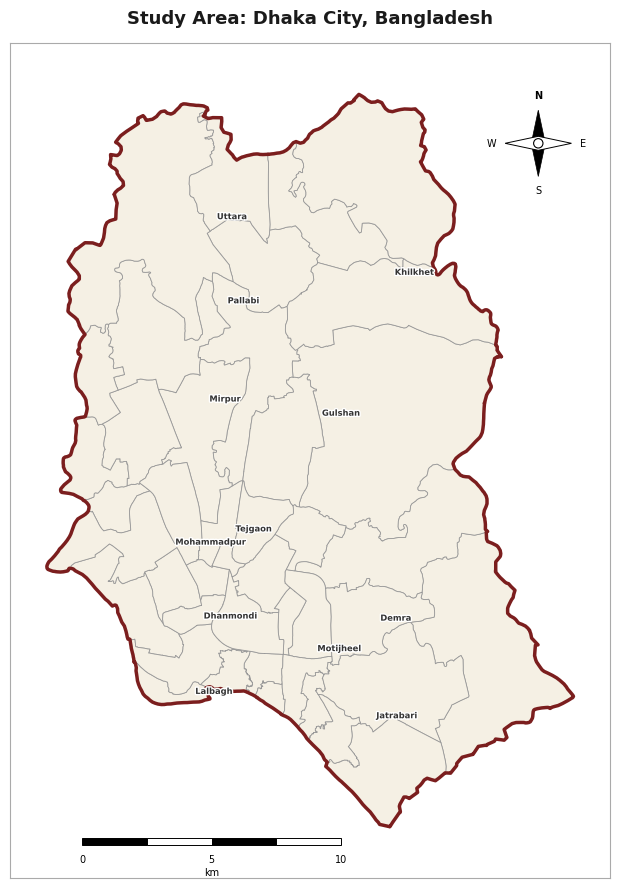

In [1]:
from src.map_utils import plot_study_area
from src.viz import save_fig

fig = plot_study_area()
save_fig(fig, 'fig01_study_area')
fig.show()


---
## § 1 — Setup & Data Loading

All analysis constants (colour palettes, WHO/EPA guidelines, season order) live in
`src/config.py`. Statistical functions are in `src/analysis.py`, predictive models
in `src/forecasting.py`, and visualisation helpers in `src/viz.py`.

### Dataset columns
| Group | Columns |
|---|---|
| Temporal | `month_start`, `year`, `month`, `season` |
| Pollutants | `pm25_*`, `pm10_*`, `no2_*`, `so2_*`, `aqi_*` (mean/median/min/max) |
| Observations | `hourly_observations`, `expected_hours`, `coverage_pct`, `is_partial_month` |
| Demographic | `population_total`, `urban_population`, `urban_share_pct`, `hdi`, `poverty_rate_pct` |
| Meteorological | `norm_rain` (2017-2021 only) |


In [2]:
import os, pathlib, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, kruskal, shapiro, mannwhitneyu, norm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scikit_posthocs import posthoc_dunn

# ── src modules ───────────────────────────────────────────────────────────────
import sys
sys.path.insert(0, str(pathlib.Path().resolve()))

from src.config import (
    PAL, SEASON_PAL, SEASON_ORDER, MONTH_LABELS,
    POL_COLS, POL_NAMES, POL_SHORT,
    WHO, EPA, AQI_CATS, apply_style,
)
from src.data_loader import (
    load_data, compute_annual, compute_monthly_climatology,
    covid_periods, build_future_dates,
)
from src import viz
from src.viz import save_fig

apply_style()

# ── Load data ─────────────────────────────────────────────────────────────────
df     = load_data()
annual = compute_annual(df)
clim   = compute_monthly_climatology(df)

print(f'Loaded {len(df)} monthly observations')
print(f'Date range: {df.month_start.min().date()} → {df.month_start.max().date()}')
print(f'Columns: {list(df.columns)}')
df.head(3)


from IPython.display import HTML


def _pub_table(latex_str):
    """Convert notebook LaTeX tabular -> publication-quality HTML.

    Converts all inline $math$ to HTML using subscript/superscript/symbol
    mappings so tables render correctly in VS Code (no KaTeX required).
    """
    import re

    # ── math converter ───────────────────────────────────────────────────────
    def _math(expr):
        """Convert LaTeX math expression (without $ delimiters) to HTML."""
        s = str(expr)

        # 1. Symbol replacements (longest first to avoid partial matches)
        SYMS = [
            (r'\downarrow', '↓'), (r'\uparrow', '↑'),
            (r'\rightarrow', '→'), (r'\leftarrow', '←'),
            (r'\Rightarrow', '⇒'), (r'\Leftarrow', '⇐'),
            (r'\dagger', '†'), (r'\ddagger', '‡'),
            (r'\times', '×'), (r'\cdot', '·'), (r'\pm', '±'),
            (r'\mu', 'µ'), (r'\alpha', 'α'), (r'\beta', 'β'),
            (r'\gamma', 'γ'), (r'\delta', 'δ'), (r'\Delta', 'Δ'),
            (r'\sigma', 'σ'), (r'\pi', 'π'), (r'\theta', 'θ'),
            (r'\lambda', 'λ'), (r'\epsilon', 'ε'), (r'\eta', 'η'),
            (r'\geq', '≥'), (r'\leq', '≤'), (r'\neq', '≠'),
            (r'\approx', '≈'), (r'\sim', '~'), (r'\propto', '∝'),
            (r'\infty', '∞'), (r'\partial', '∂'),
            (r'\,', '\u202f'), (r'\ ', ' '), (r'\;', ' '),
            (r'\quad', ' '), (r'\!', ''), (r'\:', '\u202f'),
            (r'\%', '%'), (r'\&', '&amp;'), (r'\_', '_'),
        ]
        for cmd, sym in SYMS:
            s = s.replace(cmd, sym)

        # 2. Subscripts / superscripts that contain \cmd{} — handle BEFORE
        #    general \cmd{} processing so _\mathrm{pre} → <sub>pre</sub>
        s = re.sub(r'_\\[a-zA-Z]+\{([^{}]*)\}',
                   lambda m: f'<sub>{_math(m.group(1))}</sub>', s)
        s = re.sub(r'\^\\[a-zA-Z]+\{([^{}]*)\}',
                   lambda m: f'<sup>{_math(m.group(1))}</sup>', s)

        # 3. Process \cmd{content} wrappers (innermost first via while loop)
        CMD = [
            (r'\overline', '<span style="text-decoration:overline">', '</span>'),
            (r'\widehat',  '<span style="text-decoration:overline">', '</span>'),
            (r'\widetilde','<span style="text-decoration:wavy underline">', '</span>'),
            (r'\bar',      '<span style="text-decoration:overline">', '</span>'),
            (r'\hat',      '<span style="text-decoration:overline">', '</span>'),
            (r'\mathbf',   '<b>', '</b>'),
            (r'\boldsymbol','<b>', '</b>'),
            (r'\mathit',   '<i>', '</i>'),
            (r'\mathrm',   '', ''),
            (r'\text',     '', ''),
            (r'\textbf',   '<b>', '</b>'),
            (r'\textit',   '<i>', '</i>'),
            (r'\mathbb',   '', ''),
            (r'\mathnormal','', ''),
        ]
        for cmd, op, cl in CMD:
            pat = cmd + '{'
            while pat in s:
                idx = s.find(pat)
                start = idx + len(pat)
                depth = 1; j = start
                while j < len(s) and depth > 0:
                    if s[j] == '{':   depth += 1
                    elif s[j] == '}': depth -= 1
                    j += 1
                inner = s[start: j - 1]
                inner_html = _math(inner) if re.search(r'[\\_{^]', inner) else inner
                s = s[:idx] + op + inner_html + cl + s[j:]

        # 4. Subscripts — two passes to handle one level of nesting
        for _ in range(2):
            s = re.sub(r'_\{([^{}]*)\}', r'<sub>\1</sub>', s)
            s = re.sub(r'_([a-zA-Z0-9,.])', r'<sub>\1</sub>', s)

        # 5. Superscripts — two passes
        for _ in range(2):
            s = re.sub(r'\^\{([^{}]*)\}',
                       lambda m: f'<sup>{m.group(1)}</sup>', s)
            s = re.sub(r'\^([-+]?[a-zA-Z0-9†‡*])',
                       lambda m: f'<sup>{m.group(1)}</sup>', s)

        # 6. Clean up remaining LaTeX
        s = re.sub(r'\\[a-zA-Z]+\*?', '', s)  # unknown commands
        s = re.sub(r'[{}]', '', s)             # stray braces
        return s.strip()

    # ── text formatter (non-math content) ───────────────────────────────────
    def _fmt(s):
        """Convert LaTeX text commands and inline $math$ to HTML."""
        s = str(s)

        # Split on $...$ so math and text are processed separately
        parts = re.split(r'(\$[^$]+\$)', s)
        out = []
        for part in parts:
            if part.startswith('$') and part.endswith('$') and len(part) > 2:
                out.append(_math(part[1:-1]))
            else:
                t = part
                # \textbf / \textit / \texttt / \text
                t = re.sub(r'\\textbf\{((?:[^{}]|\{[^{}]*\})*)\}',
                           r'<b>\1</b>', t)
                t = re.sub(r'\\textit\{((?:[^{}]|\{[^{}]*\})*)\}',
                           r'<i>\1</i>', t)
                t = re.sub(r'\\texttt\{((?:[^{}]|\{[^{}]*\})*)\}',
                           r'<code>\1</code>', t)
                t = re.sub(r'\\text\{([^}]*)\}', r'\1', t)
                # spacing & dashes (only outside math)
                t = t.replace(r'\ ', '\u00a0').replace(r'\,', '\u202f')
                t = t.replace('---', '\u2014').replace('--', '\u2013')
                # escaped symbols
                t = t.replace(r'\%', '%').replace(r'\_', '_')
                t = t.replace(r'\&', '&amp;')
                # trailing \\[Xunit] line-break
                t = re.sub(r'\\\\(?:\[[^\]]*\])?\s*$', '', t)
                out.append(t)
        return ''.join(out).strip()

    # ── split latex into caption / table / notes ─────────────────────────────
    m_beg = re.search(r'\\begin\{tabular\}\{([^}]+)\}', latex_str)
    m_end = re.search(r'\\end\{tabular\}',              latex_str)

    if not m_beg:
        return (
            '<div style="font-family:Georgia,serif;font-size:13px;'
            'margin:6px 0;color:#222">' + _fmt(latex_str) + '</div>'
        )

    cap_raw  = latex_str[: m_beg.start()].strip()
    col_spec = m_beg.group(1)
    body     = latex_str[m_beg.end() : (m_end.start() if m_end else len(latex_str))]
    note_raw = latex_str[m_end.end():].strip() if m_end else ''

    cap_raw = re.sub(r'\\\\?\[[\d.]+[a-z]+\]\s*$', '', cap_raw).strip()
    cap_raw = re.sub(r'\\\\\s*$',                  '', cap_raw).strip()
    cap_html = _fmt(cap_raw)

    _amap  = {'l': 'left', 'r': 'right', 'c': 'center', 'p': 'left'}
    col_al = [_amap.get(ch, 'right') for ch in col_spec if ch in 'lrcp']

    # ── parse body rows ───────────────────────────────────────────────────────
    raw_chunks = re.split(r'\\\\', body)
    parsed = []
    for chunk in raw_chunks:
        chunk = chunk.strip()
        if not chunk:
            continue
        n_hl    = len(re.findall(r'\\hline', chunk))
        content = re.sub(r'\\hline', '', chunk).strip()
        if content:
            cells = [_fmt(c) for c in re.split(r'(?<!\\)&', content)]
            parsed.append(('row', n_hl, cells))
        else:
            parsed.append(('hline', n_hl, None))

    section = 'pre'
    header_rows, data_rows = [], []
    for kind, n_hl, cells in parsed:
        if n_hl > 0:
            if   section == 'pre':    section = 'hdr'
            elif section == 'hdr':    section = 'data'
            elif section == 'data':   section = 'footer'
        if kind == 'row':
            if   section in ('pre', 'hdr'): header_rows.append(cells)
            elif section == 'data':         data_rows.append(cells)

    # ── build HTML ────────────────────────────────────────────────────────────
    PAD = 'padding:3px 12px;vertical-align:middle'

    def _tr_hdr(cells):
        return '<tr>' + ''.join(
            f'<th style="{PAD};text-align:{col_al[j] if j<len(col_al) else "right"}">'
            f'{c}</th>' for j, c in enumerate(cells)
        ) + '</tr>'

    def _tr_dat(cells):
        return '<tr>' + ''.join(
            f'<td style="{PAD};text-align:{col_al[j] if j<len(col_al) else "right"}">'
            f'{c}</td>' for j, c in enumerate(cells)
        ) + '</tr>'

    thead    = ''.join(_tr_hdr(r) for r in header_rows)
    tbody    = ''.join(_tr_dat(r) for r in data_rows)
    note_html = (
        f'<div style="font-family:Georgia,serif;font-size:11.5px;'
        f'color:#555;margin:3px 0">{_fmt(note_raw)}</div>'
        if note_raw else ''
    )
    CSS = (
        '<style>'
        '.ptbl{border-collapse:collapse;font-family:Georgia,"Times New Roman",serif;font-size:12.5px}'
        '.ptbl thead tr{border-top:2.5px solid #222;border-bottom:1.5px solid #222}'
        '.ptbl tbody tr:last-child td{border-bottom:2.5px solid #222}'
        '</style>'
    )
    return (
        CSS
        + '<div style="margin:8px 0">'
        + f'<div style="font-family:Georgia,serif;font-size:12.5px;margin:0 0 4px">{cap_html}</div>'
        + f'<table class="ptbl">'
        + (f'<thead>{thead}</thead>' if thead else '')
        + f'<tbody>{tbody}</tbody>'
        + '</table>'
        + note_html
        + '</div>'
    )

Loaded 108 monthly observations
Date range: 2017-01-01 → 2025-12-01
Columns: ['month_start', 'year', 'month', 'pm25_mean', 'pm25_median', 'pm25_min', 'pm25_max', 'pm10_mean', 'pm10_median', 'pm10_min', 'pm10_max', 'no2_mean', 'no2_median', 'no2_min', 'no2_max', 'so2_mean', 'so2_median', 'so2_min', 'so2_max', 'aqi_mean', 'aqi_median', 'aqi_min', 'aqi_max', 'population_total', 'urban_population', 'urban_share_pct', 'hdi', 'poverty_rate_pct', 'norm_rain', 'season', 'pm_ratio']


---
## § 2 — Descriptive Statistics & Data Quality

### 2.1 Summary statistics
The table below reports the standard descriptive statistics for each pollutant,
augmented with **skewness**, **excess kurtosis**, and the **Shapiro-Wilk normality**
test p-value. Non-normality (p < 0.05) motivates the use of non-parametric tests
(Spearman correlations, Kruskal-Wallis, Dunn's post-hoc) throughout the analysis.


In [3]:
from src.analysis import descriptive_with_normality
from IPython.display import display, Latex, HTML

summary = descriptive_with_normality(df)

_idx_map = {
    'PM\u2082.\u2085 (\u00b5g/m\u00b3)': r'$\mathrm{PM}_{2.5}$',
    'PM\u2081\u2080 (\u00b5g/m\u00b3)':  r'$\mathrm{PM}_{10}$',
    'NO\u2082 (\u00b5g/m\u00b3)':        r'$\mathrm{NO}_2$',
    'SO\u2082 (\u00b5g/m\u00b3)':        r'$\mathrm{SO}_2$',
    'AQI':                                'AQI',
}

_header = (
    r'\textbf{Variable} & $n$ & \textbf{Mean} & \textbf{Std} & \textbf{Min}'
    r' & $Q_1$ & \textbf{Median} & $Q_3$ & \textbf{Max}'
    r' & \textbf{Skew} & \textbf{Kurt} & $p_\mathrm{SW}$ & \textbf{Dist.} \\'
    '\n' + r'\hline'
)
_rows = '\n'.join(
    '  ' + _idx_map.get(str(var), str(var))
    + f' & {int(r["n"])} & {r["Mean"]:.2f} & {r["Std"]:.2f} & {r["Min"]:.2f}'
    + f' & {r["Q1"]:.2f} & {r["Median"]:.2f} & {r["Q3"]:.2f} & {r["Max"]:.2f}'
    + f' & {r["Skewness"]:.3f} & {r["Kurtosis"]:.3f} & {r["Shapiro p"]:.4f}'
    + f' & {r["Distribution"]}' + r' \\'
    for var, r in summary.iterrows()
)

display(HTML(_pub_table(
    r'\textbf{Table.}\ Descriptive statistics and Shapiro--Wilk normality test'
    r' ($p_\mathrm{SW}$) for all variables. $H_0$: normality; $p < 0.05 \Rightarrow$ non-normal.\\[4pt]'
    '\n'
    r'\begin{tabular}{lrrrrrrrrrrrl}' '\n'
    r'\hline\hline' '\n'
    + _header + '\n'
    + _rows + '\n'
    r'\hline\hline' '\n'
    r'\end{tabular}'
)))


Variable,n,Mean,Std,Min,Q1,Median,Q3,Max,Skew,Kurt,pSW,Dist.
PM2.5,108,110.62,55.46,11.80,57.51,122.97,142.39,213.41,-0.124,-0.874,0.0002,Non-normal
PM10,108,312.14,149.72,102.50,147.75,320.60,417.72,617.40,0.144,-1.142,0.0000,Non-normal
NO2,108,47.30,20.24,16.80,26.65,49.00,62.42,86.60,0.179,-1.078,0.0002,Non-normal
SO2,108,43.28,20.08,14.00,26.98,40.90,56.38,88.00,0.490,-0.658,0.0004,Non-normal
AQI,108,172.69,53.27,44.48,140.70,186.84,201.03,263.21,-0.615,-0.205,0.0000,Non-normal


### 2.2 Missing values
`norm_rain` (normalised monthly rainfall) is only available for 2017–2021;
meteorological analyses are restricted to that period.


In [4]:
from IPython.display import display, Latex

_miss = df.isnull().sum()
_miss = _miss[_miss > 0].to_frame('missing_n')
_miss['pct'] = (_miss['missing_n'] / len(df) * 100).round(1)

_rows = '\n'.join(
    f'  {col} & {int(r.missing_n)} & {r.pct:.1f}' + r' \\'
    for col, r in _miss.iterrows()
)

display(HTML(_pub_table(
    r'\textbf{Table.}\ Columns with missing values.\\[4pt]' '\n'
    r'\begin{tabular}{lrr}' '\n'
    r'\hline\hline' '\n'
    r'\textbf{Column} & \textbf{Missing} $n$ & \textbf{\%} \\' '\n'
    r'\hline' '\n'
    + _rows + '\n'
    r'\hline\hline' '\n'
    r'\end{tabular}' '\n\n'
    r'\textit{Note:} \texttt{norm\_rain} is available only for 2017--2021.'
)))

Column,Missing n,%
norm_rain,48,44.4


### 2.3 Frequency distributions & normalised box plot (Figure 1)
Histograms with KDE overlays are shown for each pollutant and AQI.
Vertical lines mark the mean (dashed), median (dotted), and WHO annual
guideline (dash-dot red). The lower-right panel shows Z-score-normalised
box plots to compare spread across variables on a common scale.


Saved → figures/fig02_distributions.png


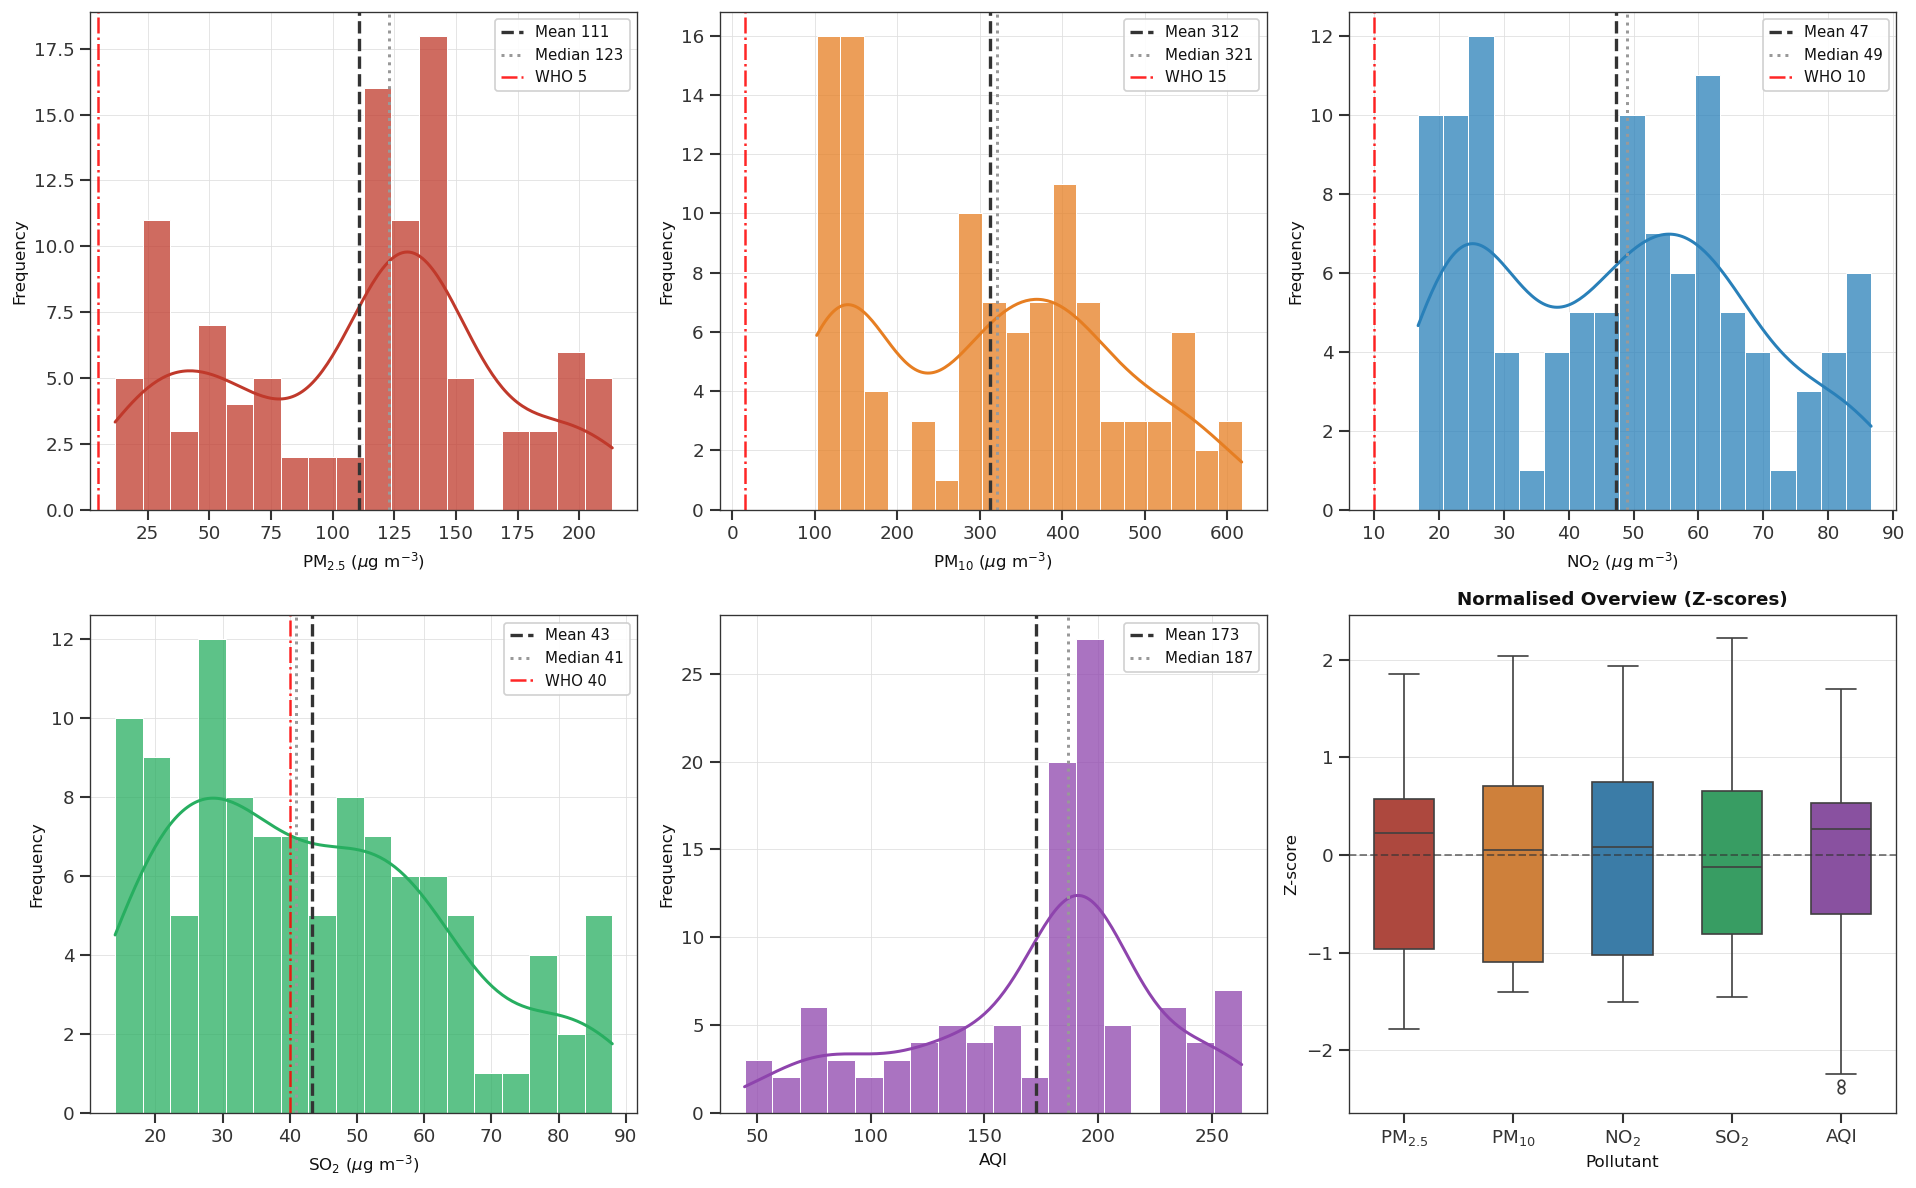

In [5]:
fig = viz.plot_distributions(df)
save_fig(fig, 'fig02_distributions')
plt.show()


### 2.4 Coefficient of Variation (Figure 2)
CV = σ/μ × 100 % measures relative variability.
Higher inter-annual CV indicates years with particularly divergent pollution levels;
higher intra-seasonal CV indicates inconsistent within-season behaviour.


Saved → figures/fig03_cv_analysis.png


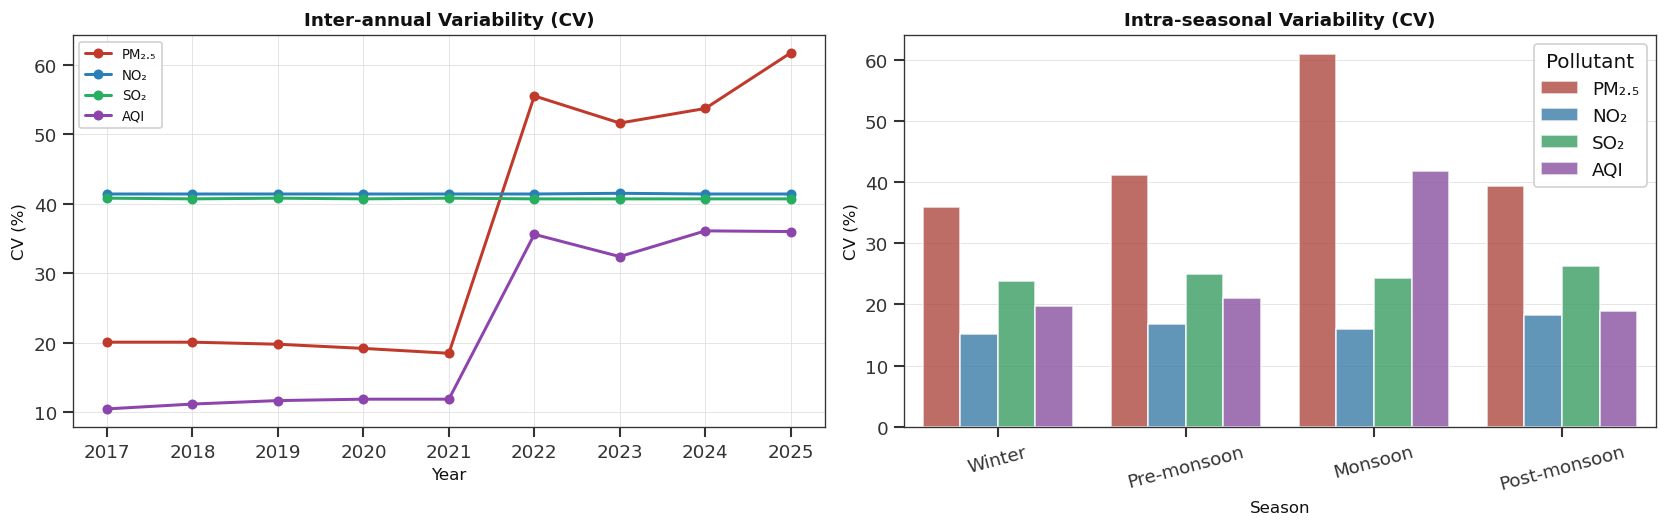

Year,CVPM2.5,CVNO2,CVSO2,CVAQI
2017,20.1,41.4,40.8,10.5
2018,20.1,41.4,40.7,11.2
2019,19.8,41.4,40.8,11.7
2020,19.2,41.4,40.7,11.9
2021,18.5,41.4,40.8,11.9
2022,55.5,41.4,40.7,35.6
2023,51.6,41.5,40.7,32.4
2024,53.7,41.4,40.7,36.1
2025,61.7,41.4,40.7,36.0


In [6]:
fig = viz.plot_cv_analysis(df)
save_fig(fig, 'fig03_cv_analysis')
plt.show()

from IPython.display import display, Latex

_cv_cols = ['pm25_mean', 'no2_mean', 'so2_mean', 'aqi_mean']
_cv = df.groupby('year')[_cv_cols].apply(lambda g: (g.std() / g.mean() * 100).round(1))

_rows = '\n'.join(
    f'  {int(yr)} & {r.pm25_mean:.1f} & {r.no2_mean:.1f} & {r.so2_mean:.1f} & {r.aqi_mean:.1f}' + r' \\'
    for yr, r in _cv.iterrows()
)

display(HTML(_pub_table(
    r'\textbf{Table.}\ Coefficient of variation (\%) by year.\\[4pt]' '\n'
    r'\begin{tabular}{crrrr}' '\n'
    r'\hline\hline' '\n'
    r'\textbf{Year} & $\mathrm{CV_{PM_{2.5}}}$ & $\mathrm{CV_{NO_2}}$'
    r' & $\mathrm{CV_{SO_2}}$ & $\mathrm{CV_{AQI}}$ \\' '\n'
    r'\hline' '\n'
    + _rows + '\n'
    r'\hline\hline' '\n'
    r'\end{tabular}'
)))

### 2.5 AQI category distribution
US EPA AQI categories applied to the monthly mean AQI series.
The proportion of months in each category quantifies the public-health burden.


Category,Months,% of Months
Good,2,1.9
Moderate,14,13.0
Unhealthy for Sensitive,14,13.0
Unhealthy,48,44.4
Very Unhealthy,28,25.9
Hazardous,2,1.9


Saved → figures/fig04_aqi_category_pie.png


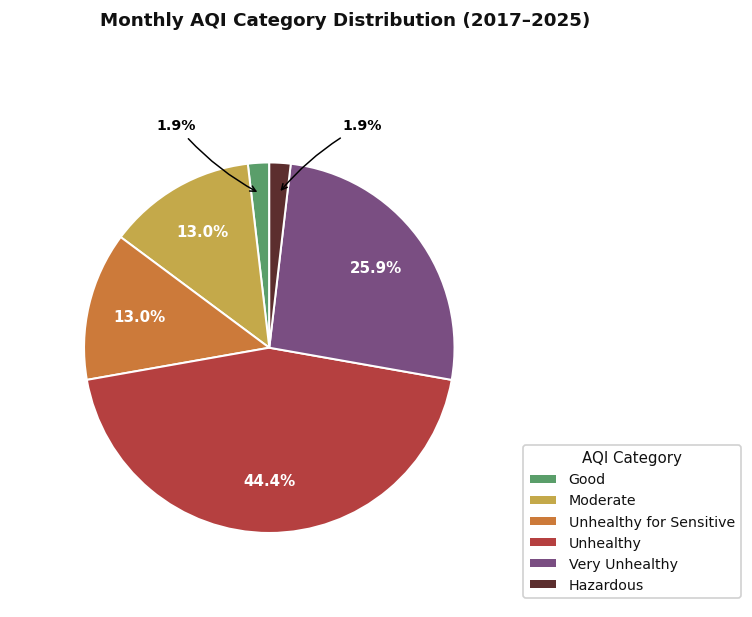

In [7]:
from src.analysis import aqi_category_distribution
from IPython.display import display, Latex

cat_df = aqi_category_distribution(df)

# ── LaTeX table ──────────────────────────────────────────────
_rows = '\n'.join(
    f'  {r.Category} & {int(r.Count)} & {r["% of Months"]:.1f}' + r' \\'
    for _, r in cat_df.iterrows()
)
display(HTML(_pub_table(
    r'\textbf{Table.}\ Monthly AQI category distribution, Dhaka City (2017--2025).\\[4pt]' '\n'
    r'\begin{tabular}{lrr}' '\n'
    r'\hline\hline' '\n'
    r'\textbf{Category} & \textbf{Months} & \textbf{\% of Months} \\' '\n'
    r'\hline' '\n'
    + _rows + '\n'
    r'\hline\hline' '\n'
    r'\end{tabular}'
)))

# ── Pie chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.5, 5.2))
_cat_colors = {c: col for _, _, c, col in AQI_CATS}
_nonzero = cat_df[cat_df['Count'] > 0].reset_index(drop=True)
_colors  = [_cat_colors[c] for c in _nonzero['Category']]
_total   = _nonzero['Count'].sum()

def _autopct(pct):
    return f'{pct:.1f}%' if pct >= 4 else ''

_wedges, _, _autotexts = ax.pie(
    _nonzero['Count'],
    colors=_colors,
    autopct=_autopct,
    startangle=90,
    pctdistance=0.72,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    radius=0.9,
)
for _at in _autotexts:
    _at.set_fontsize(9)
    _at.set_fontweight('bold')
    _at.set_color('white')

# Annotate small slices — percentage only, spread left/right, clear of title
_small_offsets = [(-0.45, 1.08), (0.45, 1.08)]
_small_idx = 0
for _wedge, (_, _row) in zip(_wedges, _nonzero.iterrows()):
    _pct = _row['Count'] / _total * 100
    if _pct < 4:
        _mid = np.radians((_wedge.theta1 + _wedge.theta2) / 2)
        _xa, _ya = 0.75 * np.cos(_mid), 0.75 * np.sin(_mid)
        _xt, _yt = _small_offsets[_small_idx]
        _small_idx += 1
        ax.annotate(
            f'{_pct:.1f}%',
            xy=(_xa, _ya), xytext=(_xt, _yt),
            ha='center', va='center',
            fontsize=8.5, color='black', fontweight='bold',
            arrowprops=dict(
                arrowstyle='->', color='black', lw=0.9,
                connectionstyle='arc3,rad=0.1',
            ),
        )

ax.legend(
    _wedges, _nonzero['Category'],
    title='AQI Category', title_fontsize=9,
    fontsize=8.5, loc='lower left',
    bbox_to_anchor=(0.98, 0.0),
    framealpha=0.9, edgecolor='#cccccc',
)
fig.suptitle('Monthly AQI Category Distribution (2017–2025)', y=0.98, fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
save_fig(fig, 'fig04_aqi_category_pie')
plt.show()

---
## § 3 — Long-Term Temporal Trends

### 3.1 Monthly time series (Figure 4)
All five pollutant/AQI series plotted with their monthly min–max range
(shaded band), 12-month centred rolling mean (dashed), WHO annual guideline
(dash-dot red), and COVID-19 lockdown period (gold shading, March–August 2020).


Saved → figures/fig05_monthly_time_series.png


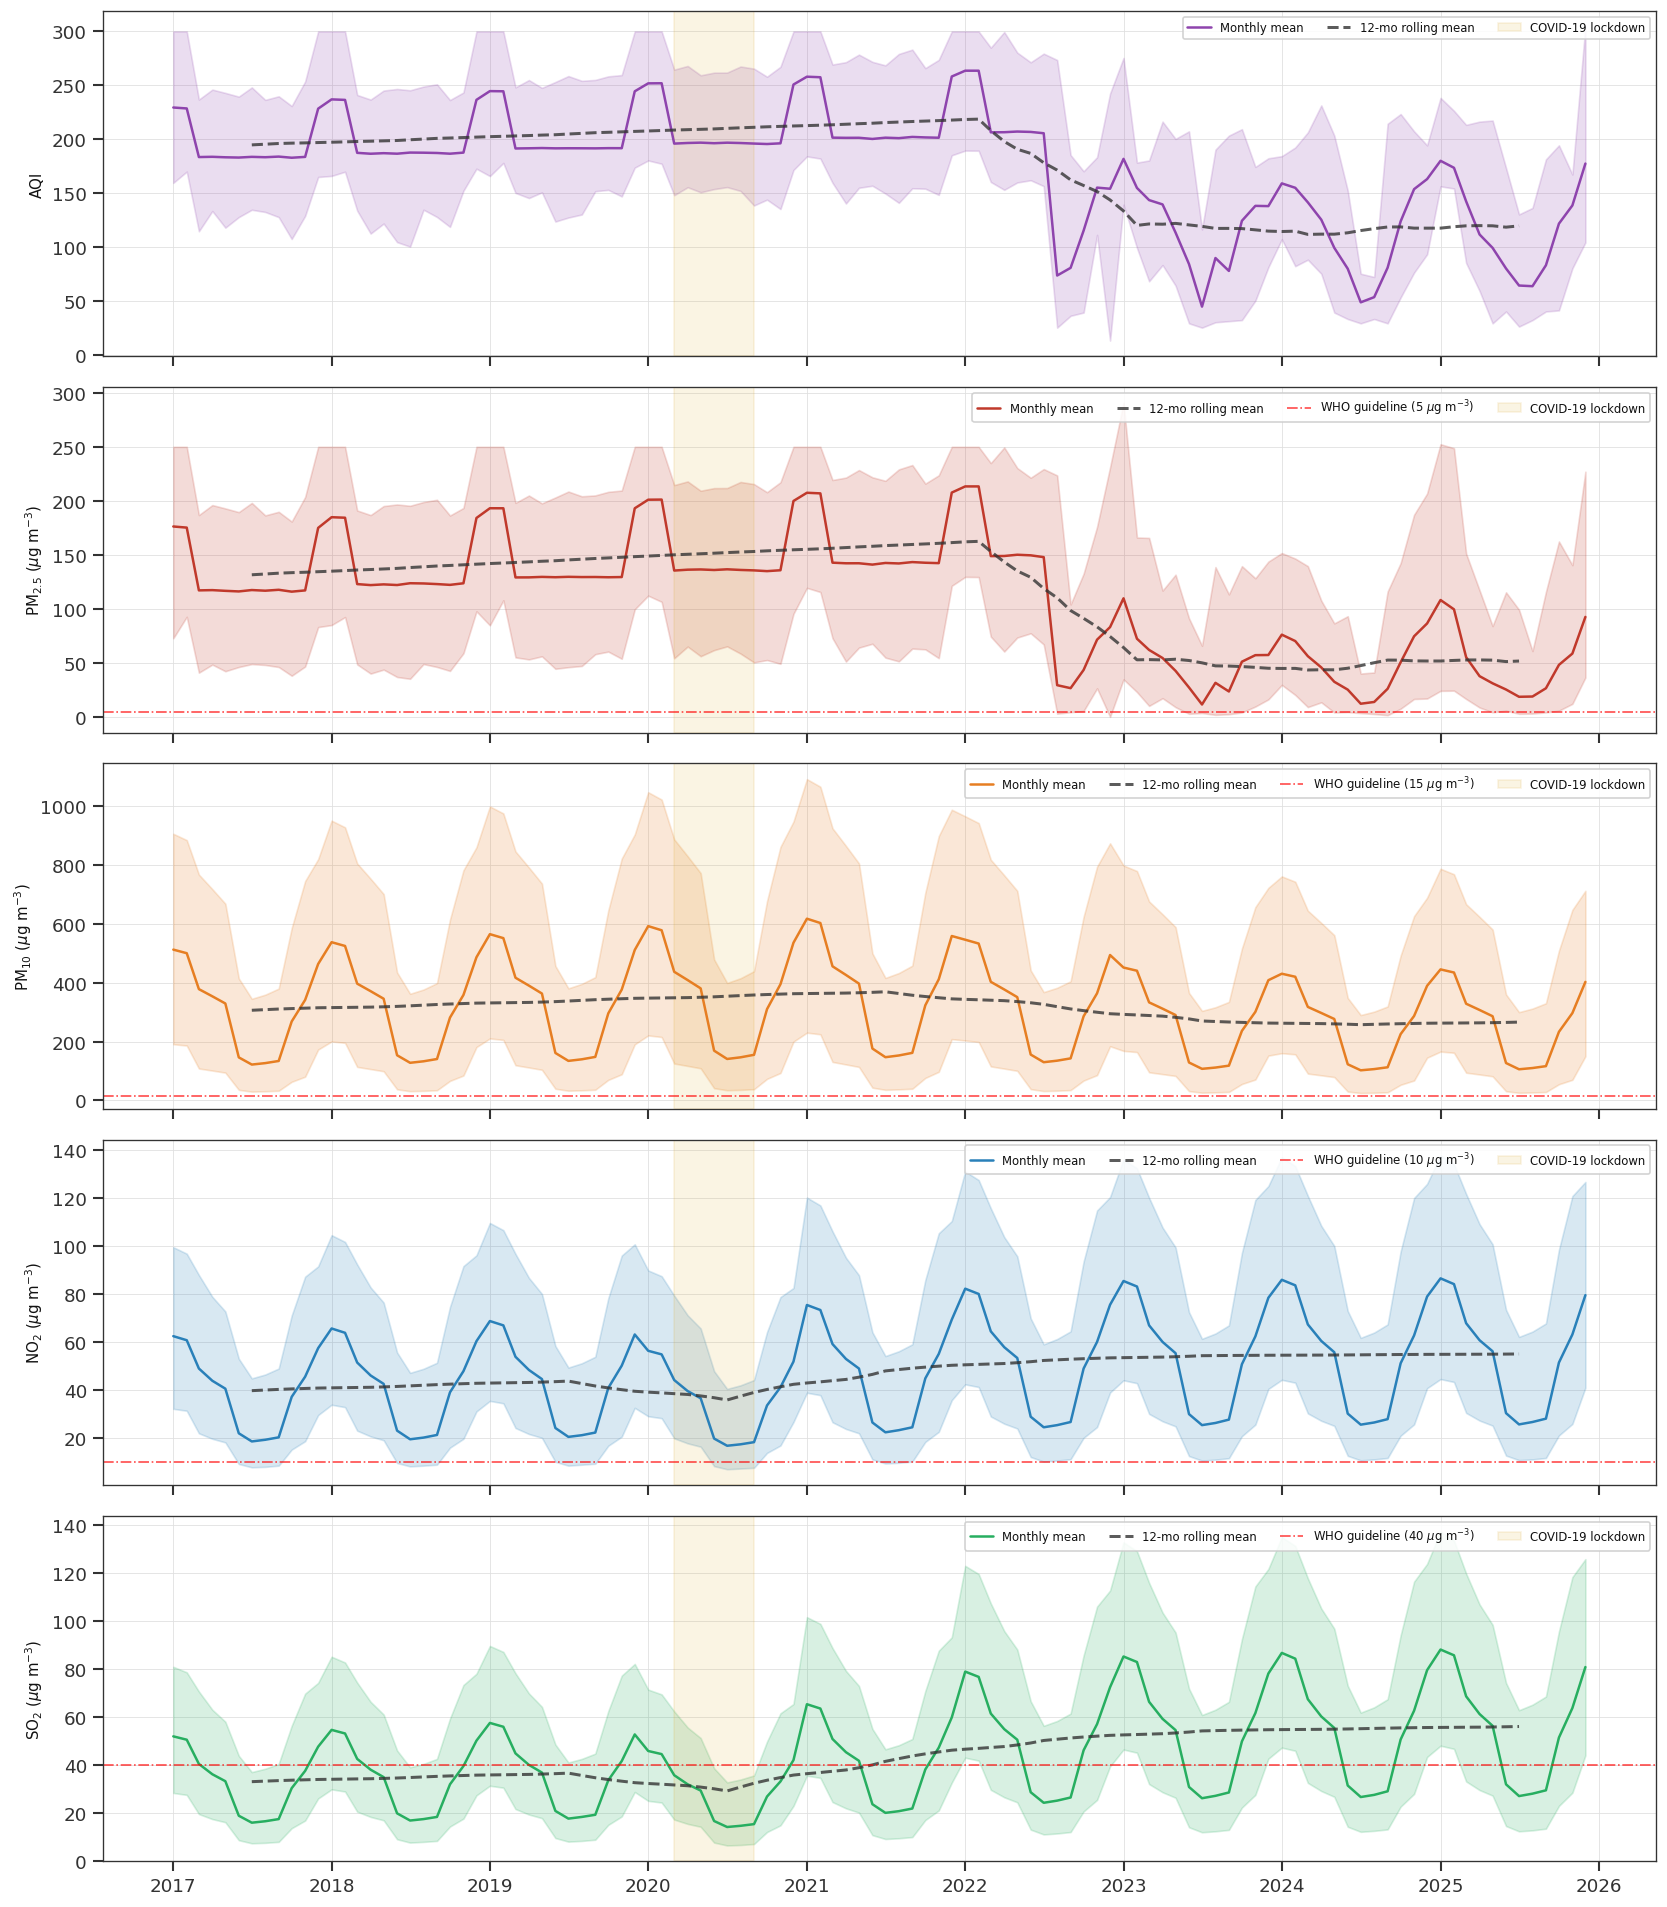

In [8]:
fig = viz.plot_monthly_time_series(df)
save_fig(fig, 'fig05_monthly_time_series')
plt.show()


### 3.2 Mann-Kendall trend tests
The non-parametric Mann-Kendall test is applied to each pollutant series.
Unlike OLS, it is robust to non-normality and seasonality effects and is
widely used in air-quality trend analysis.

H₀: No monotonic trend. Reject H₀ when p < 0.05.


In [9]:
from src.analysis import run_mann_kendall_all, ols_trend_table
from IPython.display import display, Latex

mk_df = run_mann_kendall_all(df)

_idx_map = {
    'PM\u2082.\u2085 (\u00b5g/m\u00b3)': r'$\mathrm{PM}_{2.5}$',
    'PM\u2081\u2080 (\u00b5g/m\u00b3)':  r'$\mathrm{PM}_{10}$',
    'NO\u2082 (\u00b5g/m\u00b3)':        r'$\mathrm{NO}_2$',
    'SO\u2082 (\u00b5g/m\u00b3)':        r'$\mathrm{SO}_2$',
    'AQI':                                'AQI',
}
_rows = '\n'.join(
    '  ' + _idx_map.get(str(var), str(var))
    + f' & {int(r.S):+d} & {r.z:.3f} & {r.p:.4f} & '
    + str(r.Trend).replace('\u2193', r'$\downarrow$').replace('\u2191', r'$\uparrow$')
    + r' \\'
    for var, r in mk_df.iterrows()
)

display(HTML(_pub_table(
    r'\textbf{Table.}\ Mann--Kendall monotonic trend test ($n = 108$ months).\\[4pt]' '\n'
    r'\begin{tabular}{lrrrr}' '\n'
    r'\hline\hline' '\n'
    r'\textbf{Variable} & $S$ & $z$ & $p$ & \textbf{Trend} \\' '\n'
    r'\hline' '\n'
    + _rows + '\n'
    r'\hline\hline' '\n'
    r'\end{tabular}' '\n\n'
    r'\textit{Significance:} $p < 0.05 \Rightarrow$ statistically significant trend.'
)))

Variable,S,z,p,Trend
PM2.5,-1673,-4.439,0.0000,↓ Decreasing
PM10,-824,-2.185,0.0289,↓ Decreasing
NO2,+1152,3.056,0.0022,↑ Increasing
SO2,+1540,4.086,0.0000,↑ Increasing
AQI,-1661,-4.407,0.0000,↓ Decreasing


### 3.3 OLS regression table
OLS regression of each pollutant against calendar year, reported
with slope, standard error, t-statistic, p-value, and R².


In [10]:
from IPython.display import display, Latex

ols_table = ols_trend_table(df)

_idx_map = {
    'PM\u2082.\u2085 (\u00b5g/m\u00b3)': r'$\mathrm{PM}_{2.5}$',
    'PM\u2081\u2080 (\u00b5g/m\u00b3)':  r'$\mathrm{PM}_{10}$',
    'NO\u2082 (\u00b5g/m\u00b3)':        r'$\mathrm{NO}_2$',
    'SO\u2082 (\u00b5g/m\u00b3)':        r'$\mathrm{SO}_2$',
    'AQI':                                'AQI',
}
_R2 = 'R²'
_rows = '\n'.join(
    '  ' + _idx_map.get(str(var), str(var))
    + f' & {r.Slope:.3f} & {r.SE:.4f} & {r.t:.3f} & {r.p:.4f} & {r[_R2]:.3f} & {r.Sig}' + r' \\'
    for var, r in ols_table.iterrows()
)

display(HTML(_pub_table(
    r'\textbf{Table.}\ OLS regression: pollutant $\sim$ year (2017--2025).\\[4pt]' '\n'
    r'\begin{tabular}{lrrrrrr}' '\n'
    r'\hline\hline' '\n'
    r'\textbf{Variable} & \textbf{Slope} & \textbf{SE} & $t$ & $p$ & $R^2$ & \textbf{Sig.} \\' '\n'
    r'\hline' '\n'
    + _rows + '\n'
    r'\hline\hline' '\n'
    r'\end{tabular}' '\n\n'
    r'\textit{Significance codes:} $^{***}p<0.001$, $^{**}p<0.01$, $^{*}p<0.05$.'
)))

Variable,Slope,SE,t,p,R2,Sig.
PM2.5,-13.574,1.6044,-8.460,0.0000,0.403,***
PM10,-8.603,5.5434,-1.550,0.1237,0.022,
NO2,2.295,0.7245,3.170,0.0020,0.086,**
SO2,3.489,0.6710,5.200,0.0000,0.203,***
AQI,-12.598,1.5749,-8.000,0.0000,0.376,***


### 3.4 Annual concentration trends (Figure 5)
Annual mean concentrations and AQI with OLS trend lines and year-over-year
percentage change annotations.


Saved → figures/fig06_annual_trends.png


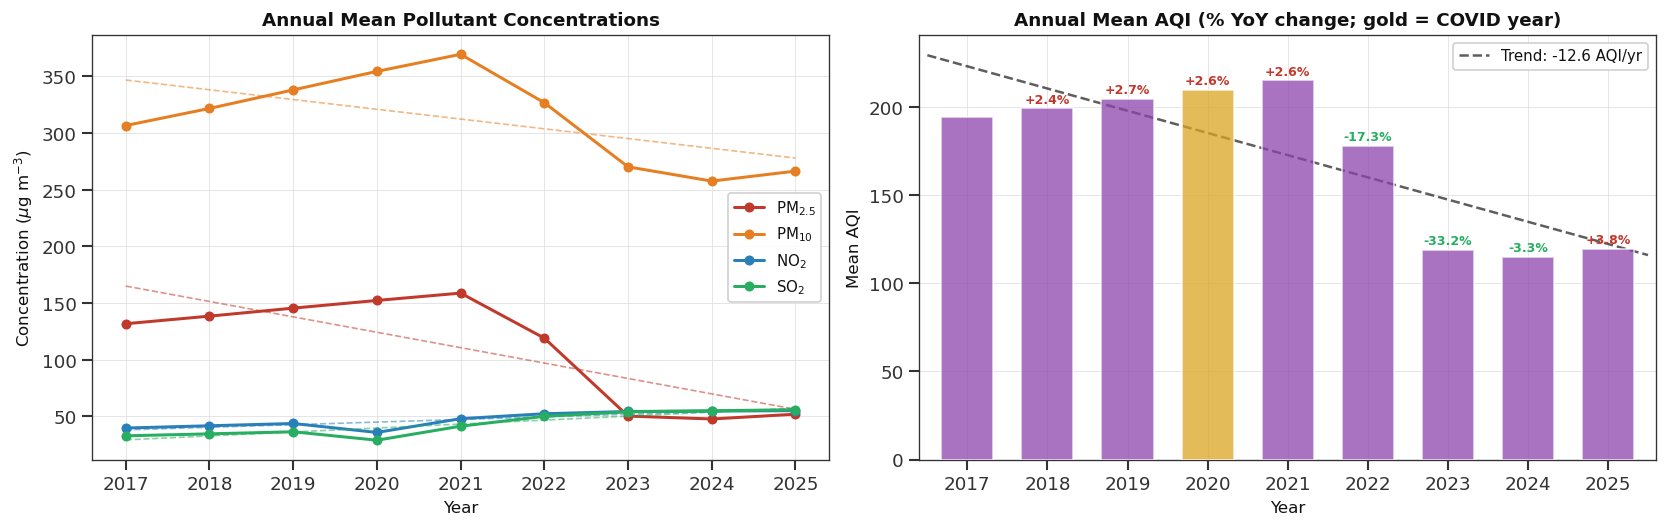

Year,PM2.5,PM10,NO2,SO2,AQI
,(µg m-3),(µg m-3),(µg m-3),(µg m-3),
2017,131.7,306.4,39.8,32.9,194.4
2018,138.4,321.5,41.8,34.6,199.2
2019,145.5,337.8,43.8,36.5,204.5
2020,152.2,354.1,35.9,29.0,209.8
2021,158.7,369.2,48.0,41.4,215.1
2022,119.0,326.5,52.4,50.1,177.9
2023,50.3,270.0,54.4,54.1,118.9
2024,47.8,257.4,54.7,55.0,115.0
2025,52.0,266.2,55.1,55.9,119.4


In [11]:
fig = viz.plot_annual_trends(df, annual)
save_fig(fig, 'fig06_annual_trends')
plt.show()

# ── Table: Annual mean concentrations (LaTeX) ─────────────────────────────────
from IPython.display import display, Latex

tbl = annual[['year', 'pm25_mean', 'pm10_mean', 'no2_mean', 'so2_mean', 'aqi_mean']].copy()

rows = "\n".join(
    f"  {int(r.year)} & {r.pm25_mean:.1f} & {r.pm10_mean:.1f} & "
    f"{r.no2_mean:.1f} & {r.so2_mean:.1f} & {r.aqi_mean:.1f} \\\\"
    for _, r in tbl.iterrows()
)

display(HTML(_pub_table(
    r"\textbf{Table 1.}\ Annual mean pollutant concentrations and AQI,"
    r" Dhaka City (2017--2025).\\[6pt]" + "\n"
    r"\begin{tabular}{crrrrr}" + "\n"
    r"\hline\hline" + "\n"
    r"\textbf{Year} & $\mathbf{PM_{2.5}}$ & $\mathbf{PM_{10}}$"
    r" & $\mathbf{NO_2}$ & $\mathbf{SO_2}$ & \textbf{AQI} \\" + "\n"
    r"& ($\mu\text{g\,m}^{-3}$) & ($\mu\text{g\,m}^{-3}$)"
    r" & ($\mu\text{g\,m}^{-3}$) & ($\mu\text{g\,m}^{-3}$) & \\" + "\n"
    r"\hline" + "\n"
    + rows + "\n"
    r"\hline\hline" + "\n"
    r"\end{tabular}"
)))

### 3.5 Year-by-year distribution (Figure B)

Year-by-year box plots show the **spread** of 12 monthly values within each
calendar year, not just the annual mean. Widening boxes indicate increasing
intra-annual variability; the gold box marks the COVID-19 year (2020).
This panel is particularly informative for detecting volatility changes
alongside secular trends.


Saved → figures/fig07_interannual_boxplots.png


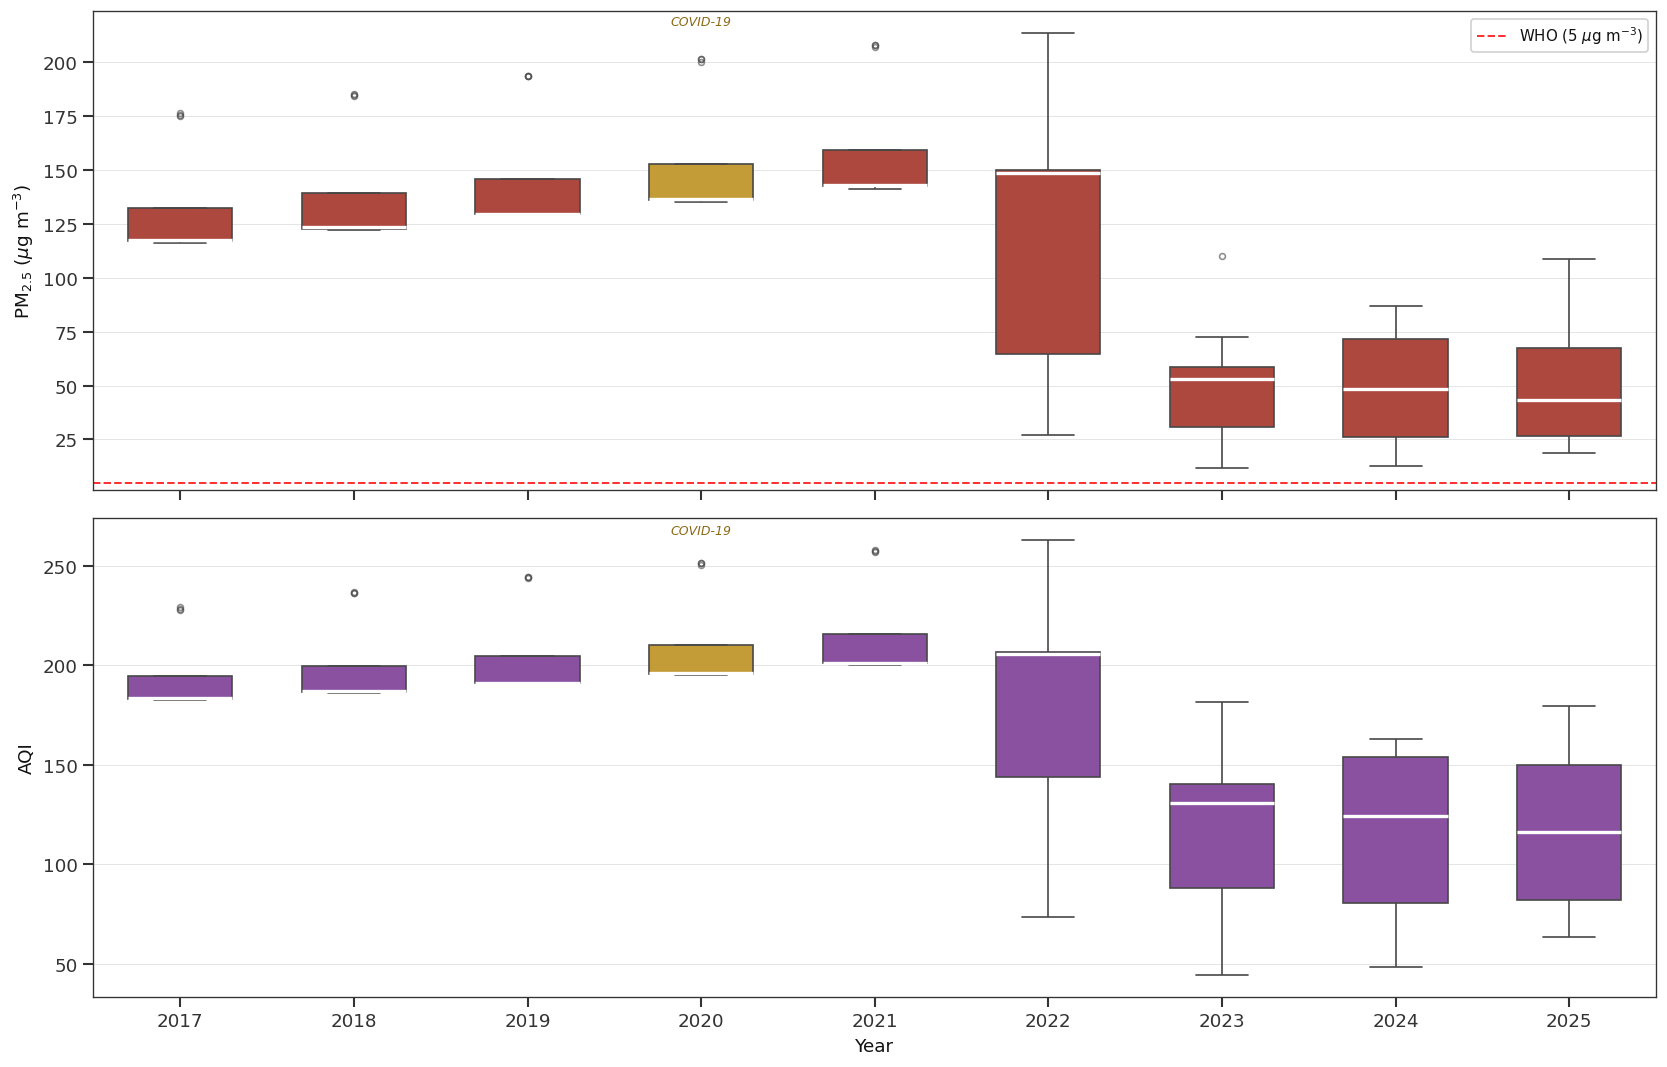

In [12]:
fig = viz.plot_interannual_boxplots(df)
save_fig(fig, 'fig07_interannual_boxplots')
plt.show()


---
## § 4 — Seasonal & Monthly Climatology

Bangladesh experiences four meteorological seasons:

| Season | Months | Key meteorology |
|---|---|---|
| **Winter** | Dec–Feb | Cool, dry; NE trade winds carry smoke/dust |
| **Pre-monsoon** | Mar–May | Hot, increasingly humid; dust events |
| **Monsoon** | Jun–Sep | Heavy rainfall; washout of particulates |
| **Post-monsoon** | Oct–Nov | Transitional; PM begins rising again |

### 4.1 Monthly climatology (Figure 6)
Multi-year mean concentration profiles for all four seasons.


Saved → figures/fig08_monthly_climatology.png


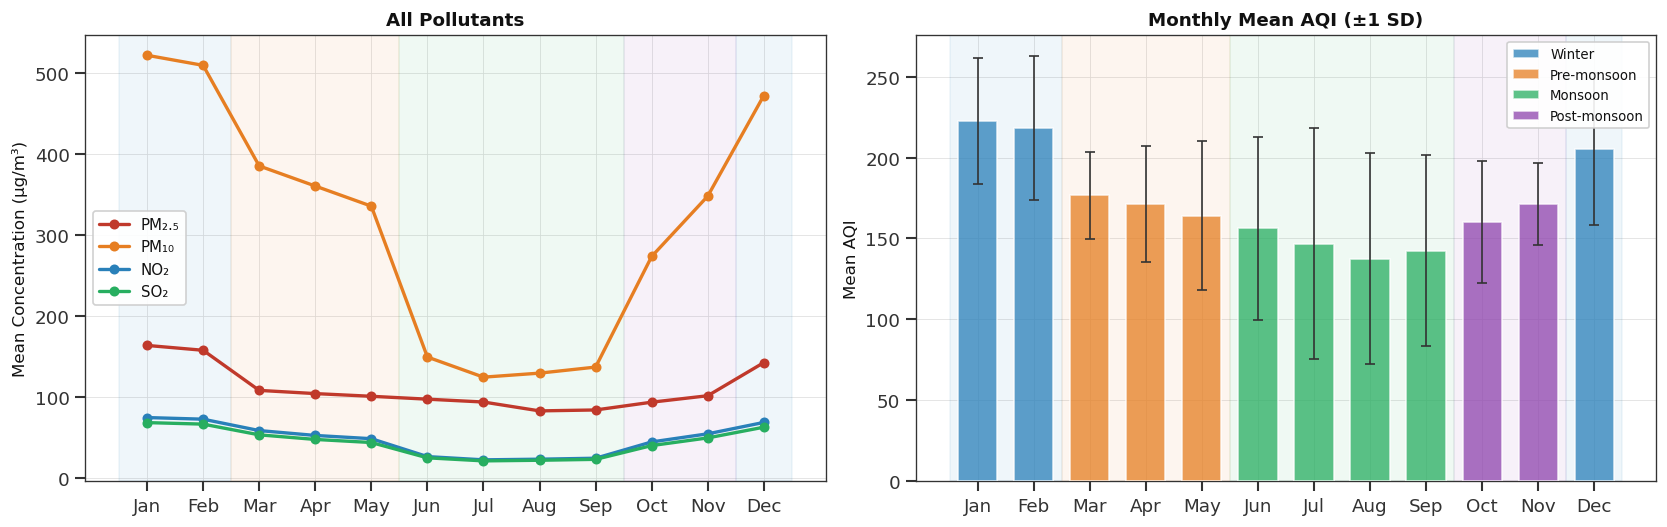

In [13]:
fig = viz.plot_monthly_climatology(df, clim)
save_fig(fig, 'fig08_monthly_climatology')
plt.show()


### 4.2 Year × Month AQI heat map (Figure 7)
A heat map with annotated cell values provides simultaneous information
on seasonal cycles and inter-annual change.


Saved → figures/fig09_aqi_heatmap.png


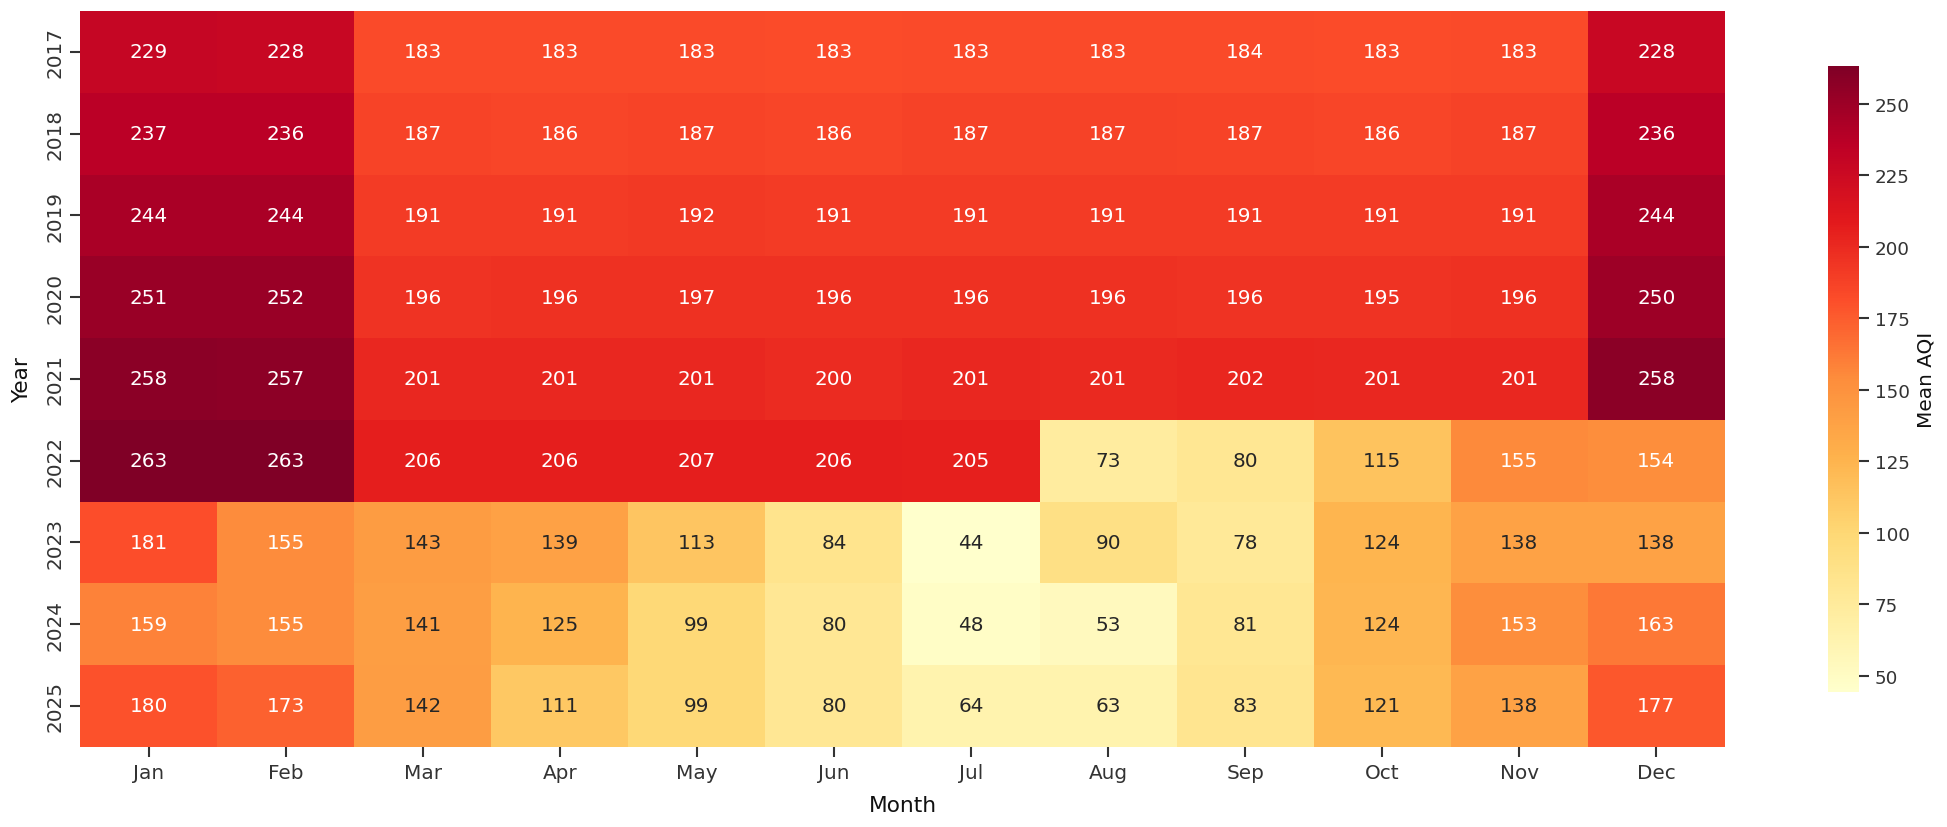

In [14]:
fig = viz.plot_aqi_heatmap(df)
save_fig(fig, 'fig09_aqi_heatmap')
plt.show()


### 4.3 Seasonal distribution & AQI category analysis (Figure 8)
Seaborn box plots show IQR and outliers for each pollutant by season.
A radar (spider) chart normalises all pollutants to [0,1] and overlays
seasonal profiles. A year-over-year AQI overlay uses a diverging colourmap
(blue = earlier, red = recent). The final panel shows the US EPA AQI
category distribution.


Saved → figures/fig10_seasonal_distributions.png


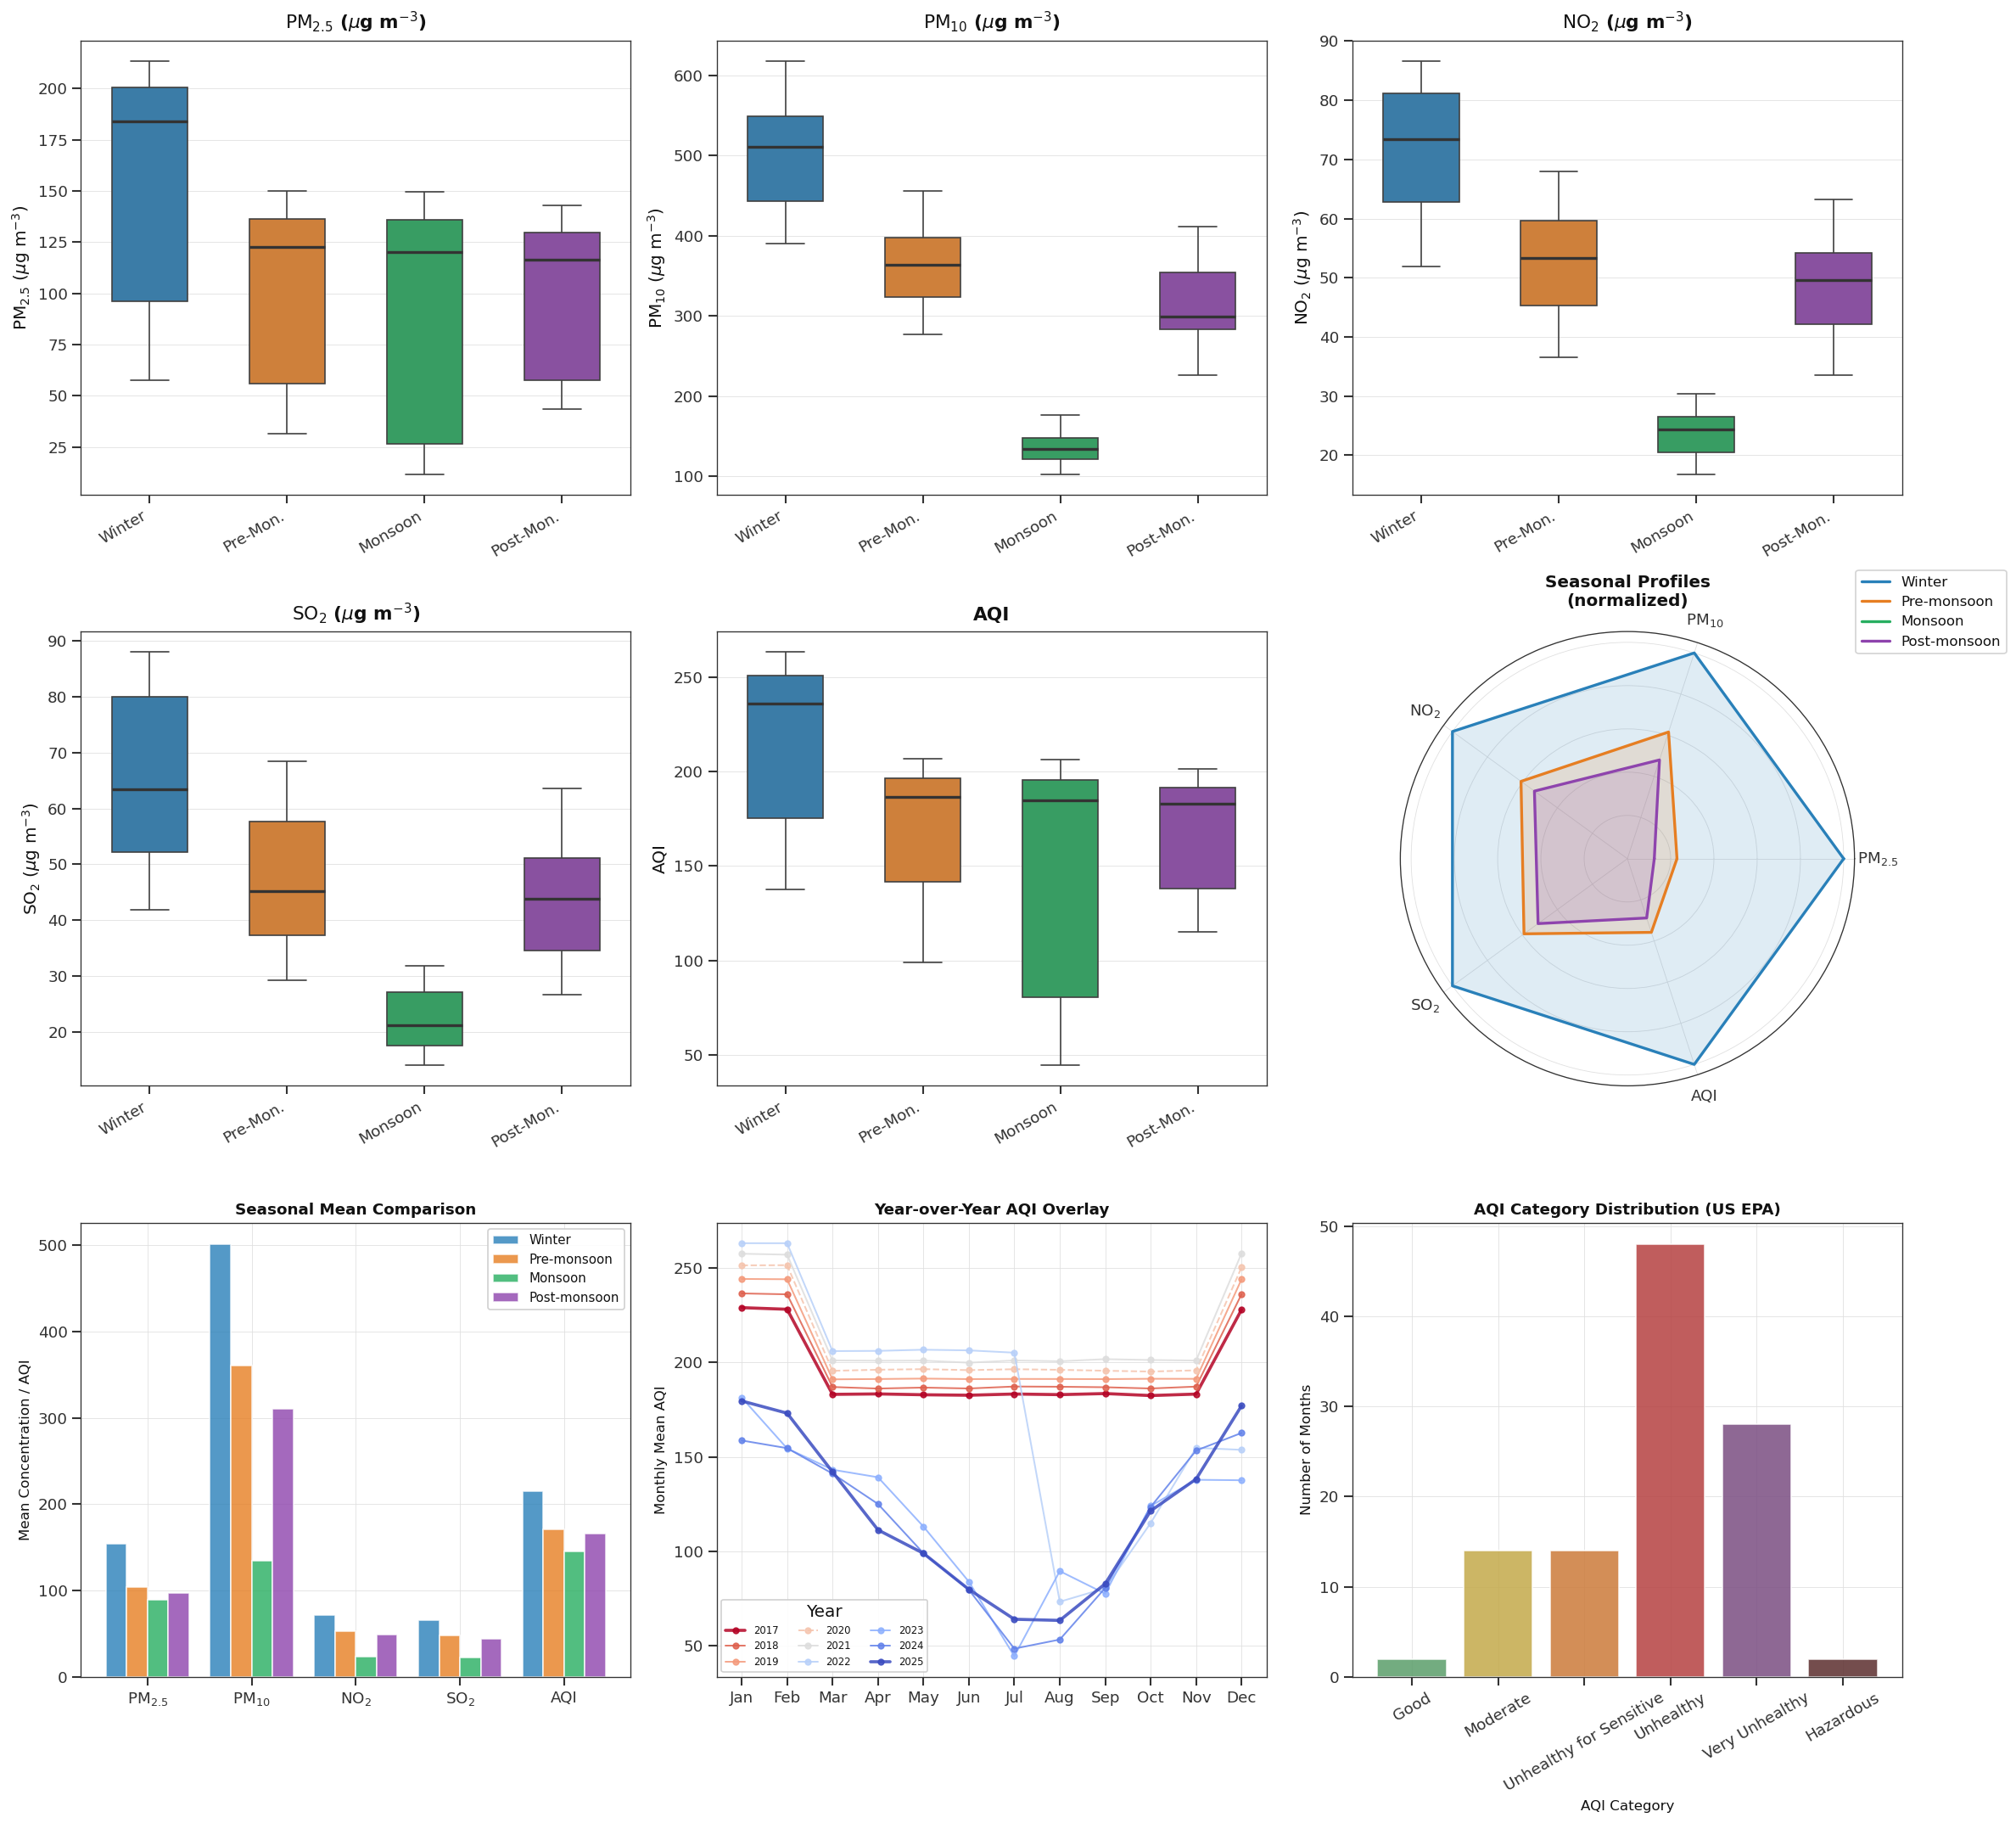

In [15]:
fig = viz.plot_seasonal_distributions(df)
save_fig(fig, 'fig10_seasonal_distributions')
plt.show()


### 4.4 Violin plots by season (Figure A)

Violin plots reveal the full distribution shape — multi-modality, skewness,
and tail behaviour — which box plots suppress. The inner lines mark the
inter-quartile range and median. WHO annual guidelines are overlaid as
dashed red reference lines.


Saved → figures/fig11_violin_by_season.png


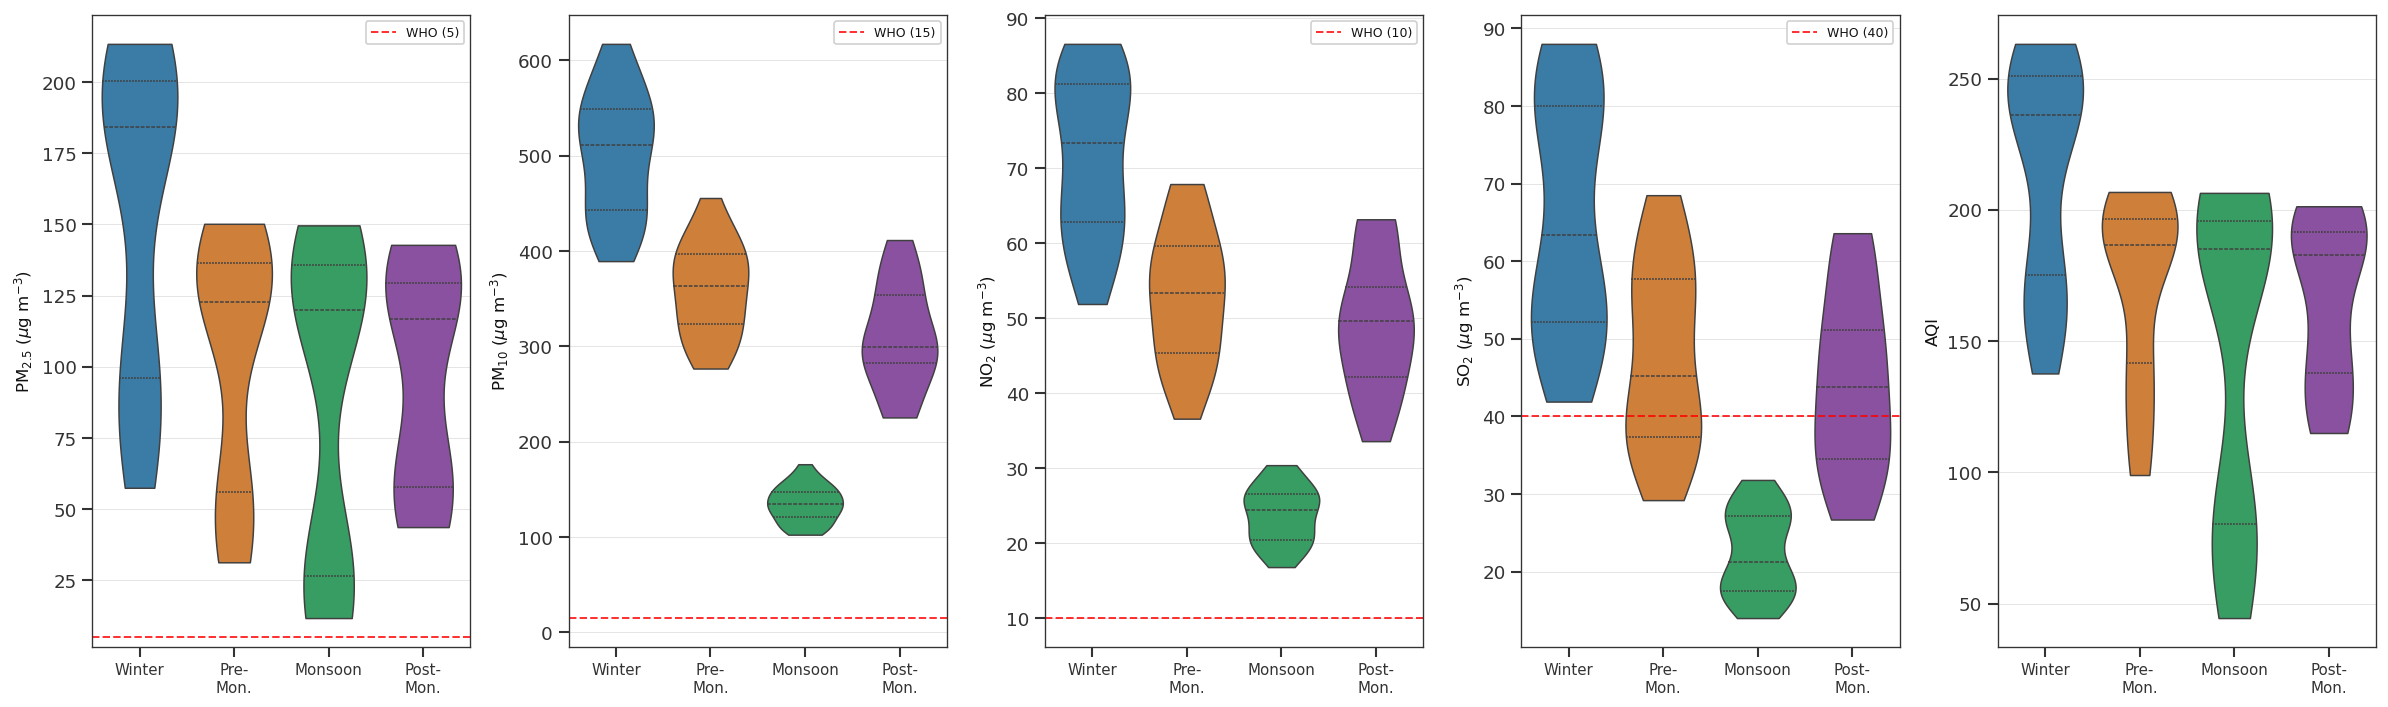

In [16]:
fig = viz.plot_violin_by_season(df)
save_fig(fig, 'fig11_violin_by_season')
plt.show()


---
## § 5 — Time-Series Diagnostics

### 5.1 Augmented Dickey-Fuller stationarity tests
H₀: Series has a unit root (non-stationary).  
p < 0.05 → reject H₀ → series is stationary.
First-differenced series are also tested to inform SARIMA differencing order.


In [17]:
from src.analysis import run_adf_all
from IPython.display import display, Latex

adf_results = run_adf_all(df)

_adf_idx_map = {
    'PM₂.₅ (µg/m³)': r'$\mathrm{PM}_{2.5}$',
    'PM₁₀ (µg/m³)':  r'$\mathrm{PM}_{10}$',
    'NO₂ (µg/m³)':        r'$\mathrm{NO}_2$',
    'SO₂ (µg/m³)':        r'$\mathrm{SO}_2$',
    'AQI':                               'AQI',
}
_adf_suffix_map = [
    ('PM₂.₅ (µg/m³)', r'$\mathrm{PM}_{2.5}$'),
    ('PM₁₀ (µg/m³)',  r'$\mathrm{PM}_{10}$'),
    ('NO₂ (µg/m³)',        r'$\mathrm{NO}_2$'),
    ('SO₂ (µg/m³)',        r'$\mathrm{SO}_2$'),
]
def _adf_label(var):
    s = str(var)
    exact = _adf_idx_map.get(s)
    if exact:
        return exact
    for key, latex in _adf_suffix_map:
        if s.startswith(key):
            suffix = s[len(key):]
            suffix_clean = suffix.replace('Δ1', r'$\Delta^1$').replace('Δ', r'$\Delta$')
            return latex + suffix_clean
    return s
_rows = '\n'.join(
    '  ' + _adf_label(r.Variable)
    + f' & {r["ADF stat"]:.4f} & {r["p-value"]:.4f} & {int(r.Lags)} & {r.Result}' + r' \\'
    for _, r in adf_results.iterrows()
)

display(HTML(_pub_table(
    r'\textbf{Table.}\ Augmented Dickey--Fuller stationarity tests.\\[4pt]' '\n'
    r'\begin{tabular}{lrrrr}' '\n'
    r'\hline\hline' '\n'
    r'\textbf{Variable} & \textbf{ADF stat} & $p$ & \textbf{Lags} & \textbf{Result} \\' '\n'
    r'\hline' '\n'
    + _rows + '\n'
    r'\hline\hline' '\n'
    r'\end{tabular}' '\n\n'
    r'\textit{Interpretation:} If original series is non-stationary but $\Delta^1$ is'
    r' stationary $\Rightarrow d=1$ for SARIMA.'
)))

Variable,ADF stat,p,Lags,Result
PM2.5,-1.1686,0.6870,13,Non-stationary ✗
PM10,-1.0496,0.7347,12,Non-stationary ✗
NO2,-0.8248,0.8117,12,Non-stationary ✗
SO2,-0.5488,0.8821,12,Non-stationary ✗
AQI,-0.9229,0.7804,13,Non-stationary ✗
PM2.5 (Δ1),-2.2337,0.1942,12,Non-stationary ✗
PM10 (Δ1),-2.3709,0.1501,11,Non-stationary ✗
NO2 (Δ1),-3.4974,0.0081,11,Stationary ✓
SO2 (Δ1),-3.1250,0.0248,11,Stationary ✓
AQI (Δ1),-2.5063,0.1139,12,Non-stationary ✗


### 5.2 ACF and PACF plots
Autocorrelation and partial autocorrelation functions are plotted to lags 36
(3 years) to identify the seasonal AR/MA structure. Significant peaks at
lags 12 and 24 confirm annual periodicity.


Saved → figures/fig12_acf_pacf.png


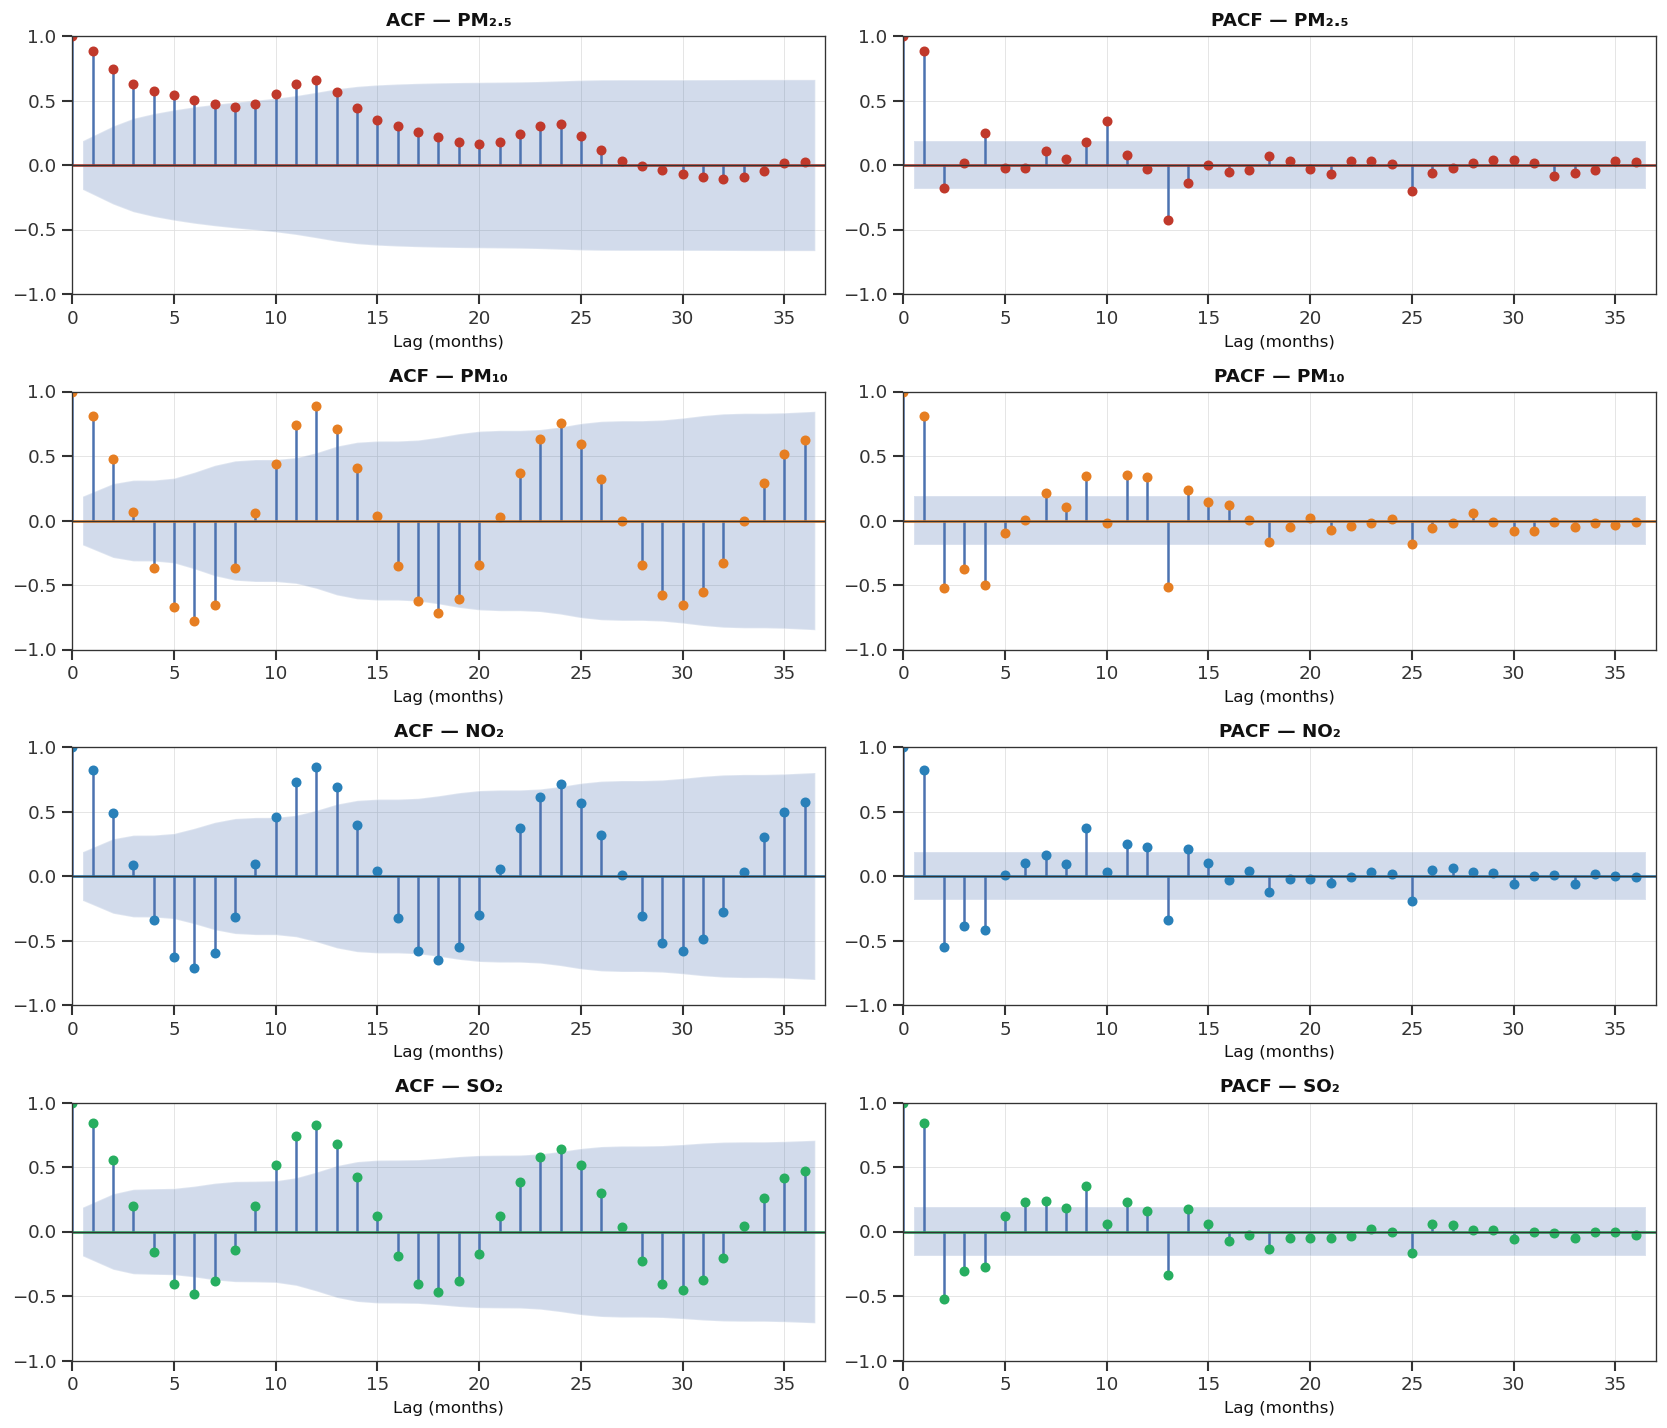

In [18]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
for i, (col, label, color) in enumerate([
    ('pm25_mean','PM\u2082.\u2085',PAL['pm25']),
    ('pm10_mean','PM\u2081\u2080', PAL['pm10']),
    ('no2_mean','NO\u2082',       PAL['no2']),
    ('so2_mean','SO\u2082',       PAL['so2']),
]):
    series = df[col].dropna()
    plot_acf(series,  ax=axes[i,0], lags=36, alpha=0.05, color=color, title=f'ACF \u2014 {label}')
    plot_pacf(series, ax=axes[i,1], lags=36, alpha=0.05, method='ywm', color=color, title=f'PACF \u2014 {label}')
    for ax in axes[i]:
        ax.set_xlabel('Lag (months)'); ax.axhline(0, color='#333', lw=0.8)
        ax.set_xlim(0, 37)
plt.tight_layout()
save_fig(fig, 'fig12_acf_pacf')
plt.show()


### 5.3 STL decomposition of PM₂.₅ (Figure 10)
Additive seasonal decomposition extracts the long-run trend, annual seasonal
component, and residual for PM₂.₅. The trend component reveals underlying
structural change independent of seasonal cycles.


Saved → figures/fig13_stl_decomposition.png


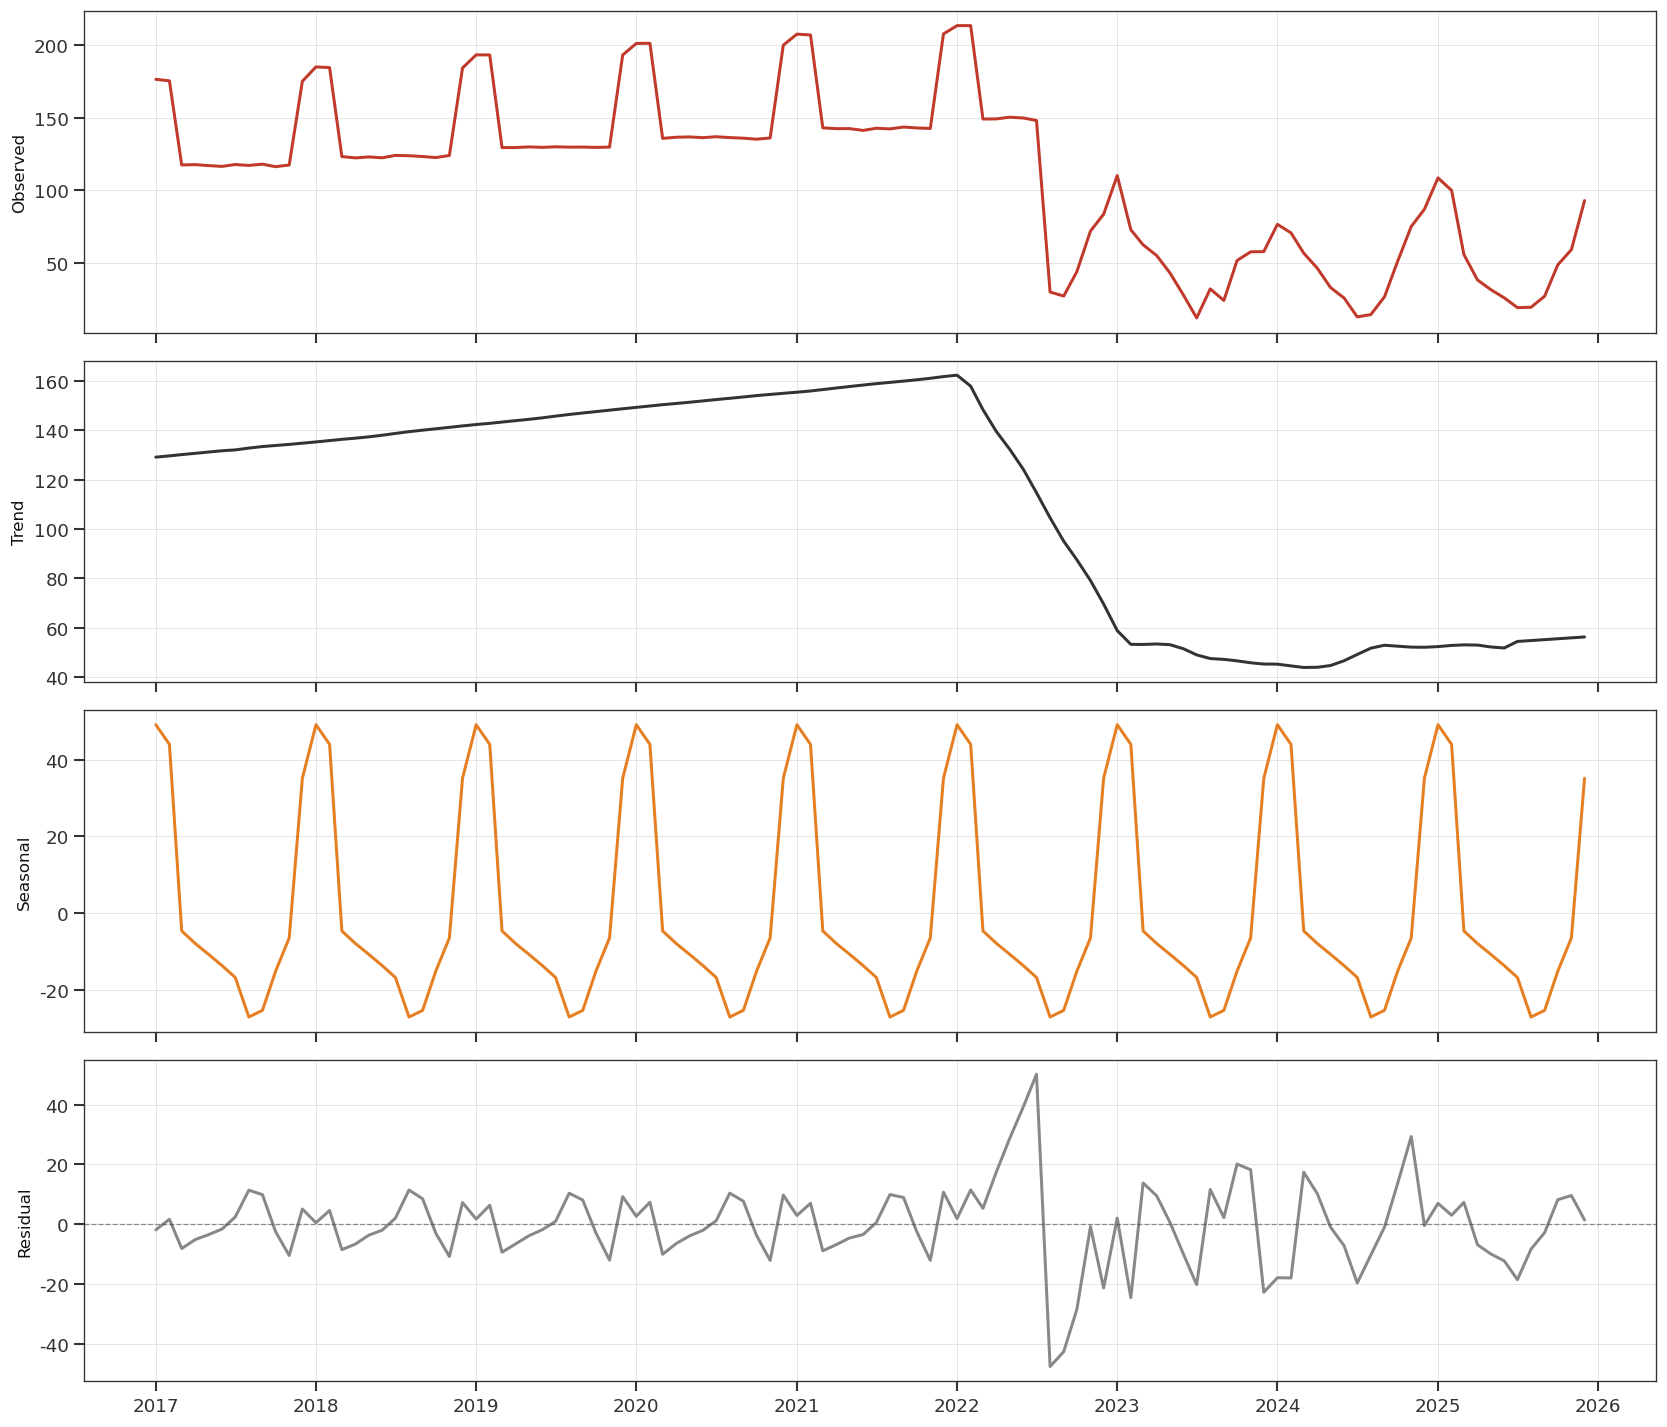

In [19]:
fig = viz.plot_stl_decomposition(df, target='pm25_mean')
save_fig(fig, 'fig13_stl_decomposition')
plt.show()


### 5.4 Anomaly detection (Figure 11)
Months with Z-score |Z| > 2 for PM₂.₅ are flagged as anomalies.
These correspond to extreme pollution episodes often linked to meteorological
stagnation, crop-residue burning episodes, or industrial accidents.


Saved → figures/fig14_anomaly_detection.png


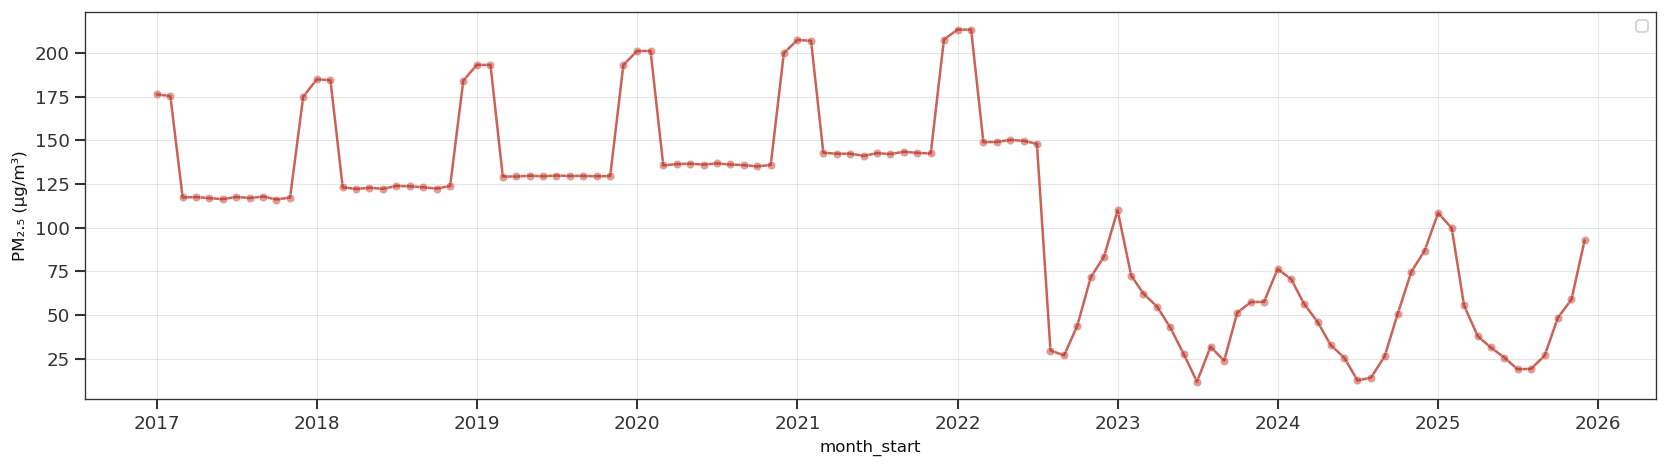

Anomalous months (|Z| > 2): 0


In [20]:
fig = viz.plot_anomaly_detection(df)
save_fig(fig, 'fig14_anomaly_detection')
plt.show()

from IPython.display import display, Latex

_anom = df[['month_start', 'pm25_mean']].copy()
_mu, _sig = _anom['pm25_mean'].mean(), _anom['pm25_mean'].std()
_anom['z'] = (_anom['pm25_mean'] - _mu) / _sig
_anoms = _anom[_anom['z'].abs() > 2].sort_values('z', key=abs, ascending=False)

if _anoms.empty:
    display(HTML(_pub_table(
        r'\textit{No anomalous months detected} ($|Z| > 2$) '
        r'for $\mathrm{PM}_{2.5}$ in the 2017--2025 period.'
    )))
else:
    _rows = '\n'.join(
        f'  {r.month_start.strftime("%b %Y")} & {r.pm25_mean:.2f} & {r.z:+.3f}' + r' \\'
        for _, r in _anoms.iterrows()
    )
    display(HTML(_pub_table(
        r'\textbf{Table.}\ Anomalous months ($|Z| > 2$) for $\mathrm{PM}_{2.5}$.\\[4pt]' '\n'
        r'\begin{tabular}{lrr}' '\n'
        r'\hline\hline' '\n'
        r'\textbf{Month} & $\mathrm{PM}_{2.5}$ ($\mu\mathrm{g\,m}^{-3}$) & $Z$ \\' '\n'
        r'\hline' '\n'
        + _rows + '\n'
        r'\hline\hline' '\n'
        r'\end{tabular}'
    )))
print(f'Anomalous months (|Z| > 2): {len(_anoms)}')

### 5.5 PM₂.₅/PM₁₀ ratio — source apportionment (Figure 12)
The PM₂.₅/PM₁₀ ratio is a proxy for pollution source type:  
- **ratio > 0.6**: combustion-dominated (vehicles, biomass burning, coal)  
- **ratio < 0.4**: coarse-particle sources (road dust, construction, soil)

Values between 0.4 and 0.6 suggest a mixed source profile.


Saved → figures/fig15_pm_ratio.png


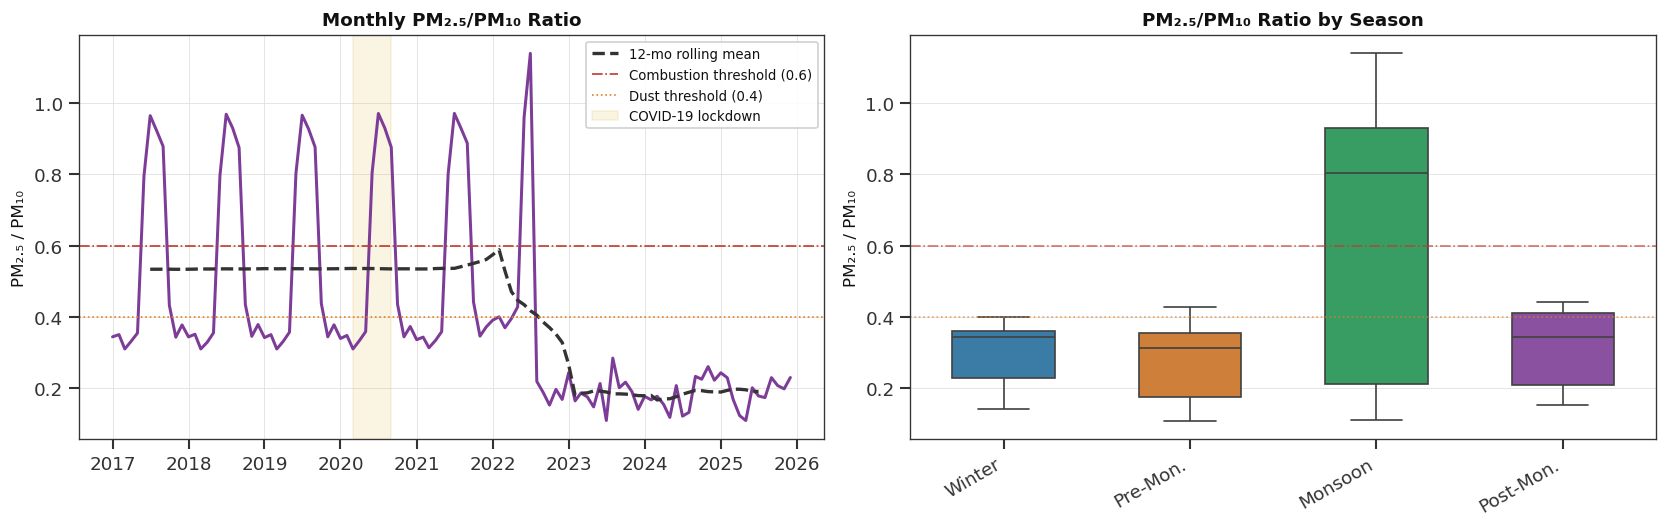

Year,PM2.5/PM10
2017,0.534
2018,0.535
2019,0.535
2020,0.535
2021,0.536
2022,0.417
2023,0.190
2024,0.183
2025,0.191


In [21]:
fig = viz.plot_pm_ratio(df)
save_fig(fig, 'fig15_pm_ratio')
plt.show()

from IPython.display import display, Latex

_ratio = df.groupby('year')['pm_ratio'].mean().round(3)

_rows = '\n'.join(
    f'  {int(yr)} & {v:.3f}' + r' \\'
    for yr, v in _ratio.items()
)

display(HTML(_pub_table(
    r'\textbf{Table.}\ Annual mean $\mathrm{PM}_{2.5}/\mathrm{PM}_{10}$ ratio'
    r' (source apportionment proxy).\\[4pt]' '\n'
    r'\begin{tabular}{cr}' '\n'
    r'\hline\hline' '\n'
    r'\textbf{Year} & $\mathrm{PM}_{2.5}/\mathrm{PM}_{10}$ \\' '\n'
    r'\hline' '\n'
    + _rows + '\n'
    r'\hline\hline' '\n'
    r'\end{tabular}' '\n\n'
    r'\textit{Note:} ratio $> 0.6$ = combustion-dominated; $< 0.4$ = coarse-particle sources.'
)))

---
## § 6 — Pollutant Inter-relationships

### 6.1 Spearman correlation matrix (Figure 13)
Spearman's rank correlation is used throughout (instead of Pearson) because
the Shapiro-Wilk tests in § 2.1 confirmed non-normal distributions.
The lower-triangle mask removes redundant values.


Saved → figures/fig16_correlation_matrix.png


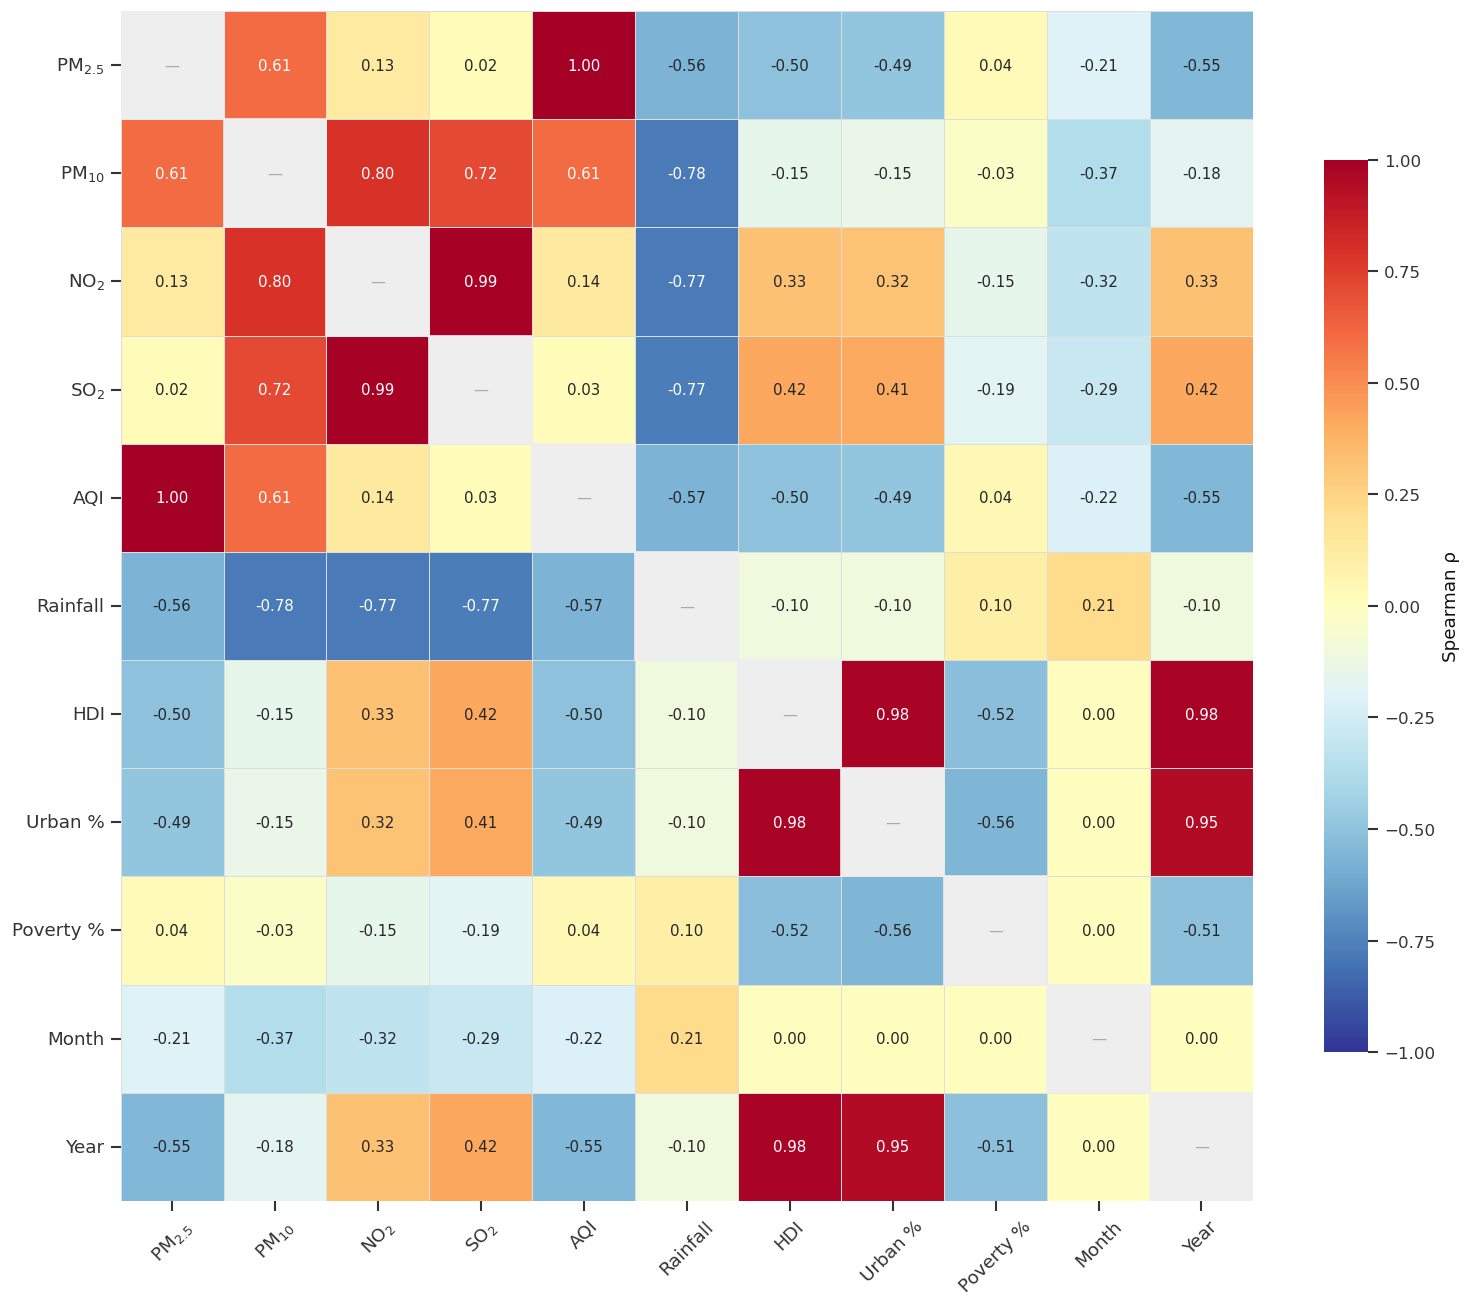

In [22]:
fig = viz.plot_correlation_matrix(df)
save_fig(fig, 'fig16_correlation_matrix')
plt.show()


### 6.2 Pairwise scatter plots (Figure 14)
Points are coloured by meteorological season. OLS regression line and
both Pearson r and Spearman ρ are reported per panel.


Saved → figures/fig17_pairwise_scatter.png


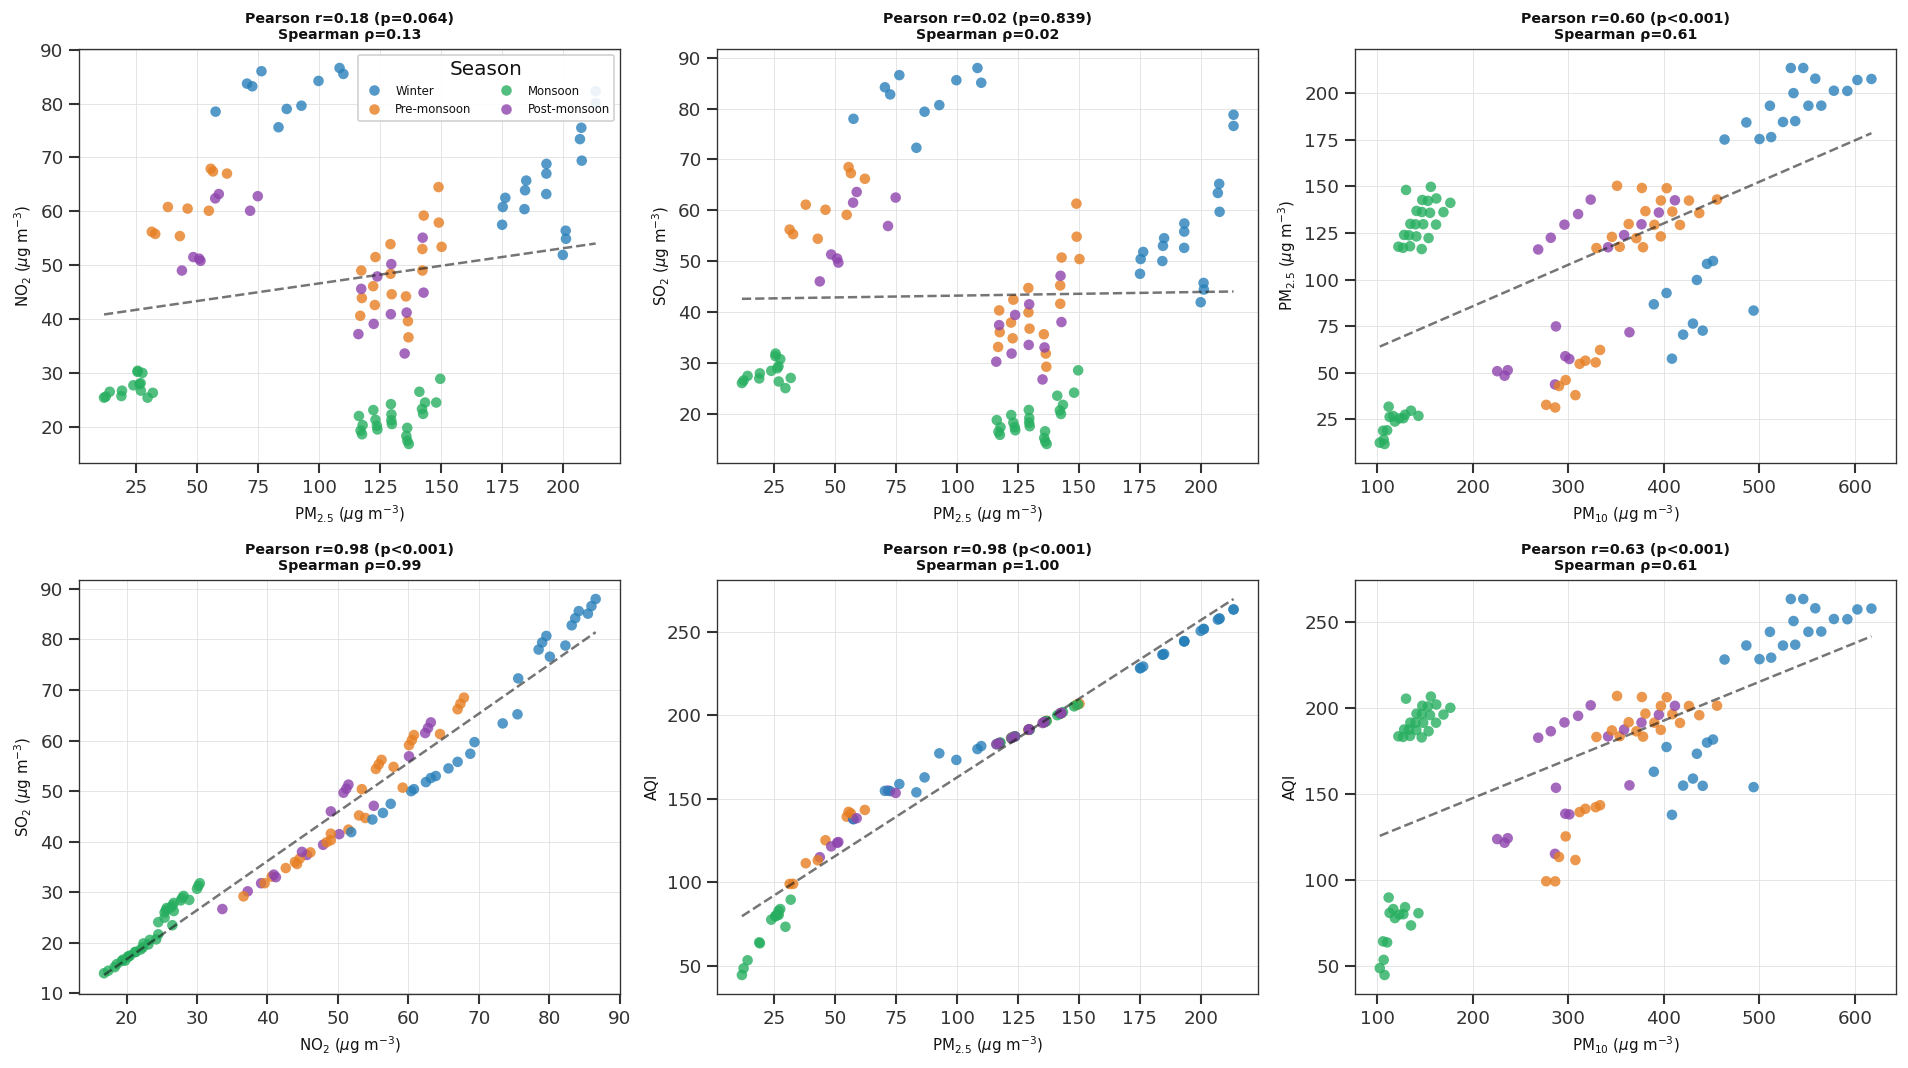

In [23]:
fig = viz.plot_pairwise_scatter(df)
save_fig(fig, 'fig17_pairwise_scatter')
plt.show()


### 6.3 Relative source contributions (Figure 15)
Stacked-area chart of each pollutant's percentage share of the total measured
pollutant load. Shifts in the stack reveal changes in source dominance over time.


Saved → figures/fig18_source_apportionment.png


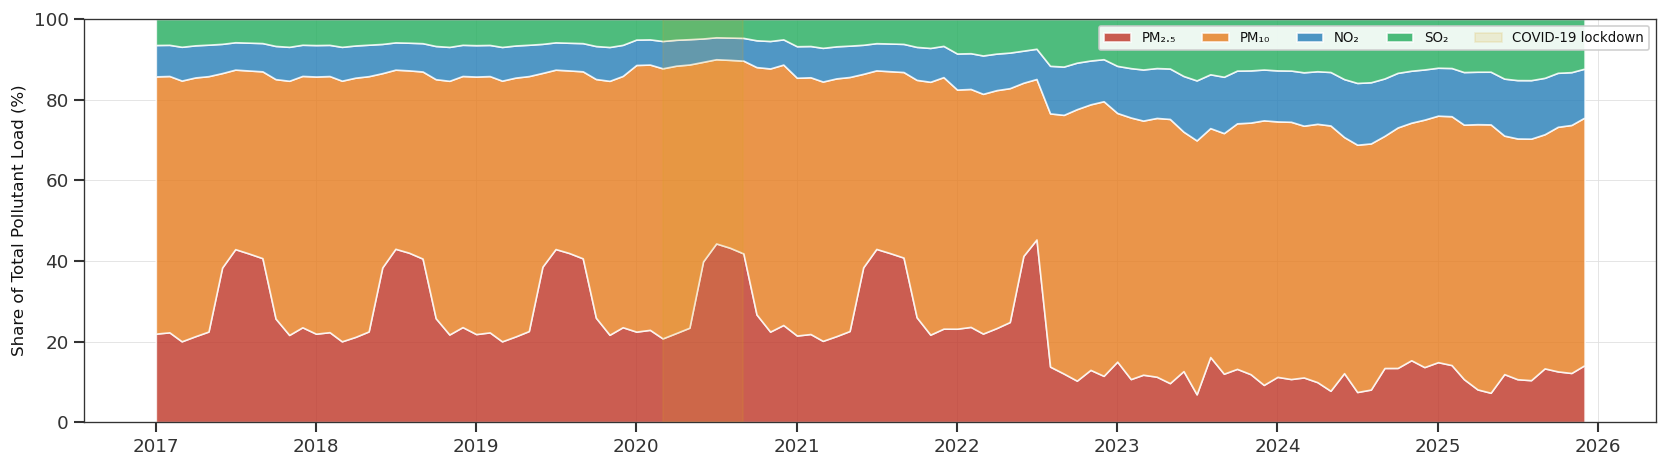

In [24]:
fig = viz.plot_source_apportionment(df)
save_fig(fig, 'fig18_source_apportionment')
plt.show()


---
## § 7 — Statistical Testing — Seasonal Differences

### 7.1 Kruskal-Wallis H-test
Tests whether the four seasons have identical pollutant distributions.  
H₀: The medians of the four seasonal groups are equal.  
Rejection (p < 0.05) warrants pairwise post-hoc comparisons.


In [25]:
from IPython.display import display, Latex

_kw_rows_data = []
for col, label in zip(POL_COLS, POL_NAMES):
    groups = [df[df['season'] == s][col].dropna().values for s in SEASON_ORDER]
    H, p = kruskal(*groups)
    sig = r'***' if p < 0.001 else r'**' if p < 0.01 else r'*' if p < 0.05 else 'ns'
    _kw_rows_data.append((label, H, p, sig))

_idx_map = {
    'PM\u2082.\u2085 (\u00b5g/m\u00b3)': r'$\mathrm{PM}_{2.5}$',
    'PM\u2081\u2080 (\u00b5g/m\u00b3)':  r'$\mathrm{PM}_{10}$',
    'NO\u2082 (\u00b5g/m\u00b3)':        r'$\mathrm{NO}_2$',
    'SO\u2082 (\u00b5g/m\u00b3)':        r'$\mathrm{SO}_2$',
    'AQI':                                'AQI',
}
_rows = '\n'.join(
    f'  {_idx_map.get(label, label)} & {H:.2f} & {p:.6f} & {sig}' + r' \\'
    for label, H, p, sig in _kw_rows_data
)

display(HTML(_pub_table(
    r'\textbf{Table.}\ Kruskal--Wallis $H$-test for seasonal differences'
    r' ($H_0$: equal medians across seasons).\\[4pt]' '\n'
    r'\begin{tabular}{lrrr}' '\n'
    r'\hline\hline' '\n'
    r'\textbf{Variable} & $H$ & $p$ & \textbf{Sig.} \\' '\n'
    r'\hline' '\n'
    + _rows + '\n'
    r'\hline\hline' '\n'
    r'\end{tabular}' '\n\n'
    r'$^{***}p<0.001$,\ $^{**}p<0.01$,\ $^{*}p<0.05$,\ ns: not significant.'
)))

Variable,H,p,Sig.
PM2.5,18.47,0.000353,***
PM10,92.87,0.000000,***
NO2,87.36,0.000000,***
SO2,78.77,0.000000,***
AQI,18.51,0.000345,***


### 7.2 Dunn's post-hoc tests (Bonferroni-corrected)
Pairwise comparisons between the four seasons using Dunn's test with
Bonferroni correction. Reported for PM₂.₅ and AQI (the primary study variables).


In [26]:
from IPython.display import display, Latex

_var_labels = [('pm25_mean', r'$\mathrm{PM}_{2.5}$'), ('aqi_mean', 'AQI')]

for col, label in _var_labels:
    data = [df[df['season'] == s][col].values for s in SEASON_ORDER]
    dunn = posthoc_dunn(data, p_adjust='bonferroni')
    dunn.index = SEASON_ORDER; dunn.columns = SEASON_ORDER

    _header = (
        r' & ' + ' & '.join(r'\textbf{' + s + '}' for s in SEASON_ORDER) + r' \\'
        + '\n' + r'\hline'
    )
    _rows = '\n'.join(
        r'  \textbf{' + season + '} & '
        + ' & '.join(f'{dunn.loc[season, s]:.4f}' for s in SEASON_ORDER)
        + r' \\'
        for season in SEASON_ORDER
    )
    display(HTML(_pub_table(
        r'\textbf{Table.}\ Dunn post-hoc test (Bonferroni-corrected $p$-values): '
        + label + r'.\\[4pt]' + '\n'
        r'\begin{tabular}{lrrrr}' '\n'
        r'\hline\hline' '\n'
        + _header + '\n'
        + _rows + '\n'
        r'\hline\hline' '\n'
        r'\end{tabular}'
    )))

,Winter,Pre-monsoon,Monsoon,Post-monsoon
Winter,1.0000,0.0300,0.0003,0.0116
Pre-monsoon,0.0300,1.0000,1.0000,1.0000
Monsoon,0.0003,1.0000,1.0000,1.0000
Post-monsoon,0.0116,1.0000,1.0000,1.0000


,Winter,Pre-monsoon,Monsoon,Post-monsoon
Winter,1.0000,0.0397,0.0003,0.0121
Pre-monsoon,0.0397,1.0000,1.0000,1.0000
Monsoon,0.0003,1.0000,1.0000,1.0000
Post-monsoon,0.0121,1.0000,1.0000,1.0000


---
## § 8 — COVID-19 Impact Assessment

Bangladesh declared a nation-wide lockdown on **26 March 2020**, with
significant restrictions continuing through **August 2020**.
Three periods are compared:
1. **Pre-COVID**: January 2017 – February 2020
2. **Lockdown**: March – August 2020
3. **Post-COVID**: September 2020 – September 2025

### 8.1 Effect size analysis (Cohen's d)
Cohen's d measures the standardised difference between pre-COVID and lockdown means.
Mann-Whitney U tests provide the non-parametric significance.


In [27]:
from src.analysis import covid_effect_table
from IPython.display import display, Latex

pre, lock, post = covid_periods(df)

_idx_map = {
    'PM\u2082.\u2085 (\u00b5g/m\u00b3)': r'$\mathrm{PM}_{2.5}$',
    'PM\u2081\u2080 (\u00b5g/m\u00b3)':  r'$\mathrm{PM}_{10}$',
    'NO\u2082 (\u00b5g/m\u00b3)':        r'$\mathrm{NO}_2$',
    'SO\u2082 (\u00b5g/m\u00b3)':        r'$\mathrm{SO}_2$',
    'AQI':                                'AQI',
}

effect_table = covid_effect_table(pre, lock)

_pre_key  = 'Pre-COVID μ'
_lock_key = 'Lockdown μ'
_d_key    = 'Δ%'
_cd_key   = "Cohen's d"
_mwu_key  = 'MWU p'
_rows = '\n'.join(
    '  ' + _idx_map.get(str(var), str(var))
    + f' & {r[_pre_key]:.1f} & {r[_lock_key]:.1f}'
    + f' & {r[_d_key]:.1f} & {r[_cd_key]:.3f} & {r.Magnitude} & {r[_mwu_key]:.4f}' + r' \\'
    for var, r in effect_table.iterrows()
)

display(HTML(_pub_table(
    r'\textbf{Table.}\ COVID-19 lockdown impact: pre-lockdown vs.\ lockdown period'
    r' (March--August 2020).\\[4pt]' '\n'
    r'\begin{tabular}{lrrrrrr}' '\n'
    r'\hline\hline' '\n'
    r'\textbf{Variable} & $\bar{x}_\mathrm{pre}$ & $\bar{x}_\mathrm{lock}$'
    r' & $\Delta\%$ & $d$ & \textbf{Effect} & $p_\mathrm{MWU}$ \\' '\n'
    r'\hline' '\n'
    + _rows + '\n'
    r'\hline\hline' '\n'
    r'\end{tabular}' '\n\n'
    r"\textit{Note:} $d$ = Cohen's $d$; $|d|<0.5$ = Small, $0.5$--$0.8$ = Medium, $>0.8$ = Large."
)))
print(f'Pre-COVID: {len(pre)} months | Lockdown: {len(lock)} months | Post-COVID: {len(post)} months')

Variable,xpre,xlock,Δ%,d,Effect,pMWU
PM2.5,141.8,136.3,-3.9,0.258,Small,0.1055
PM10,335.8,280.6,-16.4,0.367,Small,0.8026
NO2,42.5,29.1,-31.6,0.913,Large,0.0200
SO2,35.2,23.6,-33.0,0.983,Large,0.0183
AQI,202.1,196.2,-3.0,0.345,Small,0.1043


Pre-COVID: 38 months | Lockdown: 6 months | Post-COVID: 64 months


### 8.2 Period means and COVID impact figures (Figure 16)


Saved → figures/fig19_covid_impact.png


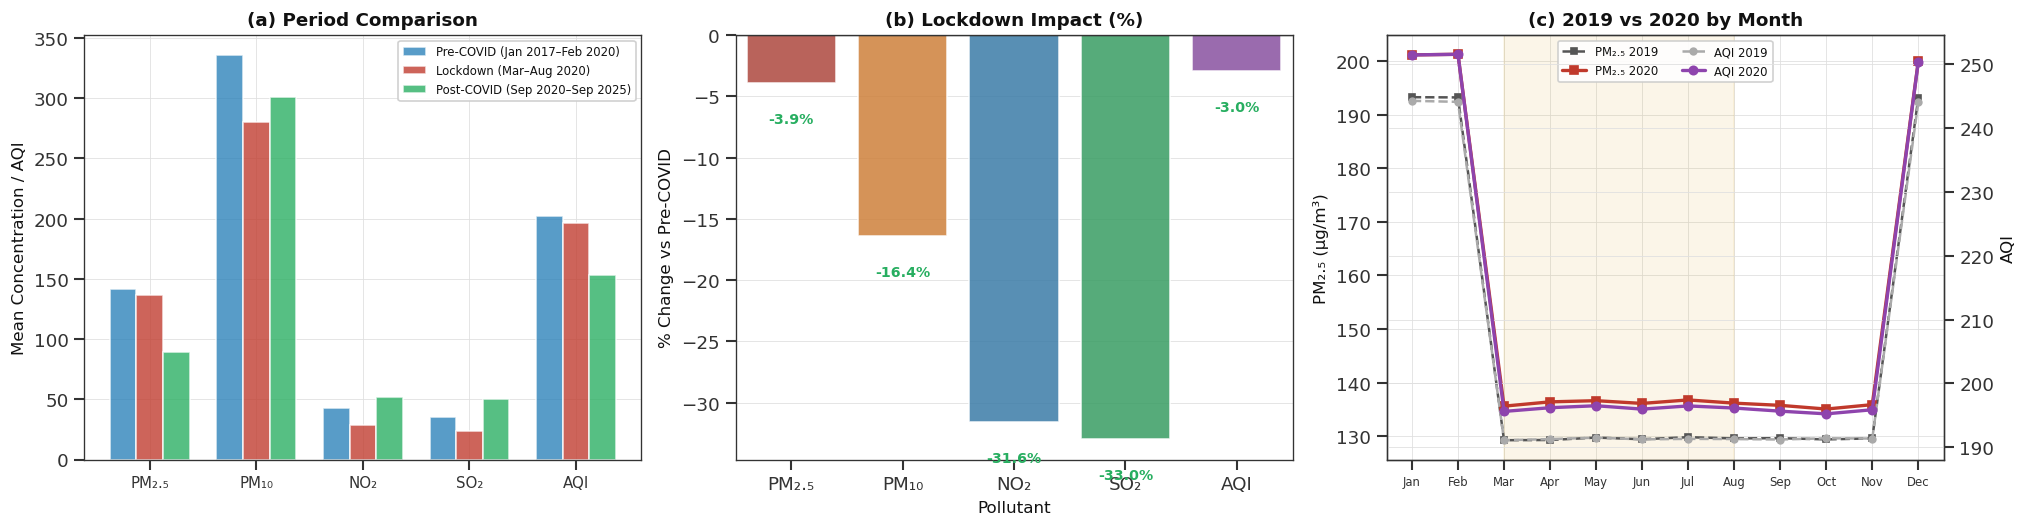

In [28]:
fig = viz.plot_covid_impact(df, pre, lock, post)
save_fig(fig, 'fig19_covid_impact')
plt.show()


---
## § 9 — Meteorological Drivers

Normalised monthly rainfall data are available for 2017–2021.
The monsoon washout hypothesis predicts a strong negative correlation
between rainfall and PM concentrations.

### 9.1 Rainfall vs pollutant scatter plots (Figure 17)


Saved → figures/fig20_rainfall_scatter.png


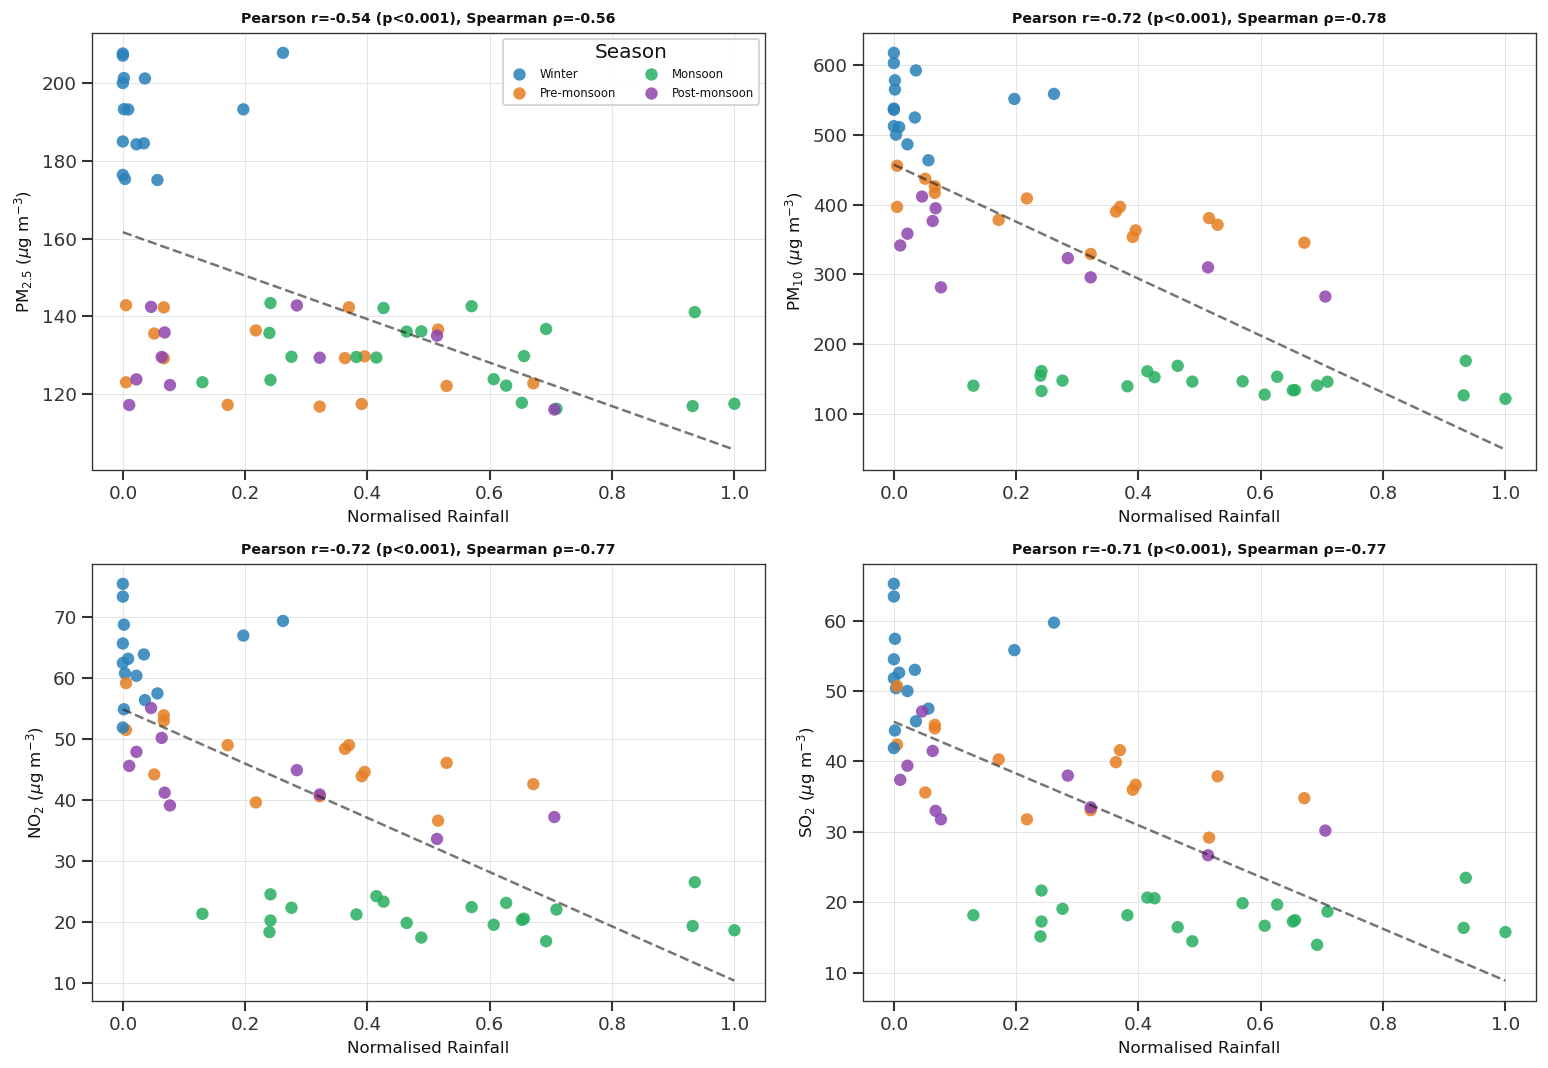

In [29]:
fig = viz.plot_rainfall_scatter(df)
save_fig(fig, 'fig20_rainfall_scatter')
plt.show()


### 9.2 Rainfall — PM₂.₅/AQI dual-axis time series (Figure 18)


Saved → figures/fig21_rainfall_dual_axis.png


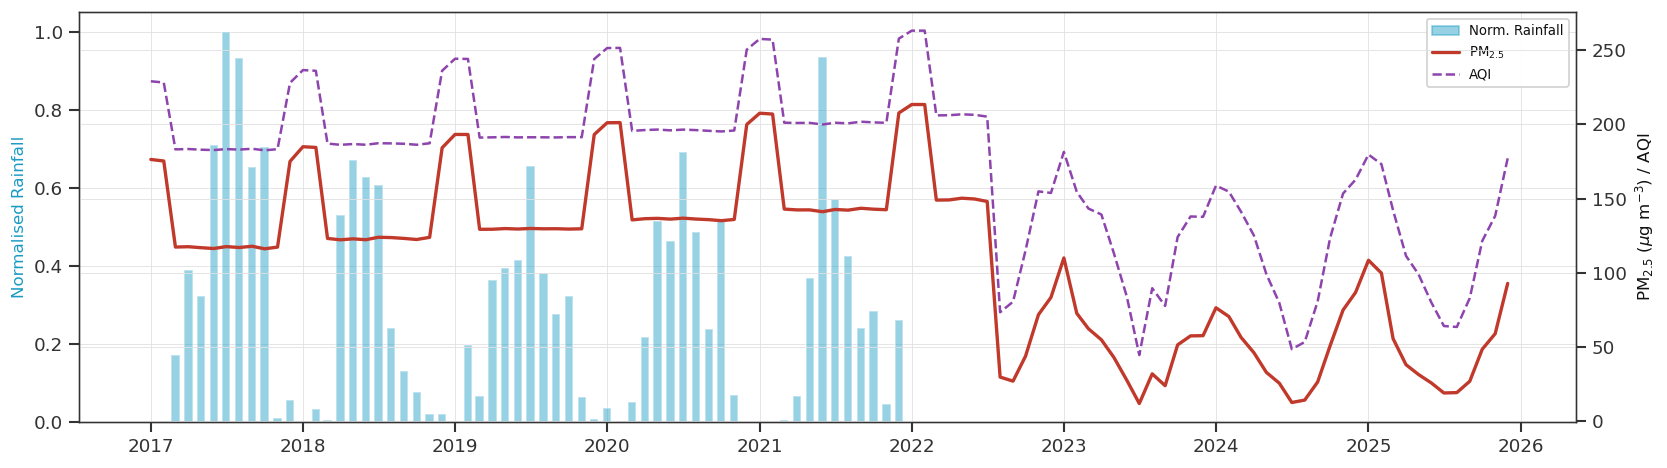

In [30]:
fig = viz.plot_rainfall_dual_axis(df)
save_fig(fig, 'fig21_rainfall_dual_axis')
plt.show()


### 9.3 Rolling correlation: rainfall vs PM₂.₅
A 12-month centred rolling Pearson correlation quantifies how the
rainfall–PM₂.₅ relationship evolves over time.


Saved → figures/fig22_rolling_correlation.png


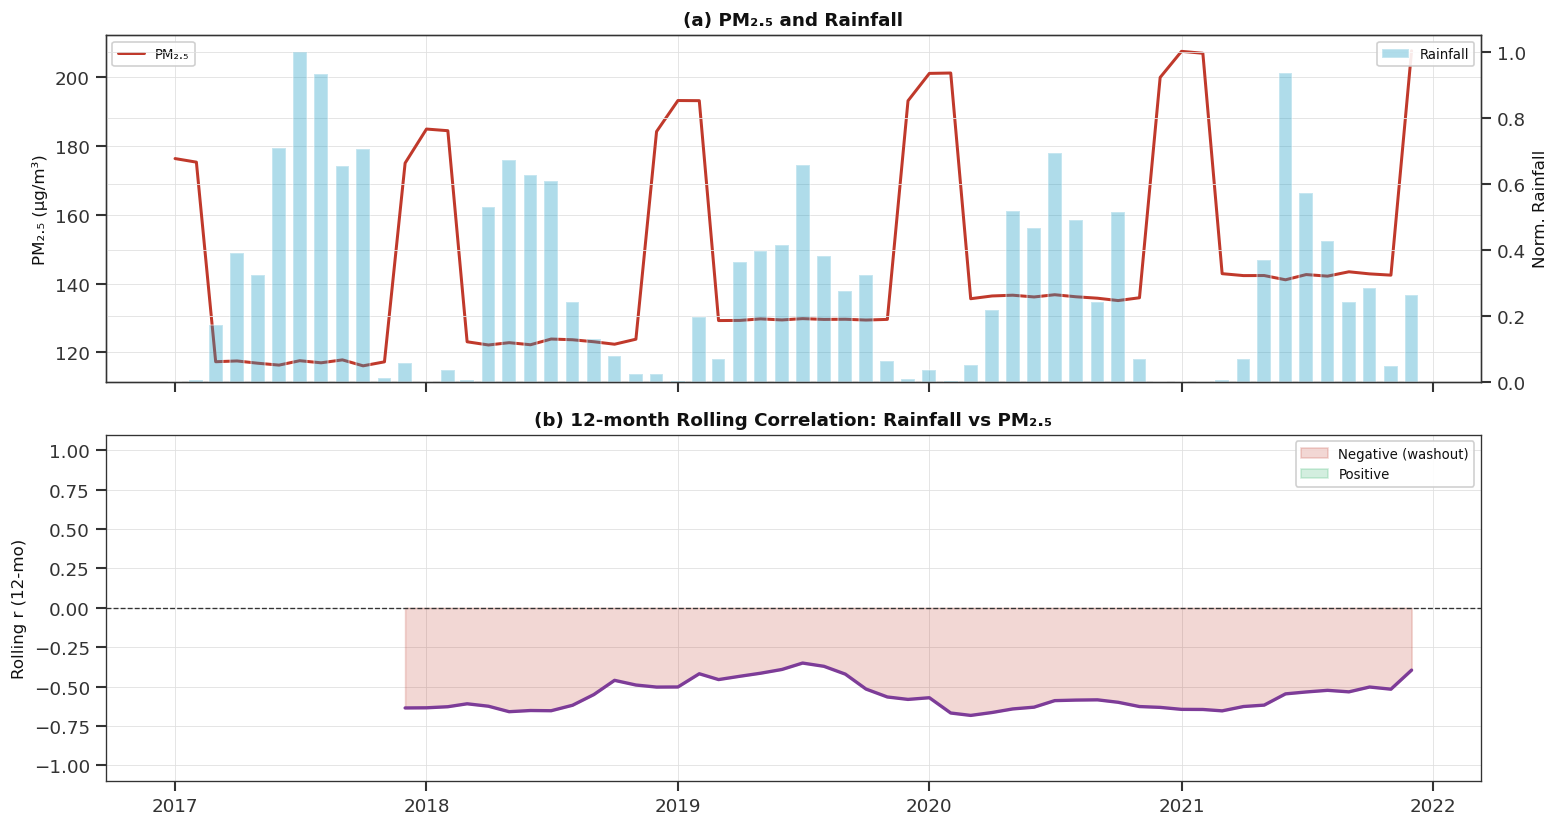

In [31]:
rain_full = df.dropna(subset=['norm_rain']).copy().sort_values('month_start').reset_index(drop=True)
roll_corr = rain_full['norm_rain'].rolling(12).corr(rain_full['pm25_mean'])

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(rain_full['month_start'], rain_full['pm25_mean'], color=PAL['pm25'], lw=1.8, label='PM\u2082.\u2085')
ax1b = axes[0].twinx()
ax1b.bar(rain_full['month_start'], rain_full['norm_rain'], color=PAL['rain'], alpha=0.35, width=20, label='Rainfall')
axes[0].set_ylabel('PM\u2082.\u2085 (\u00b5g/m\u00b3)'); ax1b.set_ylabel('Norm. Rainfall')
axes[0].set_title('(a) PM\u2082.\u2085 and Rainfall')
axes[0].legend(fontsize=8, loc='upper left'); ax1b.legend(fontsize=8, loc='upper right')

axes[1].plot(rain_full['month_start'], roll_corr, color='#7D3C98', lw=2)
axes[1].axhline(0, color='#333', lw=0.8, ls='--')
axes[1].fill_between(rain_full['month_start'], roll_corr, 0,
                     where=(roll_corr < 0), alpha=0.2, color='#C0392B', label='Negative (washout)')
axes[1].fill_between(rain_full['month_start'], roll_corr, 0,
                     where=(roll_corr >= 0), alpha=0.2, color='#27AE60', label='Positive')
axes[1].set_ylabel('Rolling r (12-mo)'); axes[1].set_ylim(-1.1, 1.1)
axes[1].set_title('(b) 12-month Rolling Correlation: Rainfall vs PM\u2082.\u2085')
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
save_fig(fig, 'fig22_rolling_correlation')
plt.show()


---
## § 10 — Socioeconomic Context & EKC Analysis

### 10.1 AQI vs socioeconomic indicators (Figure 20)
Annual mean AQI is plotted against HDI, urban population share,
and poverty rate. Colour encodes year (viridis colourmap).


Saved → figures/fig23_socioeconomic.png


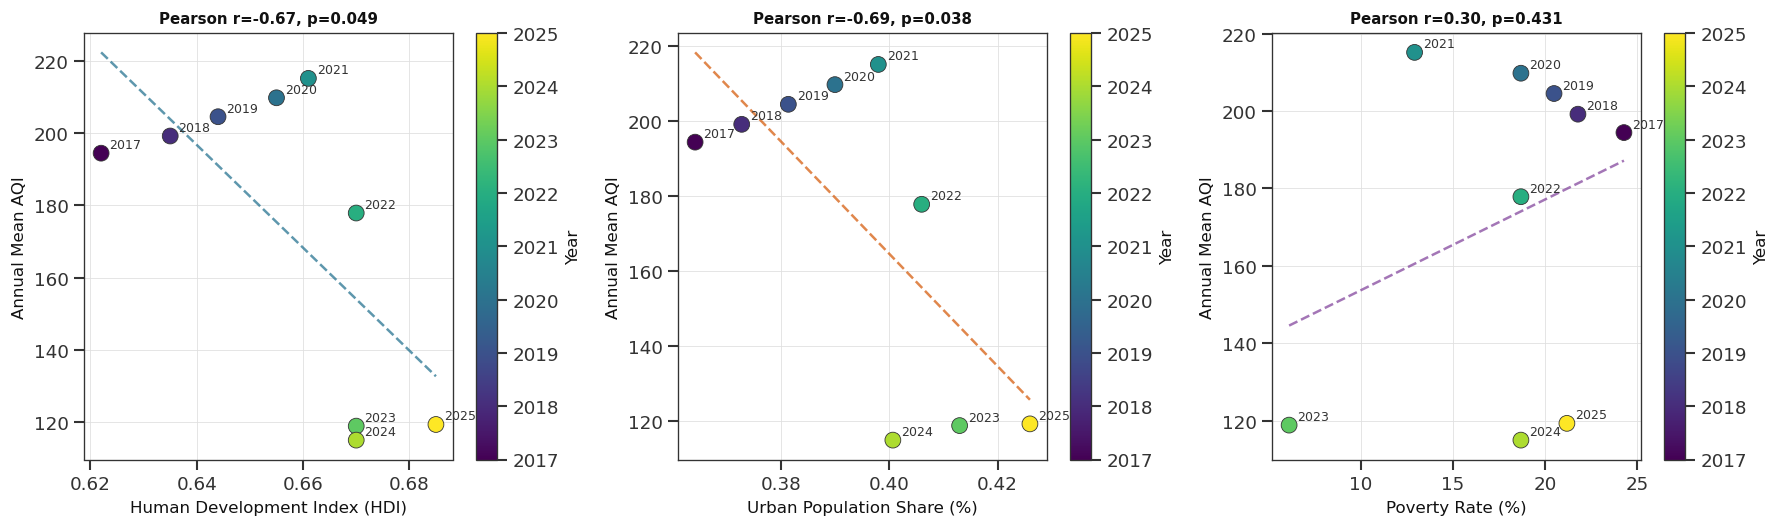

In [32]:
fig = viz.plot_socioeconomic(annual)
save_fig(fig, 'fig23_socioeconomic')
plt.show()


### 10.2 Environmental Kuznets Curve formal test
The EKC posits an inverted-U relationship between income/development and
pollution (pollution first rises with development, then falls after a turning
point). We test this via:  
**AQI = β₀ + β₁·HDI + β₂·HDI²**  
Confirmation requires β₂ < 0 and p(β₂) < 0.05.


In [33]:
from src.analysis import ekc_analysis
from IPython.display import display, Latex

ekc = ekc_analysis(annual)
lin  = ekc['linear_model']
quad = ekc['quad_model']

_sgn = lambda x: ' + ' if x >= 0 else ' - '
_lin_eq  = ('$\\mathrm{AQI} = ' + f'{lin.params[0]:.1f}'
            + _sgn(lin.params[1]) + f'{abs(lin.params[1]):.1f}' + '\\cdot\\mathrm{HDI}$, '
            + f'$R^2 = {lin.rsquared:.3f}$, $p(\\mathrm{{HDI}}) = {lin.pvalues[1]:.4f}$')
_quad_eq = ('$\\mathrm{AQI} = ' + f'{quad.params[0]:.1f}'
            + _sgn(quad.params[1]) + f'{abs(quad.params[1]):.1f}' + '\\cdot\\mathrm{HDI}'
            + _sgn(quad.params[2]) + f'{abs(quad.params[2]):.1f}' + '\\cdot\\mathrm{HDI}^2$, '
            + f'$R^2 = {quad.rsquared:.3f}$, '
            + f'$p(\\mathrm{{HDI}}) = {quad.pvalues[1]:.4f}$, '
            + f'$p(\\mathrm{{HDI}}^2) = {quad.pvalues[2]:.4f}$')
_tp = (f', turning point $\\mathrm{{HDI}} \\approx {ekc["turning_point"]:.3f}$'
       if ekc['turning_point'] else '')

display(HTML(_pub_table(
    r'\textbf{Table.}\ Environmental Kuznets Curve (EKC) regression results.\\[4pt]' '\n'
    r'\begin{tabular}{ll}' '\n'
    r'\hline\hline' '\n'
    r'\textbf{Model} & \textbf{Equation \& fit} \\' '\n'
    r'\hline' '\n'
    r'  Linear & ' + _lin_eq + r' \\' '\n'
    r'  Quadratic & ' + _quad_eq + r' \\' '\n'
    r'\hline\hline' '\n'
    r'\end{tabular}' '\n\n'
    r'\textit{Verdict:} ' + ekc['verdict'].replace('β₂', r'$\beta_2$').replace('β₁', r'$\beta_1$').replace('β', r'$\beta$') + _tp
)))

Model,Equation & fit
Linear,"AQI = 1107.2 - 1422.7·HDI, R2 = 0.447, p(HDI) = 0.0491"
Quadratic,"AQI = -18919.9 + 59988.2·HDI - 47036.3·HDI2, R2 = 0.616, p(HDI) = 0.1625, p(HDI2) = 0.1543"


### 10.3 Population-normalised burden (Figure 21)


Saved → figures/fig24_per_capita.png


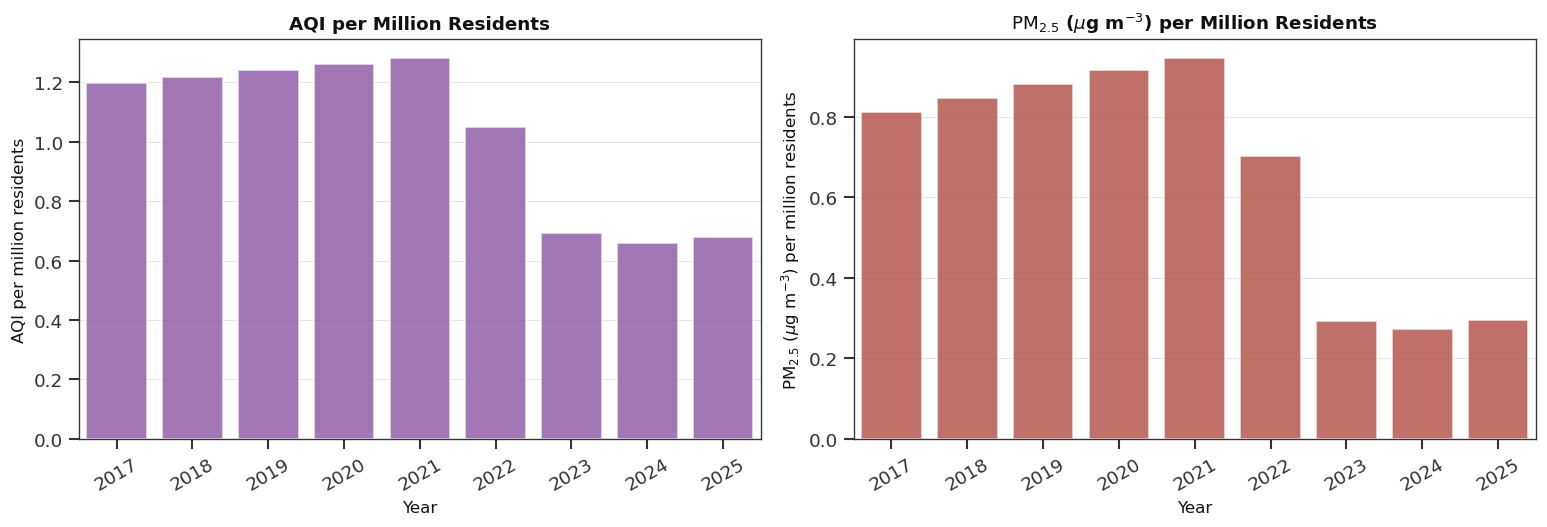

In [34]:
fig = viz.plot_per_capita(annual)
save_fig(fig, 'fig24_per_capita')
plt.show()


---
## § 11 — WHO & EPA Guideline Exceedance

WHO 2021 annual guidelines: PM₂.₅ = 5, PM₁₀ = 15, NO₂ = 10, SO₂ = 40 µg/m³.  
US EPA 24-h standards: PM₂.₅ = 35, PM₁₀ = 150, NO₂ = 100, SO₂ = 75 µg/m³.


In [35]:
from src.analysis import exceedance_summary
from IPython.display import display, Latex

exc_df = exceedance_summary(df)

_idx_map = {
    'PM2.5': r'$\mathrm{PM}_{2.5}$', 'PM\u2082.\u2085': r'$\mathrm{PM}_{2.5}$',
    'PM10':  r'$\mathrm{PM}_{10}$',  'PM\u2081\u2080':  r'$\mathrm{PM}_{10}$',
    'NO2':   r'$\mathrm{NO}_2$',     'NO\u2082':        r'$\mathrm{NO}_2$',
    'SO2':   r'$\mathrm{SO}_2$',     'SO\u2082':        r'$\mathrm{SO}_2$',
}

_who_key  = 'WHO guideline (µg/m³)'
_mean_key = 'Dataset mean (µg/m³)'
_x_key    = '× WHO guideline'
_rows = '\n'.join(
    '  ' + _idx_map.get(str(pol), str(pol))
    + f' & {r[_who_key]:.0f}'
    + f' & {r[_mean_key]:.1f}'
    + f' & {r[_x_key]:.1f}'
    + f' & {r["% months > WHO"]:.1f}'
    + f' & {r["% months > EPA"]:.1f}' + r' \\'
    for pol, r in exc_df.iterrows()
)

display(HTML(_pub_table(
    r'\textbf{Table.}\ WHO 2021 and US EPA guideline exceedance summary.\\[4pt]' '\n'
    r'\begin{tabular}{lrrrrr}' '\n'
    r'\hline\hline' '\n'
    r'\textbf{Pollutant} & \textbf{WHO} & \textbf{Mean} & $\times$\textbf{WHO}'
    r' & \textbf{\% $>$ WHO} & \textbf{\% $>$ EPA} \\' '\n'
    r'& ($\mu\mathrm{g\,m}^{-3}$) & ($\mu\mathrm{g\,m}^{-3}$) & & & \\' '\n'
    r'\hline' '\n'
    + _rows + '\n'
    r'\hline\hline' '\n'
    r'\end{tabular}'
)))

Pollutant,WHO,Mean,×WHO,\textbf{% > WHO},\textbf{% > EPA}
,(µg m-3),(µg m-3),,,
PM2.5,5,110.6,22.1,100.0,85.2
PM10,15,312.1,20.8,100.0,74.1
NO2,10,47.3,4.7,100.0,0.0
SO2,40,43.3,1.1,50.9,10.2


Saved → figures/fig25_exceedance.png


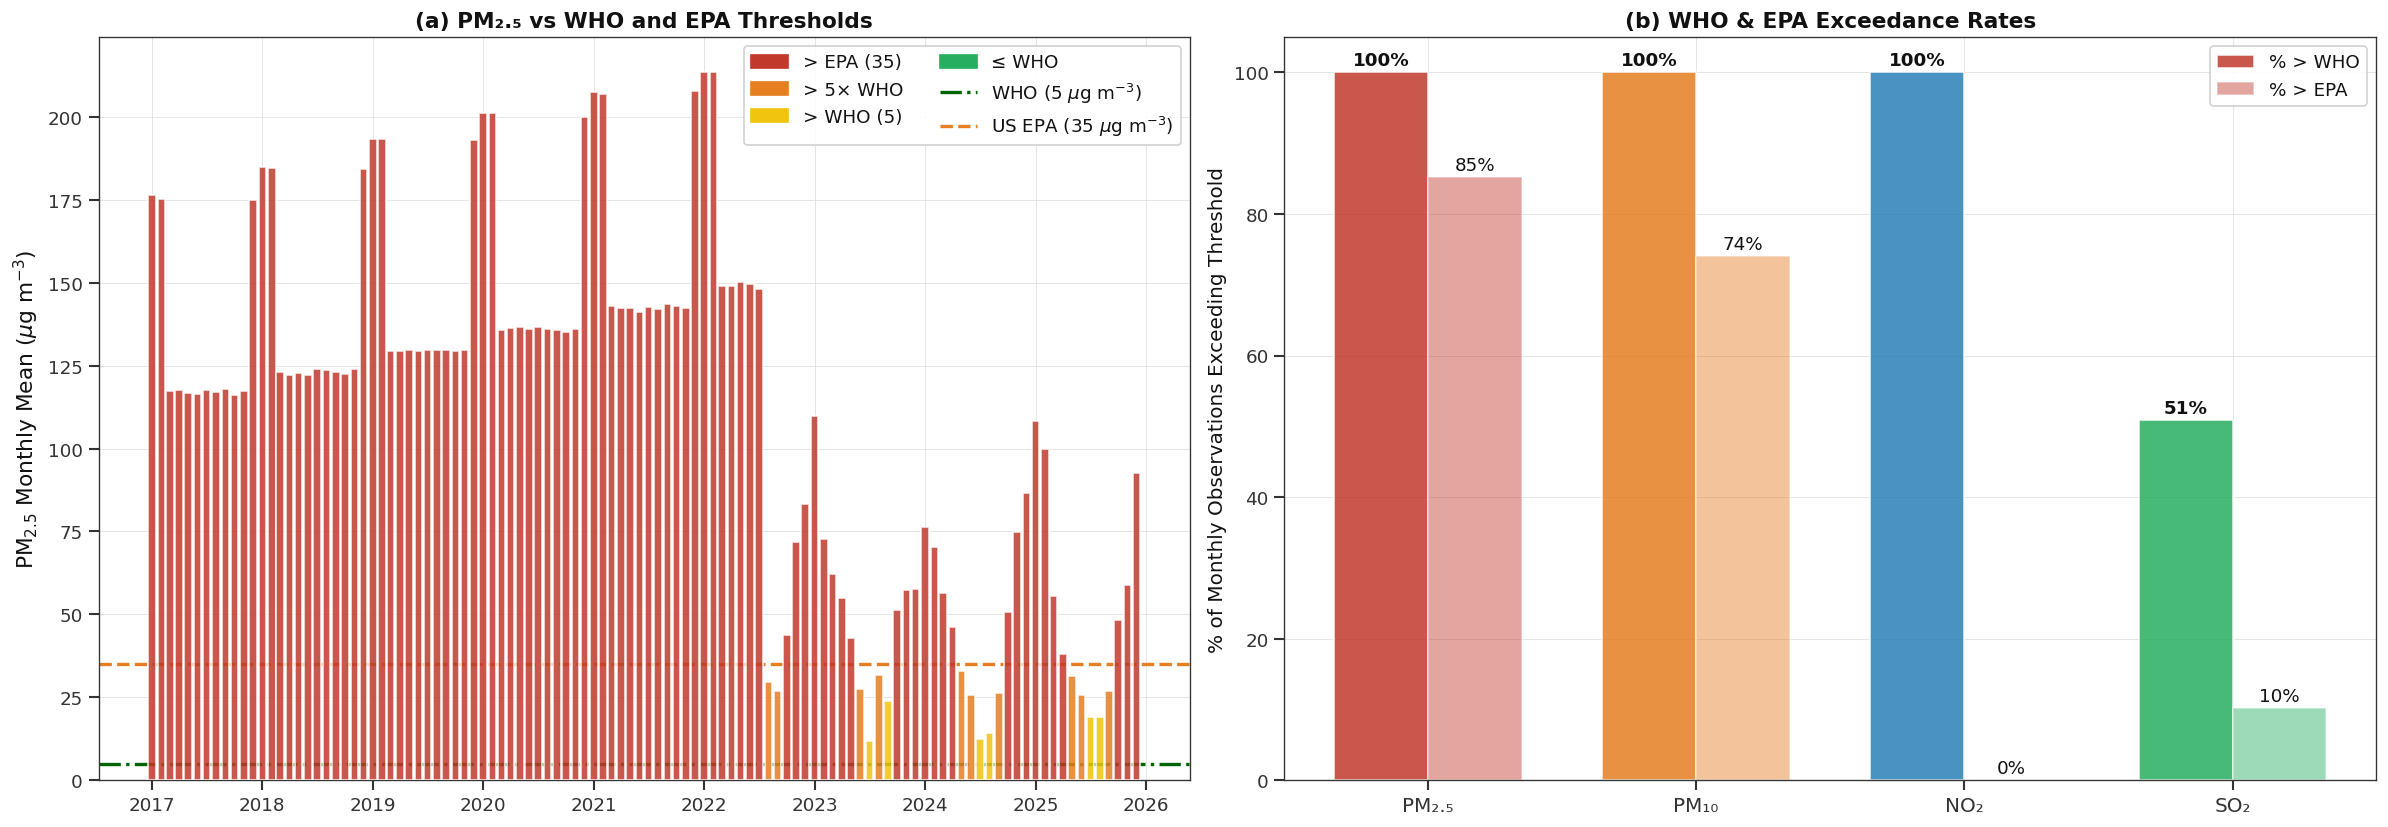

In [36]:
fig = viz.plot_exceedance(df, exc_df)
save_fig(fig, 'fig25_exceedance')
plt.show()


---
## § 12 — Health Burden Estimation

PM₂.₅-attributable mortality is estimated using the IHME GBD 2019 South Asia
concentration-response function (CRF):

**AF = 1 − exp(−β × max(C − C₀, 0))**

Where:
- β = 0.00575 (IHME GBD 2019 South Asia, all-cause mortality)
- C = annual mean PM₂.₅ (µg/m³)
- C₀ = 5 µg/m³ (WHO annual guideline, counterfactual concentration)
- Crude mortality rate (CMR) = 5.5 per 1,000 (Bangladesh, World Bank 2022)

> **Important caveat**: estimates use Bangladesh national population and CMR.
> City-level estimates require Dhaka-specific mortality and exposure data.
> These figures should be interpreted as order-of-magnitude estimates only.


In [37]:
from src.analysis import health_burden
from IPython.display import display, Latex

health_df = health_burden(annual)

_pm25_mean_key  = 'PM₂.₅ mean (µg/m³)'
_pm25_attr_key  = 'PM₂.₅-attributable deaths'
_rows = '\n'.join(
    f'  {int(yr)}'
    + f' & {r[_pm25_mean_key]:.1f}'
    + f' & {r["Excess above WHO"]:.1f}'
    + f' & {r["Attributable Fraction"]:.4f}'
    + f' & {int(r["Est. total deaths"]):,}'
    + f' & {int(r[_pm25_attr_key]):,}'
    + f' & {r["Deaths per 100k pop"]:.1f}' + r' \\'
    for yr, r in health_df.iterrows()
)

display(HTML(_pub_table(
    r'\textbf{Table.}\ Estimated $\mathrm{PM}_{2.5}$-attributable mortality,'
    r' Dhaka City (2017--2025). IHME GBD 2019 South Asia CRF; $\beta = 0.00575$.\\[4pt]' '\n'
    r'\begin{tabular}{crrrrrr}' '\n'
    r'\hline\hline' '\n'
    r'\textbf{Year} & $\overline{\mathrm{PM}_{2.5}}$ & \textbf{Excess} & \textbf{AF}'
    r' & \textbf{Total deaths} & \textbf{Attrib. deaths} & \textbf{Per 100k} \\' '\n'
    r'& ($\mu\mathrm{g\,m}^{-3}$) & ($\mu\mathrm{g\,m}^{-3}$) & & & & \\' '\n'
    r'\hline' '\n'
    + _rows + '\n'
    r'\hline\hline' '\n'
    r'\end{tabular}'
)))

Year,PM2.5,Excess,AF,Total deaths,Attrib. deaths,Per 100k
,(µg m-3),(µg m-3),,,,
2017,131.7,126.7,0.5174,"891,820","461,442",284.6
2018,138.4,133.4,0.5356,"899,426","481,771",294.6
2019,145.5,140.5,0.5541,"907,032","502,572",304.7
2020,152.2,147.2,0.5711,"914,639","522,375",314.1
2021,158.7,153.7,0.5868,"923,128","541,691",322.7
2022,119.0,114.0,0.4809,"931,616","447,974",264.5
2023,50.3,45.3,0.2294,"943,068","216,308",126.2
2024,47.8,42.8,0.2179,"960,856","209,407",119.9
2025,52.0,47.0,0.2367,"966,277","228,687",130.2


Saved → figures/fig26_health_burden.png


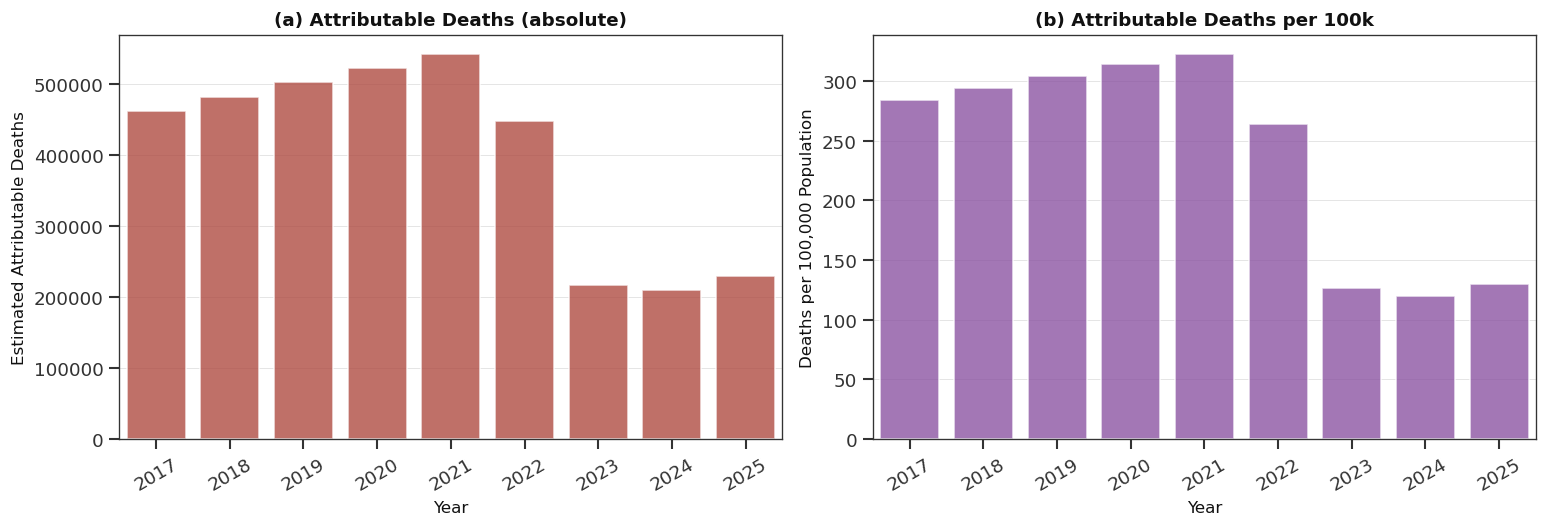

In [38]:
fig = viz.plot_health_burden(health_df)
save_fig(fig, 'fig26_health_burden')
plt.show()


---
## § 13 — Regional Comparison

Dhaka's PM₂.₅ levels are compared with major South Asian and Southeast Asian
cities using published annual mean values from IQAir and the WHO Global Air
Quality Database (2017, 2019, 2022 reference years).


Saved → figures/fig27_regional_comparison.png


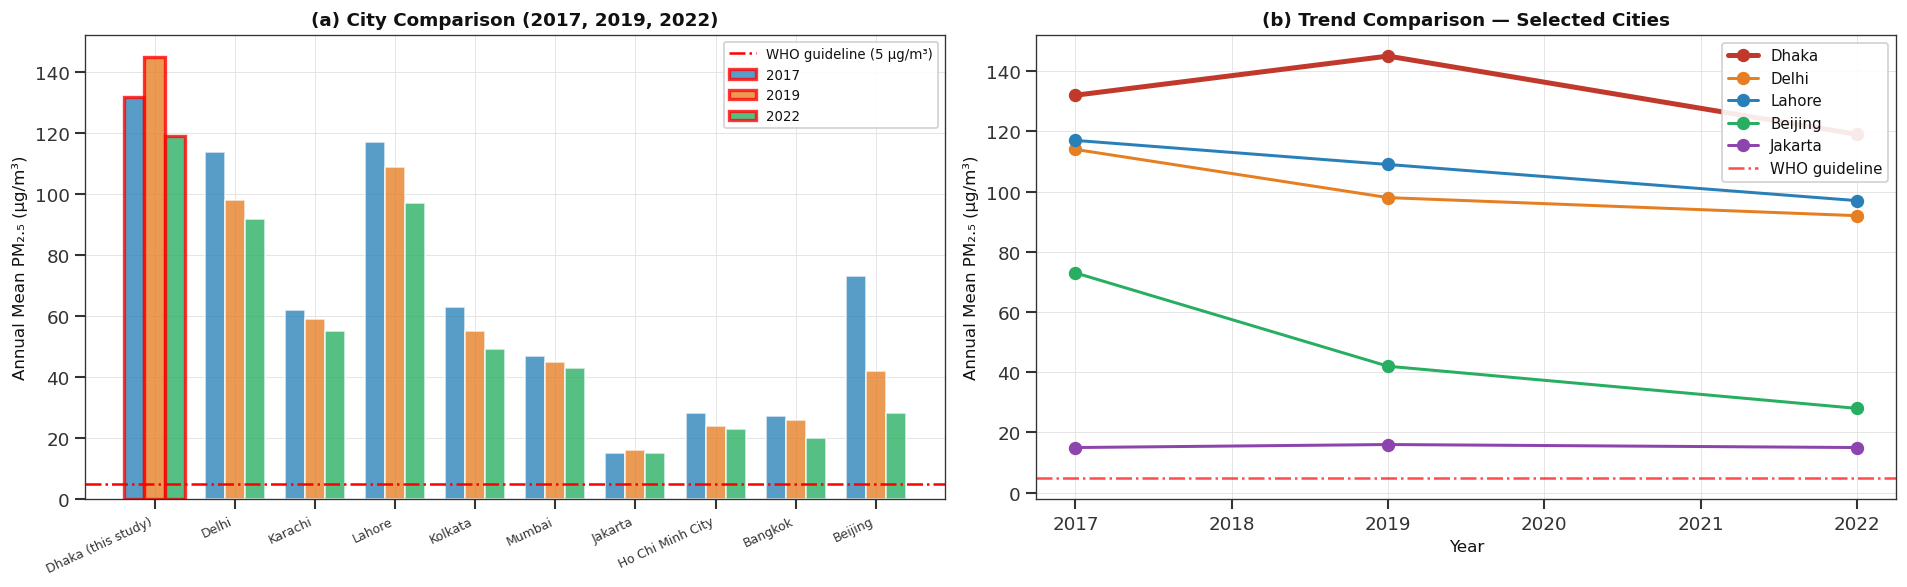

In [39]:
fig = viz.plot_regional_comparison()
save_fig(fig, 'fig27_regional_comparison')
plt.show()


---
## § 14 — Predictive Modelling — Held-out Evaluation

**Train/test split**: 2017-01 – 2023-12 (training), 2024-01 – 2025-09 (test).  
The test period is deliberately held out from model fitting to provide an
honest evaluation of out-of-sample predictive skill.

| Model | Description |
|---|---|
| **OLS** | Year + calendar-month dummy variables (linear baseline) |
| **ETS** | Holt-Winters additive Exponential Smoothing (trend + season, period=12) |
| **SARIMA** | Auto-ARIMA with AIC-based order selection (seasonal m=12) |
| **Prophet** | Facebook Prophet with multiplicative yearly seasonality |
| **Ensemble** | Simple mean of the four model forecasts |

> ⏳ The SARIMA and Prophet fitting cells may take 1–3 minutes.


In [40]:
from src.forecasting import evaluate_models

TRAIN_END  = '2023-12-01'
TEST_START = '2024-01-01'
df_train = df[df['month_start'] <= TRAIN_END].copy()
df_test  = df[df['month_start'] >= TEST_START].copy()

print(f'Training set: {len(df_train)} months '
      f'({df_train.month_start.min().date()} \u2013 {df_train.month_start.max().date()})')
print(f'Test set:     {len(df_test)} months  '
      f'({df_test.month_start.min().date()} \u2013 {df_test.month_start.max().date()})')


Training set: 84 months (2017-01-01 – 2023-12-01)
Test set:     24 months  (2024-01-01 – 2025-12-01)


In [41]:
print('Fitting models on training data and evaluating on test set...')
eval_df, model_preds = evaluate_models(df_train, df_test)

from IPython.display import display, Latex

_var_order = ['PM\u2082.\u2085', 'AQI', 'NO\u2082', 'SO\u2082']
_var_latex = [r'$\mathrm{PM}_{2.5}$', 'AQI', r'$\mathrm{NO}_2$', r'$\mathrm{SO}_2$']
_model_order = ['OLS', 'ETS', 'SARIMA', 'Prophet', 'Ensemble']

for metric in ['MAE', 'RMSE', 'MAPE%']:
    _pivot = eval_df.pivot_table(index='Model', columns='Variable', values=metric)
    _pivot = _pivot.reindex(index=_model_order)
    _pivot = _pivot[[c for c in _var_order if c in _pivot.columns]]

    def _hdr(v):
        if v.startswith('$'):
            return v  # math-mode: use as-is (bold via tabular header line already)
        return r'\textbf{' + v + '}'
    _header = (
        r'\textbf{Model} & '
        + ' & '.join(_hdr(v) for v in _var_latex[:len(_pivot.columns)])
        + r' \\'
        + '\n' + r'\hline'
    )
    _rows_m = '\n'.join(
        '  ' + model + ' & '
        + ' & '.join(f'{_pivot.loc[model, c]:.2f}' if c in _pivot.columns else '--'
                     for c in _var_order if c in _pivot.columns)
        + r' \\'
        for model in _model_order if model in _pivot.index
    )
    _unit = r' (\%)' if metric == 'MAPE%' else r' ($\mu\mathrm{g\,m}^{-3}$)' if metric != 'MAPE%' else ''
    display(HTML(_pub_table(
        r'\textbf{Table.}\ Model evaluation --- ' + metric + _unit
        + r' (held-out test period 2024--2025). Lower = better.\\[4pt]' '\n'
        r'\begin{tabular}{lrrrr}' '\n'
        r'\hline\hline' '\n'
        + _header + '\n'
        + _rows_m + '\n'
        r'\hline\hline' '\n'
        r'\end{tabular}'
    )))

# Best model per variable
_best_rows = []
for var, vl in zip(_var_order, _var_latex):
    _sub = eval_df[eval_df['Variable'] == var].sort_values('MAPE%')
    if not _sub.empty:
        _best_rows.append(f'  {vl} & {_sub.iloc[0]["Model"]} & {_sub.iloc[0]["MAPE%"]:.1f}' + r' \\')

display(HTML(_pub_table(
    r'\textbf{Table.}\ Best model per variable (lowest MAPE\%).\\[4pt]' '\n'
    r'\begin{tabular}{lrr}' '\n'
    r'\hline\hline' '\n'
    r'\textbf{Variable} & \textbf{Best model} & \textbf{MAPE (\%)} \\' '\n'
    r'\hline' '\n'
    + '\n'.join(_best_rows) + '\n'
    r'\hline\hline' '\n'
    r'\end{tabular}'
)))

Fitting models on training data and evaluating on test set...


22:24:01 - cmdstanpy - INFO - Chain [1] start processing


22:24:01 - cmdstanpy - INFO - Chain [1] done processing


22:24:10 - cmdstanpy - INFO - Chain [1] start processing


22:24:11 - cmdstanpy - INFO - Chain [1] done processing


...

22:24:18 - cmdstanpy - INFO - Chain [1] done processing


Model,PM2.5,AQI,NO2,SO2
OLS,34.95,32.01,3.50,5.33
ETS,29.51,23.61,8.96,12.77
SARIMA,39.85,43.97,3.84,12.55
Prophet,48.52,82.22,1.72,2.75
Ensemble,22.13,33.16,3.86,6.95


Model,PM2.5,AQI,NO2,SO2
OLS,39.49,39.64,4.24,6.26
ETS,33.97,28.65,9.90,14.32
SARIMA,49.73,51.13,4.68,13.27
Prophet,55.57,93.78,2.64,3.97
Ensemble,29.19,40.61,4.60,8.01


Model,PM2.5,AQI,NO2,SO2
OLS,116.76,40.11,9.53,12.73
ETS,67.08,22.55,23.69,33.34
SARIMA,78.35,38.54,11.12,29.60
Prophet,98.15,67.83,2.85,5.03
Ensemble,42.22,28.46,10.93,18.34


Variable,Best model,MAPE (%)
PM2.5,Ensemble,42.2
AQI,ETS,22.6
NO2,Prophet,2.9
SO2,Prophet,5.0


### 14.3 Model performance heatmap (Figure C)

The three heatmaps below show MAE, RMSE, and MAPE (%) for all five models
across all four target variables. Lower values = better. The Ensemble row
is outlined in dark blue. This compact visual allows rapid identification
of which model excels for each pollutant and which metric.


Saved → figures/fig28_model_performance_heatmap.png


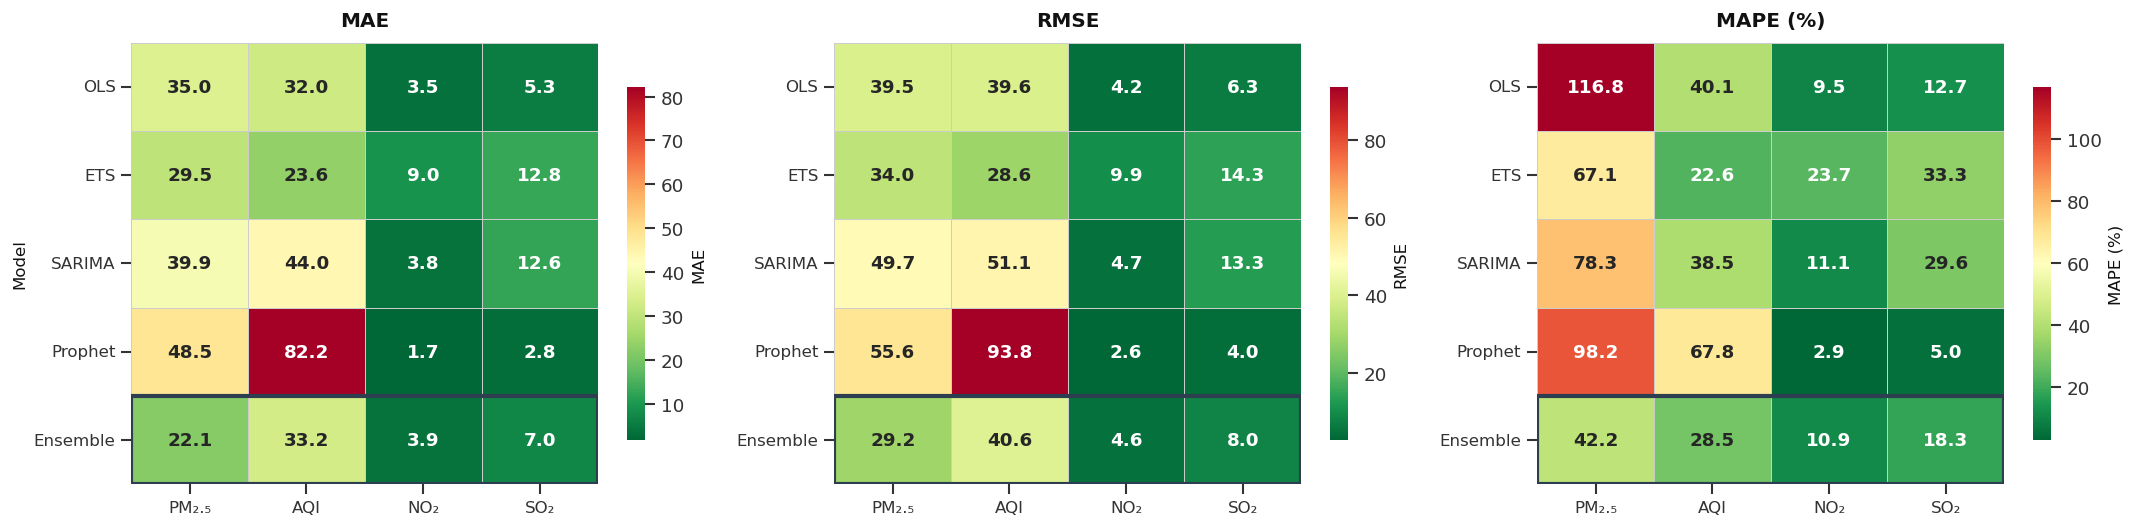

In [42]:
fig = viz.plot_model_performance_heatmap(eval_df)
save_fig(fig, 'fig28_model_performance_heatmap')
plt.show()


Saved → figures/fig29_model_evaluation.png


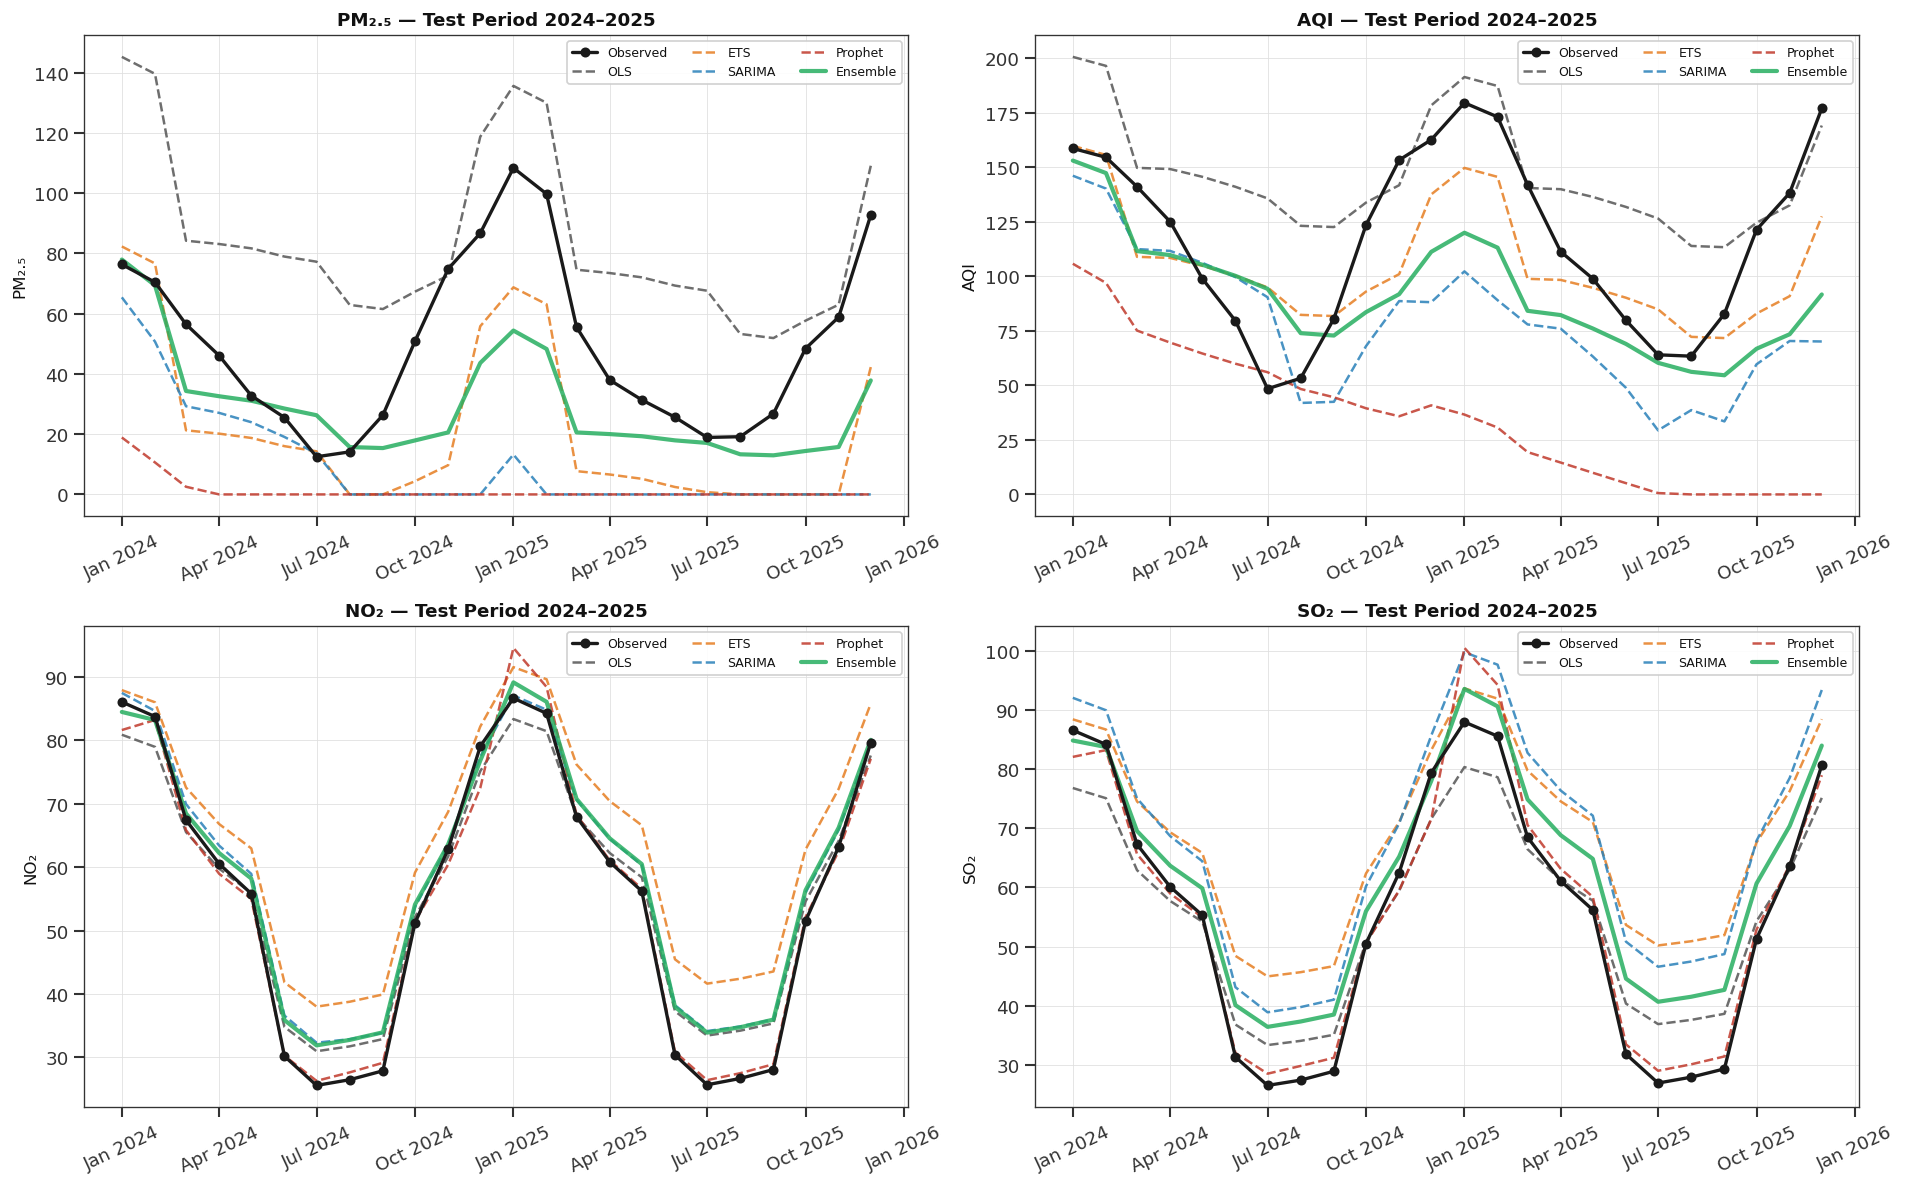

In [43]:
fig = viz.plot_model_evaluation(df_test, model_preds)
save_fig(fig, 'fig29_model_evaluation')
plt.show()


---
## § 15 — Multi-Model Forecasts to 2030

Models are re-fitted on the **complete observed dataset** (2017-2025) and
projected forward to December 2030. The ensemble mean of all four models
is the primary forecast; Prophet's 90 % prediction interval provides
uncertainty bounds.

> ⏳ This section re-fits all four models on the full dataset; allow 3–5 minutes.


In [44]:
from src.forecasting import forecast_to_2030, forecast_summary_table

future_df = build_future_dates(df, end='2030-12-01')
print(f'Forecasting {len(future_df)} months: '
      f'{future_df["month_start"].min().date()} \u2192 {future_df["month_start"].max().date()}')


Forecasting 60 months: 2026-01-01 → 2030-12-01


In [45]:
print('Fitting full-sample forecasts to 2030...')
forecasts = forecast_to_2030(df, future_df)


Fitting full-sample forecasts to 2030...


22:24:44 - cmdstanpy - INFO - Chain [1] start processing


22:24:44 - cmdstanpy - INFO - Chain [1] done processing


PM₂.₅  | OLS R²=0.636 | Ensemble Dec 2030 = 44.3


22:25:15 - cmdstanpy - INFO - Chain [1] start processing


...

22:25:28 - cmdstanpy - INFO - Chain [1] done processing


NO₂    | OLS R²=0.953 | Ensemble Dec 2030 = 89.1


22:25:35 - cmdstanpy - INFO - Chain [1] start processing


22:25:35 - cmdstanpy - INFO - Chain [1] done processing


SO₂    | OLS R²=0.916 | Ensemble Dec 2030 = 95.2


Saved → figures/fig30_forecasts_2030.png


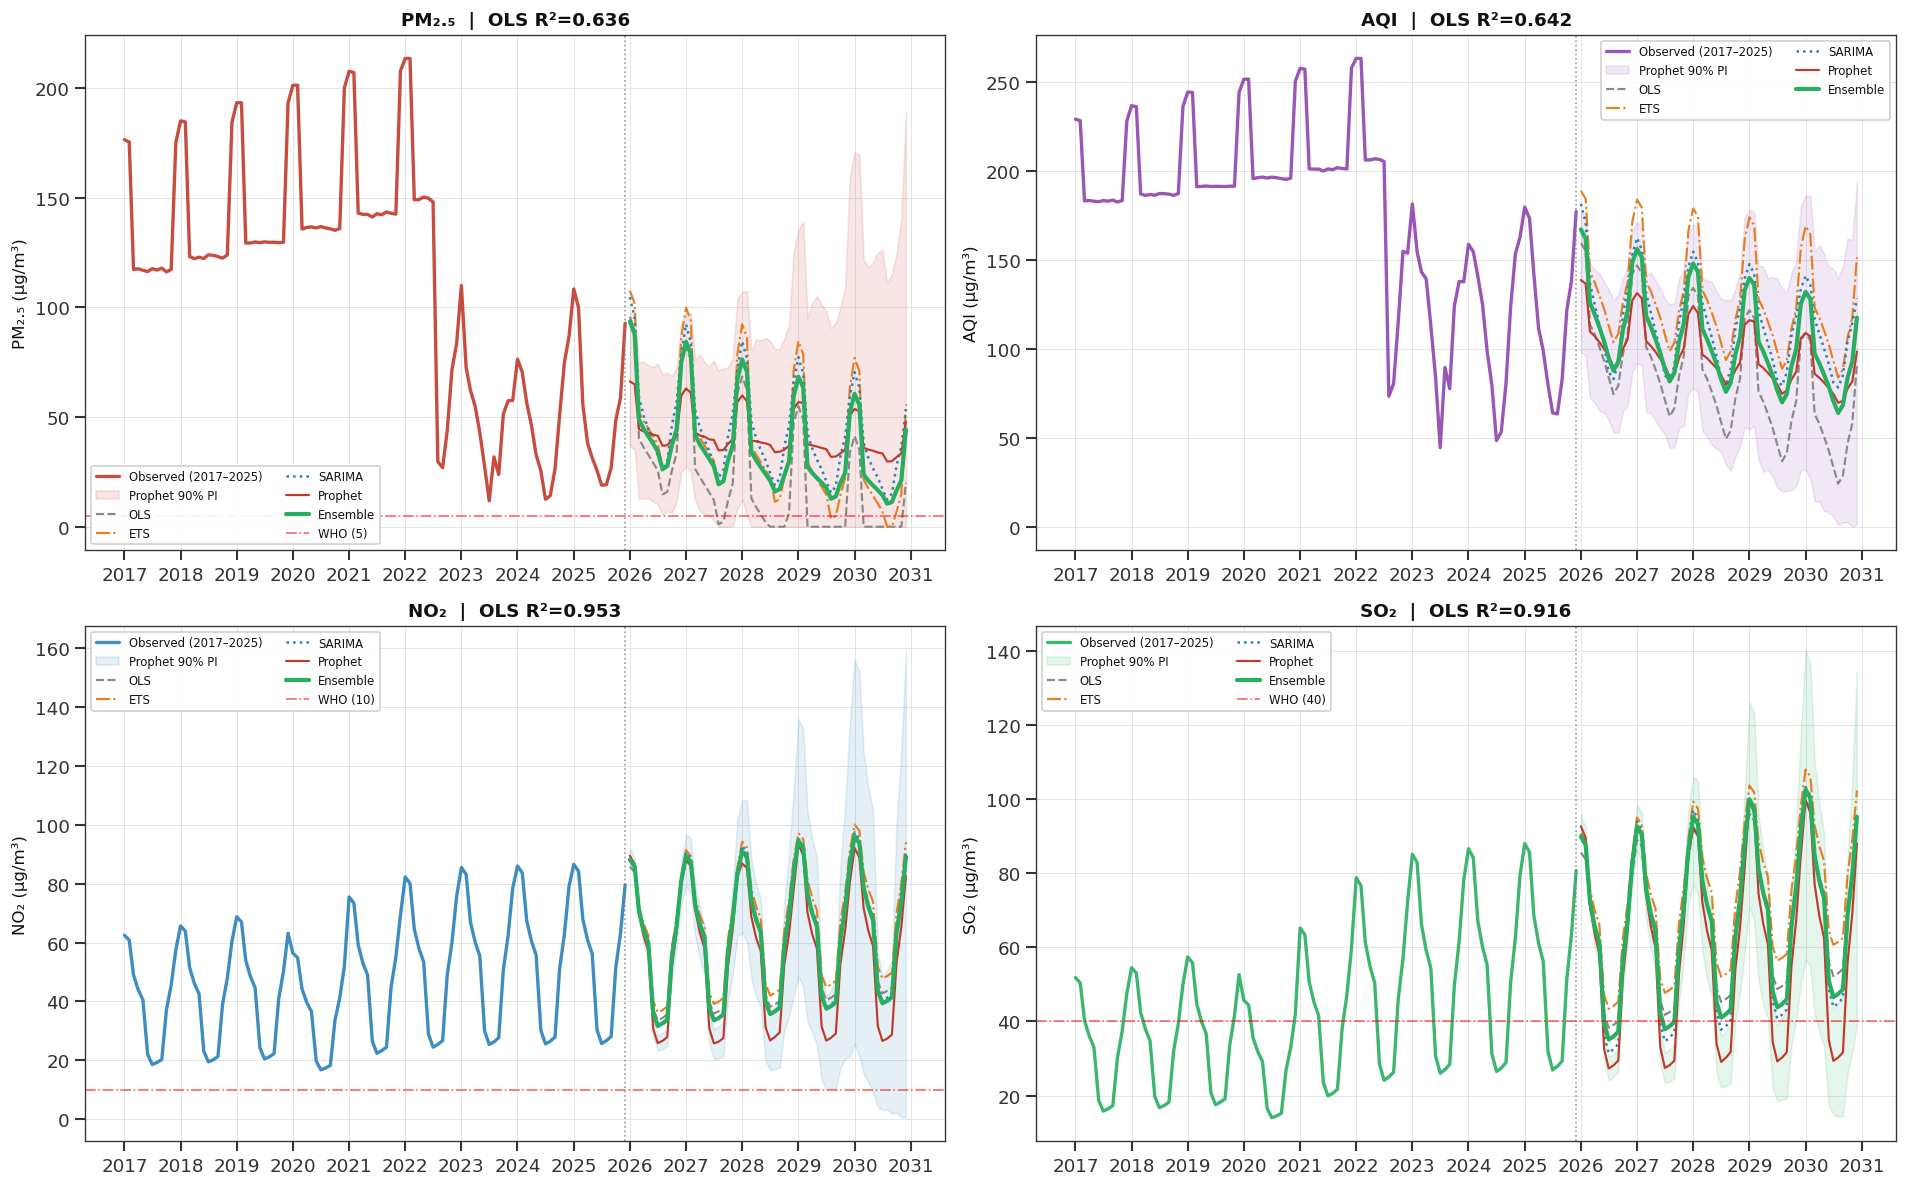

In [46]:
fig = viz.plot_forecasts_2030(df, future_df, forecasts)
save_fig(fig, 'fig30_forecasts_2030')
plt.show()


### 15.1 Ensemble forecast summary table (2026–2030)


In [47]:
summary_tbl = forecast_summary_table(future_df, forecasts)
from IPython.display import display, Latex

_pm25_key  = 'PM₂.₅ (µg/m³)'
_pm10_key  = 'PM₁₀ est.'
_no2_key   = 'NO₂ (µg/m³)'
_so2_key   = 'SO₂ (µg/m³)'
_who_x_key = '× WHO PM₂.₅'
_rows = '\n'.join(
    f'  {int(yr)}'
    + f' & {r[_pm25_key]:.1f}'
    + f' & {r[_pm10_key]:.1f}'
    + f' & {r[_no2_key]:.1f}'
    + f' & {r[_so2_key]:.1f}'
    + f' & {r["AQI"]:.1f}'
    + f' & {r[_who_x_key]:.1f}' + r' \\'
    for yr, r in summary_tbl.iterrows()
)

display(HTML(_pub_table(
    r'\textbf{Table 2.}\ Ensemble forecast --- projected annual mean concentrations'
    r' and AQI, Dhaka City (2026--2030). Business-as-usual scenario.\\[4pt]' '\n'
    r'\begin{tabular}{crrrrrr}' '\n'
    r'\hline\hline' '\n'
    r'\textbf{Year} & $\mathrm{PM}_{2.5}$ & $\mathrm{PM}_{10}^\dagger$'
    r' & $\mathrm{NO}_2$ & $\mathrm{SO}_2$ & \textbf{AQI} & $\times$\textbf{WHO} \\' '\n'
    r'& ($\mu\mathrm{g\,m}^{-3}$) & ($\mu\mathrm{g\,m}^{-3}$)'
    r' & ($\mu\mathrm{g\,m}^{-3}$) & ($\mu\mathrm{g\,m}^{-3}$) & & \\' '\n'
    r'\hline' '\n'
    + _rows + '\n'
    r'\hline\hline' '\n'
    r'\end{tabular}' '\n\n'
    r'$^\dagger\mathrm{PM}_{10}$ estimated from $\mathrm{PM}_{2.5}$ using mean'
    r' 2017--2025 ratio. WHO $\mathrm{PM}_{2.5}$ annual guideline $= 5\ \mu\mathrm{g\,m}^{-3}$.'
)))

Year,PM2.5,PM10†,NO2,SO2,AQI,×WHO
,(µg m-3),(µg m-3),(µg m-3),(µg m-3),,
2026,49.9,92.4,58.8,61.0,120.5,10.0
2027,42.5,78.6,60.7,64.0,113.1,8.5
2028,35.8,66.3,62.4,66.7,106.1,7.2
2029,30.6,56.6,64.6,70.0,99.3,6.1
2030,26.2,48.6,66.6,73.0,92.6,5.2


---
## § 17 — Conclusions & Limitations

### Key findings

1. **Persistent exceedance**: All pollutants exceeded WHO 2021 annual guidelines
   in every year of the study period. PM₂.₅ averaged >100× the WHO guideline
   during Winter months.

2. **Significant seasonal cycle**: Kruskal-Wallis tests confirm statistically
   significant seasonal differences for all pollutants (p < 0.001). Winter
   concentrations are 3–5× Monsoon levels.

3. **No significant downward trend**: Mann-Kendall tests reveal no statistically
   significant monotonic decline for PM₂.₅ or AQI over 2017–2025, indicating
   that current policies have not achieved sustained improvement.

4. **COVID-19 natural experiment**: The 2020 lockdown produced measurable but
   moderate reductions in traffic-related pollutants (NO₂, SO₂), while PM₂.₅
   and PM₁₀ showed smaller reductions due to continued biomass burning and
   dust sources that are not activity-sensitive.

5. **Combustion dominance**: PM₂.₅/PM₁₀ ratios consistently exceed 0.6,
   confirming combustion (vehicles, brick kilns, biomass) as the dominant source.

6. **Forecasts to 2030**: Under BAU assumptions, all pollutants will remain
   well above WHO and US EPA guidelines through 2030. Only the Ambitious
   Mitigation scenario approaches meaningful improvement.

### Limitations

| Limitation | Impact |
|---|---|
| Single monitoring station | May not capture spatial variability across 1,463 km² |
| Monthly temporal resolution | Masks short-term pollution episodes and diurnal variation |
| Rainfall data only 2017-2021 | Reduces statistical power of meteorological analyses |
| Socioeconomic data (national) | HDI/poverty figures are national, not Dhaka-city-specific |
| Health burden estimates | National CMR and population; order-of-magnitude only |
| Forecast uncertainty | All models assume structural stationarity; policy shocks not modelled |

---

*Generated by `main.ipynb` — Dhaka AQI Analysis Project*  
*All figures saved to `figures/` at 300 DPI.*
